# Tech Challenge – Fase 3
## Validação da Camada Gold

Este notebook tem como objetivo validar os arquivos gerados na camada Gold do pipeline de dados desenvolvido na AWS.

O pipeline foi estruturado em camadas:

**Bronze → Silver → Gold**

Os dados brutos foram armazenados no Amazon S3 na camada Bronze. Em seguida, foram processados e tratados por meio do AWS Glue com Apache Spark/PySpark, gerando as bases da camada Silver. Posteriormente, as bases tratadas foram harmonizadas e consolidadas para construção da camada Gold.

A camada Gold foi armazenada em formato **Parquet**, com compressão adequada para processamento analítico.

Nesta etapa, será realizada uma validação inicial da base consolidada, verificando:

- leitura dos arquivos Parquet;
- quantidade de arquivos gerados;
- dimensões de cada partição;
- consolidação das partições;
- quantidade total de registros e colunas;
- estrutura e tipos das variáveis;
- existência de registros duplicados;
- distribuição dos registros por período;
- disponibilidade da base para a etapa posterior de DataViz e Storytelling.

## 1. Importação das bibliotecas

Nesta etapa são carregadas as bibliotecas necessárias para leitura, manipulação e validação inicial dos arquivos da camada Gold.

In [1]:
import pandas as pd
import glob
import os

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 150)

print("Bibliotecas carregadas com sucesso.")

Bibliotecas carregadas com sucesso.


## 2. Identificação dos arquivos Parquet

O processamento realizado no Apache Spark pode gerar múltiplos arquivos físicos para representar um único conjunto lógico de dados.

Por esse motivo, a base consolidada da camada Gold é composta por diferentes arquivos Parquet. Nesta etapa, serão identificadas todas as partições disponibilizadas no ambiente do notebook.

In [2]:
arquivos = sorted(glob.glob("/content/*.parquet"))

print(f"Quantidade de arquivos Parquet encontrados: {len(arquivos)}")

for arquivo in arquivos:
    print(os.path.basename(arquivo))

Quantidade de arquivos Parquet encontrados: 4
part-00000-4b8264b0-723e-48ff-9656-73d1988e1c94-c000.snappy.parquet
part-00001-4b8264b0-723e-48ff-9656-73d1988e1c94-c000.snappy.parquet
part-00002-4b8264b0-723e-48ff-9656-73d1988e1c94-c000.snappy.parquet
part-00003-4b8264b0-723e-48ff-9656-73d1988e1c94-c000.snappy.parquet


## 3. Validação individual das partições

Antes da consolidação, cada arquivo Parquet será carregado individualmente.

Essa verificação permite confirmar que todas as partições produzidas pelo pipeline AWS estão íntegras e podem ser consumidas corretamente pelo ambiente analítico.

In [3]:
validacao_arquivos = []

for arquivo in arquivos:

    df_teste = pd.read_parquet(arquivo)

    validacao_arquivos.append({
        "arquivo": os.path.basename(arquivo),
        "linhas": df_teste.shape[0],
        "colunas": df_teste.shape[1]
    })

df_validacao = pd.DataFrame(validacao_arquivos)

display(df_validacao)

,arquivo,linhas,colunas
0,part-00000-4b8264b0-723e-48ff-9656-73d1988e1c94-c000.snappy.parquet,3535,1194
1,part-00001-4b8264b0-723e-48ff-9656-73d1988e1c94-c000.snappy.parquet,3569,1194
2,part-00002-4b8264b0-723e-48ff-9656-73d1988e1c94-c000.snappy.parquet,3469,1194
3,part-00003-4b8264b0-723e-48ff-9656-73d1988e1c94-c000.snappy.parquet,3429,1194


### Resultado da validação individual

A tabela acima apresenta a quantidade de linhas e colunas encontrada em cada partição da camada Gold.

Caso todos os arquivos sejam carregados sem erro, considera-se validada a integridade básica das partições geradas pelo processamento distribuído no AWS Glue com Apache Spark.

## 4. Consolidação das partições da camada Gold

Após a validação individual, os arquivos serão concatenados para reconstruir a base analítica consolidada.

As diferentes partições representam partes de um mesmo conjunto de dados produzido pelo Spark. Portanto, a concatenação não corresponde à criação de novas fontes, mas à reconstrução local da base Gold gerada na AWS.

In [4]:
dataframes = [
    pd.read_parquet(arquivo)
    for arquivo in arquivos
]

df_gold = pd.concat(
    dataframes,
    ignore_index=True
)

print("Base Gold consolidada com sucesso.")
print(f"Quantidade de registros: {df_gold.shape[0]:,}")
print(f"Quantidade de colunas: {df_gold.shape[1]:,}")

Base Gold consolidada com sucesso.
Quantidade de registros: 14,002
Quantidade de colunas: 1,194


## 5. Visualização inicial da base Gold

A seguir é apresentada uma amostra dos registros da base consolidada.

Essa inspeção permite verificar visualmente se as variáveis e os valores esperados foram preservados após as etapas de tratamento, harmonização e consolidação realizadas na AWS.

In [5]:
display(df_gold.head())

,0_a_token,0_d_data_hora_envio,1_a_1_faixa_idade,1_a_idade,1_b_genero,1_c_cor_raca_etnia,1_d_pcd,1_e_1_nao_acredito_que_minha_experiencia_profissional_seja_afetada,1_e_2_sim_devido_a_minha_cor_raca_etnia,1_e_3_sim_devido_a_minha_identidade_de_genero,1_e_4_sim_devido_ao_fato_de_ser_pcd,1_e_experiencia_profissional_prejudicada,1_f_1_quantidade_de_oportunidades_de_emprego_vagas_recebidas,1_f_2_senioridade_das_vagas_recebidas_em_relacao_a_sua_experiencia,1_f_3_aprovacao_em_processos_seletivos_entrevistas,1_f_4_oportunidades_de_progressao_de_carreira,1_f_5_velocidade_de_progressao_de_carreira,1_f_6_nivel_de_cobranca_no_trabalho_stress_no_trabalho,1_f_7_atencao_dada_pelas_pessoas_diante_das_minhas_opinioes_e_ideias,1_f_8_relacao_com_outras_pessoas_da_empresa_em_momentos_de_trabalho,1_f_9_relacao_com_outras_pessoas_da_empresa_em_momentos_de_integracao_e_outros_momentos_fora_do_trabalho,1_f_aspectos_prejudicados,1_g_vive_no_brasil,1_h_pais_onde_mora,1_i_1_uf_onde_mora,1_i_2_regiao_onde_mora,1_i_estado_onde_mora,1_j_vive_no_estado_de_formacao,1_k_1_uf_de_origem,1_k_2_regiao_de_origem,1_k_estado_de_origem,1_l_nivel_de_ensino,1_m_area_de_formacao,2_a_situacao_de_trabalho,2_b_setor,2_c_numero_de_funcionarios,2_d_atua_como_gestor,2_e_cargo_como_gestor,2_f_cargo_atual,2_g_nivel,2_h_faixa_salarial,2_i_tempo_de_experiencia_em_dados,2_j_tempo_de_experiencia_em_ti,2_k_satisfeito_atualmente,2_l_10_reputacao_que_a_empresa_tem_no_mercado,2_l_11_gostaria_de_trabalhar_em_outra_area,2_l_1_remuneracao_salario,2_l_2_beneficios,2_l_3_proposito_do_trabalho_e_da_empresa,2_l_4_flexibilidade_de_trabalho_remoto,2_l_5_ambiente_e_clima_de_trabalho,2_l_6_oportunidade_de_aprendizado_e_trabalhar_com_referencias,2_l_7_oportunidades_de_crescimento,2_l_8_maturidade_da_empresa_em_termos_de_tecnologia_e_dados,2_l_9_relacao_com_os_gestores_e_lideres,2_l_motivo_insatisfacao,2_m_participou_de_entrevistas_ultimos_6m,2_n_planos_de_mudar_de_emprego_6m,2_o_10_reputacao_que_a_empresa_tem_no_mercado,2_o_1_remuneracao_salario,2_o_2_beneficios,2_o_3_proposito_do_trabalho_e_da_empresa,2_o_4_flexibilidade_de_trabalho_remoto,2_o_5_ambiente_e_clima_de_trabalho,2_o_6_oportunidade_de_aprendizado_e_trabalhar_com_referencias,2_o_7_plano_de_carreira_e_oportunidades_de_crescimento,2_o_8_maturidade_da_empresa_em_termos_de_tecnologia_e_dados,2_o_9_qualidade_dos_gestores_e_lideres,2_o_criterios_para_escolha_de_emprego,2_p_empresa_passou_por_layoff_em_2025,2_q_modelo_de_trabalho_atual,2_r_modelo_de_trabalho_ideal,2_s_atitude_em_caso_de_retorno_presencial,3_a_numero_de_pessoas_em_dados,3_b_10_ml_engineer_ai_engineer,3_b_1_analytics_engineer,3_b_2_engenharia_de_dados_data_engineer,3_b_3_analista_de_dados_data_analyst,3_b_4_cientista_de_dados_data_scientist,3_b_5_database_administrator_dba,3_b_6_analista_de_business_intelligence_bi,3_b_7_arquiteto_de_dados_data_architect,3_b_8_data_product_manager_dpm,3_b_9_business_analyst,3_b_cargos_no_time_de_dados_da_empresa,3_c_10_gestao_de_produtos_de_dados,3_c_11_gestao_de_pessoas,3_c_1_pensar_na_visao_de_longo_prazo_de_dados,3_c_2_organizacao_de_treinamentos_e_iniciativas,3_c_3_atracao_selecao_e_contratacao,3_c_4_decisao_sobre_contratacao_de_ferramentas,3_c_5_gestor_da_equipe_de_engenharia_de_dados,3_c_6_gestor_da_equipe_de_estudos_relatorios,3_c_7_gestor_da_equipe_de_inteligencia_artificial_e_machine_learning,3_c_8_apesar_de_ser_gestor_ainda_atuo_na_parte_tecnica,3_c_9_gestao_de_projetos_de_dados,3_c_responsabilidades_como_gestor,3_d_10_gerenciar_a_expectativa_das_areas,3_d_11_garantir_a_manutencao_dos_projetos_e_modelos_em_producao,3_d_12_conseguir_levar_inovacao_para_a_empresa,...,p7_a_6_desenvolvo_cuido_da_manutencao_de_etl_s_utilizando_tecnologias_como_talend_pentaho_airflow_dataflow_etc,p7_a_7_atuo_na_modelagem_dos_dados_com_o_objetivo_de_criar_conjuntos_de_dados_data_warehouses_data_marts_etc,p7_a_8_desenvolvo_cuido_da_manutencao_de_planilhas_para_atender_as_areas_de_negocio,p7_a_9_utilizo_ferramentas_avancadas_de_estatistica_como_sass_pss_stata_e

## 5.1 Validação do preenchimento das variáveis

A visualização inicial apresenta valores ausentes em diversas variáveis. Esse comportamento pode estar relacionado à harmonização dos diferentes questionários utilizados nos períodos analisados, uma vez que nem todas as variáveis estão presentes em todas as edições da pesquisa.

Para verificar a integridade da consolidação, será analisada a quantidade de valores preenchidos em cada coluna da base Gold.

In [6]:
preenchimento = pd.DataFrame({
    "coluna": df_gold.columns,
    "preenchidos": df_gold.notna().sum().values,
    "nulos": df_gold.isna().sum().values
})

preenchimento["percentual_preenchido"] = (
    preenchimento["preenchidos"] / len(df_gold) * 100
)

preenchimento = preenchimento.sort_values(
    "preenchidos",
    ascending=False
)

display(preenchimento.head(30))

,coluna,preenchidos,nulos,percentual_preenchido
1191,periodo,14002,0,100.000000
1193,data_processamento_gold,14002,0,100.000000
791,data_processamento,14002,0,100.000000
1192,camada,14002,0,100.000000
792,p0_id,5293,8709,37.801743
794,p1_a_idade,5293,8709,37.801743
795,p1_b_genero,5293,8709,37.801743
796,p1_c_cor_raca_etnia,5293,8709,37.801743
797,p1_d_pcd,5293,8709,37.801743
813,p1_g_vive_no_brasil,5293,8709,37.801743


## 5.2 Validação da distribuição dos registros por período

Como a camada Gold consolida diferentes edições da pesquisa, é importante verificar a quantidade de registros provenientes de cada período.

Essa validação permite confirmar que os conjuntos de dados processados nas etapas anteriores foram preservados durante a consolidação e fornece uma visão inicial da composição temporal da base analítica.

In [7]:
distribuicao_periodos = (
    df_gold["periodo"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("periodo")
    .reset_index(name="quantidade_registros")
)

distribuicao_periodos["percentual"] = (
    distribuicao_periodos["quantidade_registros"]
    / len(df_gold)
    * 100
).round(2)

display(distribuicao_periodos)

print(
    "\nTotal:",
    distribuicao_periodos["quantidade_registros"].sum()
)

,periodo,quantidade_registros,percentual
0,2023-2024,5293,37.80
1,2024-2025,5215,37.24
2,2025-2026,3494,24.95



Total: 14002


### Resultado da validação temporal

A base Gold consolidada contém **14.002 registros**, distribuídos entre os três períodos analisados:

- **2023–2024:** 5.293 registros;
- **2024–2025:** 5.215 registros;
- **2025–2026:** 3.494 registros.

A soma dos registros por período corresponde integralmente à quantidade de observações da base Gold consolidada.

A presença dos três períodos confirma a preservação da dimensão temporal durante o processo de consolidação realizado na AWS. As diferenças observadas no preenchimento de determinadas variáveis são compatíveis com as diferenças estruturais existentes entre as edições dos questionários.

## 6. Verificação de registros duplicados

A duplicidade de registros é um aspecto importante da qualidade dos dados, pois observações repetidas podem provocar distorções em indicadores, distribuições e análises estatísticas.

Embora o tratamento realizado na camada Silver tenha contemplado a remoção de registros duplicados, nesta etapa é realizada uma nova verificação sobre a base Gold consolidada.

O objetivo é confirmar se a consolidação dos diferentes períodos não introduziu registros completamente duplicados na base analítica final.

In [8]:
quantidade_duplicados = df_gold.duplicated().sum()

percentual_duplicados = (
    quantidade_duplicados / len(df_gold) * 100
)

print("=" * 60)
print("VERIFICAÇÃO DE DUPLICIDADE")
print("=" * 60)

print(f"Total de registros: {len(df_gold):,}")
print(f"Registros completamente duplicados: {quantidade_duplicados:,}")
print(f"Percentual de duplicidade: {percentual_duplicados:.2f}%")

VERIFICAÇÃO DE DUPLICIDADE
Total de registros: 14,002
Registros completamente duplicados: 0
Percentual de duplicidade: 0.00%


### Resultado da verificação de duplicidade

A análise identificou **0 registros completamente duplicados** entre as **14.002 observações** presentes na camada Gold, correspondendo a uma taxa de duplicidade de **0,00%**.

O resultado confirma que a consolidação dos diferentes períodos não introduziu duplicidades completas na base analítica final e reforça a consistência do tratamento realizado anteriormente na camada Silver.

## 7. Análise de valores ausentes

Como a camada Gold reúne diferentes edições da pesquisa, a presença de valores ausentes deve ser interpretada considerando as diferenças estruturais existentes entre os questionários.

Nem todas as perguntas e variáveis estão presentes em todos os períodos analisados. Durante a harmonização dos dados, essas diferenças foram preservadas, resultando em valores nulos para variáveis que não possuem correspondência em determinada edição da pesquisa.

Nesta etapa, será analisado o volume e o percentual de valores ausentes por variável, permitindo avaliar o nível de preenchimento da base e apoiar a seleção das informações que serão utilizadas posteriormente nas análises e visualizações.

In [9]:
analise_nulos = pd.DataFrame({
    "coluna": df_gold.columns,
    "quantidade_nulos": df_gold.isna().sum().values,
    "quantidade_preenchidos": df_gold.notna().sum().values
})

analise_nulos["percentual_nulos"] = (
    analise_nulos["quantidade_nulos"]
    / len(df_gold)
    * 100
).round(2)

analise_nulos["percentual_preenchido"] = (
    analise_nulos["quantidade_preenchidos"]
    / len(df_gold)
    * 100
).round(2)

analise_nulos = analise_nulos.sort_values(
    "percentual_nulos",
    ascending=False
).reset_index(drop=True)

display(analise_nulos.head(30))

,coluna,quantidade_nulos,quantidade_preenchidos,percentual_nulos,percentual_preenchido
0,1_h_pais_onde_mora,13880,122,99.13,0.87
1,col_1_h_pais_onde_mora,13863,139,99.01,0.99
2,5_b_oportunidade_buscada,13819,183,98.69,1.31
3,5_d_experiencia_em_processos_seletivos,13815,187,98.66,1.34
4,5_c_tempo_em_busca_de_oportunidade,13810,192,98.63,1.37
5,col_5_b_oportunidade_buscada,13716,286,97.96,2.04
6,p5_d_como_tem_sido_a_busca_por_um_emprego_na_area_de_dados,13716,286,97.96,2.04
7,p5_b_qual_oportunidade_voce_esta_buscando,13715,287,97.95,2.05
8,p5_c_ha_quanto_tempo_voce_busca_uma_oportunidade_na_area_de_dados,13715,287,97.95,2.05
9,col_5_d_experiencia_em_processos_seletivos,13713,289,97.94,2.06


### Resultado da análise de valores ausentes

A análise identificou diferentes níveis de preenchimento entre as variáveis da camada Gold.

Esse comportamento é esperado devido a dois fatores principais: as diferenças estruturais entre as edições dos questionários e a existência de perguntas condicionais, respondidas apenas por determinados grupos de participantes.

Dessa forma, percentuais elevados de valores ausentes não serão interpretados automaticamente como problemas de qualidade dos dados.


## 8. Verificação de colunas sem preenchimento

Além da análise geral de valores ausentes, é importante identificar variáveis que não apresentam nenhum valor preenchido na base consolidada.

Essa verificação permite diferenciar colunas parcialmente preenchidas, que ainda podem ser relevantes para análises específicas, de colunas completamente vazias, que não possuem informação analítica disponível na camada Gold.

In [10]:
colunas_totalmente_nulas = [
    coluna
    for coluna in df_gold.columns
    if df_gold[coluna].isna().all()
]

print("=" * 60)
print("COLUNAS COMPLETAMENTE VAZIAS")
print("=" * 60)

print(f"Total de colunas da Gold: {len(df_gold.columns):,}")
print(
    f"Colunas 100% sem preenchimento: "
    f"{len(colunas_totalmente_nulas):,}"
)

if len(colunas_totalmente_nulas) > 0:
    print("\nExemplos de colunas completamente vazias:")

    for coluna in colunas_totalmente_nulas[:20]:
        print(f"- {coluna}")
else:
    print("\nNenhuma coluna completamente vazia foi encontrada.")

COLUNAS COMPLETAMENTE VAZIAS
Total de colunas da Gold: 1,194
Colunas 100% sem preenchimento: 0

Nenhuma coluna completamente vazia foi encontrada.


# 6. DataViz e Storytelling

Após a construção, consolidação e validação da camada Gold, inicia-se a etapa de análise visual e interpretação dos dados.

O DataViz foi estruturado a partir das **questões de negócio propostas pelo Tech Challenge**, buscando transformar os dados processados na AWS em informações capazes de apoiar a compreensão do mercado brasileiro de Dados, Analytics e Inteligência Artificial.

As análises desenvolvidas nesta etapa buscam responder às seguintes questões:

1. **Como está estruturado o mercado brasileiro de Dados?**
2. **Quais perfis profissionais são mais valorizados pelo mercado?**
3. **Qual é o cenário de diversidade de gênero nas carreiras de dados?**
4. **Quais tecnologias apresentam maior adoção entre os profissionais?**
5. **Qual é o índice de adoção de Inteligência Artificial e qual seu impacto?**
6. **Existem diferenças relevantes entre regiões, senioridades ou modelos de trabalho?**
7. **Quais oportunidades e desafios podem ser identificados para empresas que desejam investir em Dados e Inteligência Artificial?**

A partir dessas questões, serão analisadas as variáveis disponíveis nas diferentes edições da pesquisa, considerando as particularidades de cada período e priorizando indicadores comparáveis sempre que possível.

As visualizações serão acompanhadas de interpretações e insights, permitindo não apenas descrever os dados, mas também identificar tendências, diferenças entre grupos e possíveis implicações estratégicas para o mercado.

## 6.1 Mapeamento das variáveis analíticas

Como a camada Gold consolida diferentes edições da pesquisa, os questionários apresentam diferenças em seus esquemas e nomenclaturas.

Antes da construção das visualizações, será realizado o mapeamento das variáveis relacionadas às questões de negócio do Tech Challenge. Essa etapa permite identificar quais indicadores estão disponíveis em cada período e evita comparações inadequadas entre perguntas que possuem significados distintos.

O primeiro eixo analisado será a **estrutura do mercado brasileiro de Dados**, considerando aspectos como atuação profissional, cargo, senioridade e características das empresas.

In [11]:
def mapear_variaveis(termos):
    termos = [termo.lower() for termo in termos]

    colunas = [
        coluna for coluna in df_gold.columns
        if any(termo in coluna.lower() for termo in termos)
    ]

    registros = []

    for coluna in colunas:
        mascara = df_gold[coluna].notna()

        periodos = sorted(
            df_gold.loc[mascara, "periodo"]
            .dropna()
            .astype(str)
            .unique()
        )

        registros.append({
            "coluna": coluna,
            "preenchidos": int(mascara.sum()),
            "percentual_preenchido": round(mascara.mean() * 100, 2),
            "periodos_com_dados": ", ".join(periodos)
        })

    resultado = pd.DataFrame(registros)

    if not resultado.empty:
        resultado = resultado.sort_values(
            "preenchidos",
            ascending=False
        ).reset_index(drop=True)

    return resultado


mapa_mercado = mapear_variaveis([
    "cargo",
    "profissao",
    "profissão",
    "senior",
    "nivel",
    "nível",
    "area",
    "área",
    "atuacao",
    "atuação",
    "empresa"
])

display(mapa_mercado.head(50))

,coluna,preenchidos,percentual_preenchido,periodos_com_dados
0,p1_l_nivel_de_ensino,5293,37.80,2023-2024
1,p4_a_1_atuacao,5293,37.80,2023-2024
2,col_1_l_nivel_de_ensino,5215,37.24,2024-2025
3,col_4_a_1_atuacao_em_dados,5215,37.24,2024-2025
4,p1_m_area_de_formacao,5180,36.99,2023-2024
5,col_1_m_area_de_formacao,5121,36.57,2024-2025
6,col_2_o_3_proposito_do_trabalho_e_da_empresa,4861,34.72,2024-2025
7,col_2_o_8_maturidade_da_empresa_em_termos_de_tecnologia_e_dados,4861,34.72,2024-2025
8,col_2_o_10_reputacao_que_a_empresa_tem_no_mercado,4861,34.72,2024-2025
9,col_2_q_empresa_passou_por_layoff_em_2024,4861,34.72,2024-2025


## 6.2 Estrutura do mercado brasileiro de Dados

A primeira questão de negócio busca compreender como está estruturado o mercado brasileiro de Dados.

Inicialmente, serão analisados os cargos e níveis de senioridade declarados pelos profissionais. Como os questionários apresentam diferenças entre suas edições, as categorias são verificadas antes da construção das visualizações, garantindo que apenas variáveis conceitualmente comparáveis sejam utilizadas.

In [12]:
colunas_estrutura = [
    "p2_f_cargo_atual",
    "col_2_f_cargo_atual",
    "p2_g_nivel",
    "col_2_g_nivel"
]

for coluna in colunas_estrutura:
    print("\n" + "=" * 80)
    print(coluna)
    print("=" * 80)

    print(
        df_gold[coluna]
        .value_counts(dropna=False)
        .head(20)
    )


p2_f_cargo_atual
p2_f_cargo_atual
None                                                                   10145
Analista de Dados/Data Analyst                                           907
Cientista de Dados/Data Scientist                                        687
Engenheiro de Dados/Arquiteto de Dados/Data Engineer/Data Architect      684
Analista de BI/BI Analyst                                                506
Outra Opção                                                              262
Analista de Negócios/Business Analyst                                    195
Analytics Engineer                                                       139
Desenvolvedor/ Engenheiro de Software/ Analista de Sistemas              105
Data Product Manager/ Product Manager (PM/APM/DPM/GPM/PO)                 81
Engenheiro de Machine Learning/ML Engineer/AI Engineer                    75
Analista de Suporte/Analista Técnico                                      72
Analista de Inteligência de Mercado/Marke

### 6.2.1 Distribuição dos profissionais por senioridade

A senioridade permite compreender a composição do mercado entre diferentes níveis de experiência profissional.

Para possibilitar a comparação entre as diferentes edições da pesquisa, foram utilizadas proporções dentro de cada período, evitando que diferenças no número total de respondentes influenciem a interpretação.

As três edições analisadas apresentam categorias comparáveis de senioridade. No período de 2025-2026, além das categorias Júnior, Pleno e Sênior, também é apresentada a categoria **Especialista/Staff+**, que foi mantida separadamente por representar um nível profissional distinto.

A visualização a seguir compara a participação percentual de cada nível de senioridade entre os períodos de 2023-2024, 2024-2025 e 2025-2026.

,2023-2024,2024-2025,2025-2026
Júnior,27.12,22.75,20.72
Pleno,36.09,36.06,31.00
Sênior,36.79,41.19,34.32
Especialista/Staff+,0.00,0.00,13.96


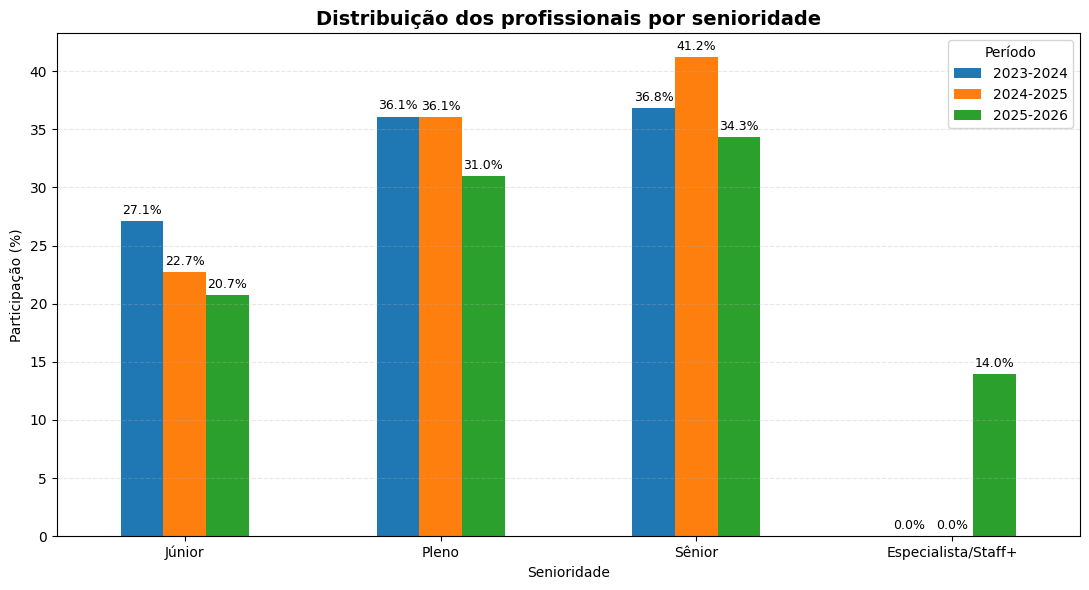

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Distribuição percentual por período
senioridade_2023 = (
    df_gold["p2_g_nivel"]
    .dropna()
    .value_counts(normalize=True)
    .mul(100)
)

senioridade_2024 = (
    df_gold["col_2_g_nivel"]
    .dropna()
    .value_counts(normalize=True)
    .mul(100)
)

senioridade_2025 = (
    df_gold.loc[
        df_gold["periodo"] == "2025-2026",
        "2_g_nivel"
    ]
    .dropna()
    .value_counts(normalize=True)
    .mul(100)
)

# Consolidação
df_senioridade = pd.concat(
    [senioridade_2023, senioridade_2024, senioridade_2025],
    axis=1
).fillna(0)

df_senioridade.columns = [
    "2023-2024",
    "2024-2025",
    "2025-2026"
]

# Ordem analítica das categorias
ordem = [
    "Júnior",
    "Pleno",
    "Sênior",
    "Especialista/Staff+"
]

df_senioridade = df_senioridade.reindex(ordem)

display(df_senioridade.round(2))

# Visualização
ax = df_senioridade.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title(
    "Distribuição dos profissionais por senioridade",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Senioridade")
plt.ylabel("Participação (%)")
plt.xticks(rotation=0)
plt.legend(title="Período")
plt.grid(axis="y", linestyle="--", alpha=0.3)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=9
    )

plt.tight_layout()
plt.show()

#### Interpretação

A comparação entre os três períodos evidencia mudanças na composição dos profissionais por nível de senioridade.

A participação de profissionais **Júnior apresentou queda contínua**, passando de **27,1% em 2023-2024 para 22,7% em 2024-2025 e 20,7% em 2025-2026**. O resultado representa uma redução de aproximadamente **6,4 pontos percentuais** entre o primeiro e o último período analisado.

Entre os profissionais **Pleno**, a participação permaneceu praticamente estável entre 2023-2024 e 2024-2025, em aproximadamente **36%**, mas recuou para **31,0% em 2025-2026**.

A categoria **Sênior** representava 36,8% dos profissionais em 2023-2024, alcançou **41,2% em 2024-2025** e passou para **34,3% em 2025-2026**. Entretanto, a edição mais recente passou a apresentar separadamente a categoria **Especialista/Staff+**, responsável por **14,0%** dos respondentes com nível profissional informado.

Dessa forma, a redução da participação da categoria Sênior em 2025-2026 deve ser interpretada com cautela, uma vez que parte dos profissionais mais experientes pode estar representada na nova categoria Especialista/Staff+.

De forma geral, os dados mostram uma **redução progressiva da participação de profissionais Júnior** e uma presença relevante de profissionais em níveis mais avançados de carreira entre os respondentes. O resultado sugere uma composição da amostra cada vez mais concentrada em profissionais experientes, embora mudanças nas categorias do questionário também devam ser consideradas na comparação temporal.

> **Nota metodológica:** a categoria Especialista/Staff+ está disponível apenas na edição 2025-2026 e foi mantida separadamente, evitando sua agregação artificial à categoria Sênior.

### 6.2.2 Distribuição dos profissionais por cargo

Além da senioridade, a distribuição por cargo permite compreender quais funções concentram maior participação entre os profissionais do mercado de Dados.

Para garantir comparabilidade entre as três edições da pesquisa, são utilizadas as variáveis equivalentes de cargo atual e calculada a participação percentual de cada função dentro de seu respectivo período.

Como os questionários apresentam diversas categorias profissionais, a visualização concentra-se nos cargos com maior representatividade, permitindo identificar a composição e possíveis mudanças na estrutura profissional ao longo dos períodos analisados.

,2023-2024,2024-2025,2025-2026
Engenheiro de Dados/Arquiteto de Dados/Data Engineer/Data Architect,17.73,0.00,0.00
Analytics Engineer,3.60,5.97,5.40
Analista de Negócios/Business Analyst,5.06,4.82,5.64
Outra Opção,6.79,6.66,8.24
Analista de BI/BI Analyst,13.12,10.38,8.60
Engenheiro de Dados/Data Engineer/Data Architect,0.00,16.04,16.08
Cientista de Dados/Data Scientist,17.81,18.00,16.92
Analista de Dados/Data Analyst,23.52,25.08,23.96


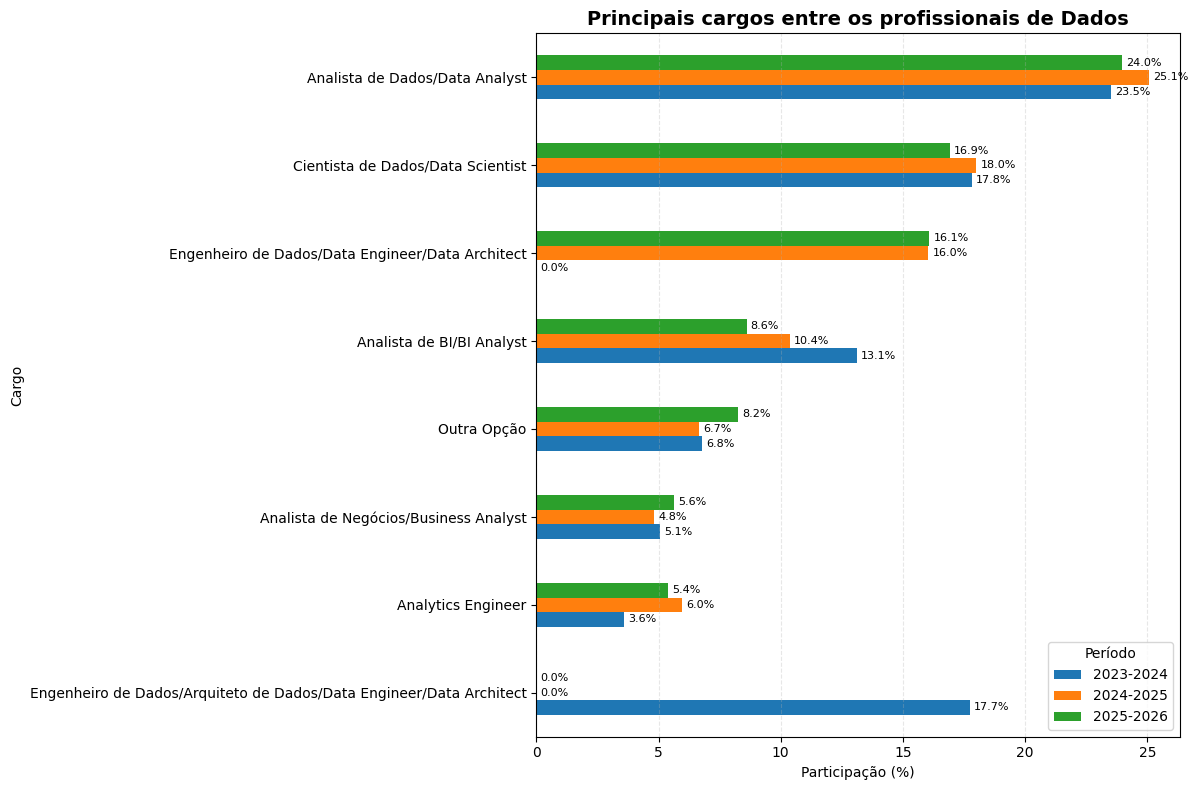

In [17]:
# Distribuição percentual de cargos por período

cargos_2023 = (
    df_gold["p2_f_cargo_atual"]
    .dropna()
    .value_counts(normalize=True)
    .mul(100)
)

cargos_2024 = (
    df_gold["col_2_f_cargo_atual"]
    .dropna()
    .value_counts(normalize=True)
    .mul(100)
)

cargos_2025 = (
    df_gold.loc[
        df_gold["periodo"] == "2025-2026",
        "2_f_cargo_atual"
    ]
    .dropna()
    .value_counts(normalize=True)
    .mul(100)
)

# Consolidação dos três períodos
df_cargos = pd.concat(
    [cargos_2023, cargos_2024, cargos_2025],
    axis=1
).fillna(0)

df_cargos.columns = [
    "2023-2024",
    "2024-2025",
    "2025-2026"
]

# Seleciona os cargos mais representativos considerando os três períodos
df_cargos["media"] = df_cargos.mean(axis=1)

top_cargos = (
    df_cargos
    .sort_values("media", ascending=False)
    .head(8)
    .drop(columns="media")
)

# Ordenação para o gráfico
top_cargos = top_cargos.sort_values(
    "2025-2026",
    ascending=True
)

display(top_cargos.round(2))

# Visualização
ax = top_cargos.plot(
    kind="barh",
    figsize=(12, 8)
)

plt.title(
    "Principais cargos entre os profissionais de Dados",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Participação (%)")
plt.ylabel("Cargo")
plt.legend(title="Período")
plt.grid(axis="x", linestyle="--", alpha=0.3)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=8
    )

plt.tight_layout()
plt.show()

#### Ajuste de comparabilidade entre os períodos

A visualização inicial revelou uma descontinuidade aparente na categoria relacionada à Engenharia de Dados. Ao analisar as categorias originais dos questionários, verificou-se que essa diferença estava associada principalmente a uma alteração de nomenclatura entre as edições.

Para evitar que uma mudança textual fosse interpretada como uma mudança real na participação desses profissionais, as categorias equivalentes foram harmonizadas antes da construção da visualização comparativa final.

A análise inicial foi mantida como evidência do processo de validação e refinamento dos dados durante a etapa analítica.

,2023-2024,2024-2025,2025-2026
Desenvolvedor/ Engenheiro de Software/ Analista de Sistemas,2.72,3.20,4.24
Analytics Engineer,3.60,5.97,5.40
Analista de Negócios/Business Analyst,5.06,4.82,5.64
Outra Opção,6.79,6.66,8.24
Analista de BI/BI Analyst,13.12,10.38,8.60
Engenheiro de Dados/Data Engineer/Data Architect,17.73,16.04,16.08
Cientista de Dados/Data Scientist,17.81,18.00,16.92
Analista de Dados/Data Analyst,23.52,25.08,23.96


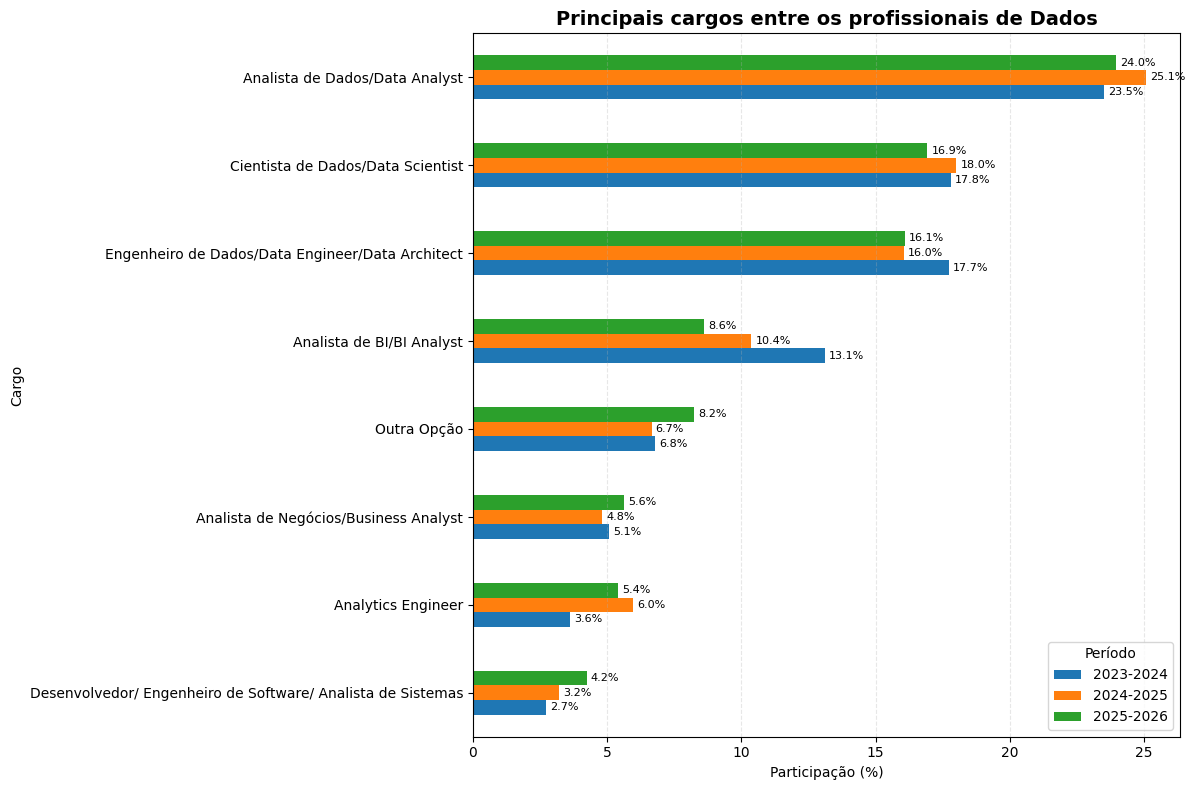

In [18]:
# Cópias das variáveis de cargo
cargo_2023 = df_gold["p2_f_cargo_atual"].copy()
cargo_2024 = df_gold["col_2_f_cargo_atual"].copy()

cargo_2025 = df_gold.loc[
    df_gold["periodo"] == "2025-2026",
    "2_f_cargo_atual"
].copy()

# Harmonização de nomenclaturas equivalentes
mapa_cargos = {
    "Engenheiro de Dados/Arquiteto de Dados/Data Engineer/Data Architect":
        "Engenheiro de Dados/Data Engineer/Data Architect"
}

cargo_2023 = cargo_2023.replace(mapa_cargos)
cargo_2024 = cargo_2024.replace(mapa_cargos)
cargo_2025 = cargo_2025.replace(mapa_cargos)

# Distribuições percentuais
cargos_2023 = cargo_2023.dropna().value_counts(normalize=True).mul(100)
cargos_2024 = cargo_2024.dropna().value_counts(normalize=True).mul(100)
cargos_2025 = cargo_2025.dropna().value_counts(normalize=True).mul(100)

# Consolidação
df_cargos = pd.concat(
    [cargos_2023, cargos_2024, cargos_2025],
    axis=1
).fillna(0)

df_cargos.columns = [
    "2023-2024",
    "2024-2025",
    "2025-2026"
]

# Seleção dos 8 cargos mais representativos
df_cargos["media"] = df_cargos.mean(axis=1)

top_cargos = (
    df_cargos
    .sort_values("media", ascending=False)
    .head(8)
    .drop(columns="media")
)

# Ordenação visual pela edição mais recente
top_cargos = top_cargos.sort_values(
    "2025-2026",
    ascending=True
)

display(top_cargos.round(2))

# Gráfico
ax = top_cargos.plot(
    kind="barh",
    figsize=(12, 8)
)

plt.title(
    "Principais cargos entre os profissionais de Dados",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Participação (%)")
plt.ylabel("Cargo")
plt.legend(title="Período")
plt.grid(axis="x", linestyle="--", alpha=0.3)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=8
    )

plt.tight_layout()
plt.show()

Para permitir a comparação temporal, categorias com diferenças apenas de nomenclatura entre as edições foram harmonizadas, preservando o significado original das funções profissionais.

#### Interpretação

A distribuição dos cargos apresenta relativa estabilidade entre os três períodos, com **Analista de Dados, Cientista de Dados e Engenheiro de Dados** concentrando as maiores participações entre os profissionais analisados.

O cargo de **Analista de Dados** permanece como o mais representativo em todas as edições, passando de **23,5% em 2023-2024 para 25,1% em 2024-2025 e 24,0% em 2025-2026**.

Os **Cientistas de Dados** também apresentam participação relativamente estável, variando entre **16,9% e 18,0%**, enquanto os profissionais de **Engenharia de Dados** representam aproximadamente **16% a 18%** dos respondentes nos três períodos.

Em contrapartida, observa-se redução na participação de **Analistas de BI**, de **13,1% em 2023-2024 para 10,4% em 2024-2025 e 8,6% em 2025-2026**. Já a categoria **Analytics Engineer** apresenta crescimento, passando de **3,6% para 6,0% e 5,4%**, respectivamente.

Os resultados indicam que o mercado analisado mantém forte concentração nas funções centrais de **análise, ciência e engenharia de dados**, enquanto algumas funções apresentam mudanças de representatividade ao longo das edições. Essas variações devem ser interpretadas como mudanças na composição dos respondentes, sem pressupor isoladamente crescimento ou retração do mercado de trabalho.

## 6.3 Perfis profissionais mais valorizados pelo mercado

A segunda questão de negócio do Tech Challenge busca identificar quais perfis profissionais apresentam maior valorização no mercado brasileiro de Dados.

Nesta análise, a **remuneração** será utilizada como um dos principais indicadores de valorização profissional, sendo relacionada a características como cargo e senioridade.

Como as pesquisas possuem diferentes edições e estruturas de questionário, inicialmente serão identificadas e validadas as variáveis relacionadas à remuneração nos três períodos. Essa etapa é necessária para garantir que as comparações sejam realizadas apenas entre informações conceitualmente equivalentes.

In [19]:
termos_remuneracao = [
    "salario",
    "salário",
    "remuneracao",
    "remuneração",
    "renda",
    "faixa_salarial",
    "faixa salarial"
]

candidatas_remuneracao = []

for coluna in df_gold.columns:

    possui_termo = any(
        termo.lower() in coluna.lower()
        for termo in termos_remuneracao
    )

    if possui_termo:

        periodos = (
            df_gold.loc[
                df_gold[coluna].notna(),
                "periodo"
            ]
            .dropna()
            .astype(str)
            .unique()
        )

        candidatas_remuneracao.append({
            "coluna": coluna,
            "preenchidos": int(df_gold[coluna].notna().sum()),
            "periodos_com_dados": ", ".join(sorted(periodos))
        })

df_remuneracao = pd.DataFrame(candidatas_remuneracao)

if not df_remuneracao.empty:
    df_remuneracao = df_remuneracao.sort_values(
        "preenchidos",
        ascending=False
    )

display(df_remuneracao)

,coluna,preenchidos,periodos_com_dados
3,col_2_h_faixa_salarial,4861,2024-2025
5,col_2_o_1_remuneracao_salario,4861,2024-2025
6,p2_h_faixa_salarial,4753,2023-2024
8,p2_o_1_remuneracao_salario,4727,2023-2024
0,2_h_faixa_salarial,3227,2025-2026
2,2_o_1_remuneracao_salario,3227,2025-2026
4,col_2_l_1_remuneracao_salario,1527,2024-2025
7,p2_l_2_salario_atual_nao_corresponde_ao_mercado,1318,2023-2024
1,2_l_1_remuneracao_salario,1001,2025-2026


In [20]:
variaveis_salario = {
    "2023-2024": "p2_h_faixa_salarial",
    "2024-2025": "col_2_h_faixa_salarial",
    "2025-2026": "2_h_faixa_salarial"
}

for periodo, coluna in variaveis_salario.items():

    print("\n" + "=" * 80)
    print(f"FAIXA SALARIAL — {periodo}")
    print("=" * 80)

    resultado = (
        df_gold.loc[
            df_gold["periodo"] == periodo,
            coluna
        ]
        .dropna()
        .value_counts()
    )

    display(resultado)


FAIXA SALARIAL — 2023-2024


,count
p2_h_faixa_salarial,
de R$ 8.001/mês a R$ 12.000/mês,1026
de R$ 4.001/mês a R$ 6.000/mês,745
de R$ 12.001/mês a R$ 16.000/mês,650
de R$ 6.001/mês a R$ 8.000/mês,637
de R$ 3.001/mês a R$ 4.000/mês,352
de R$ 16.001/mês a R$ 20.000/mês,328
de R$ 2.001/mês a R$ 3.000/mês,288
de R$ 1.001/mês a R$ 2.000/mês,215
de R$ 20.001/mês a R$ 25.000/mês,195



FAIXA SALARIAL — 2024-2025


,count
col_2_h_faixa_salarial,
de R$ 8.001/mês a R$ 12.000/mês,1080
de R$ 12.001/mês a R$ 16.000/mês,716
de R$ 6.001/mês a R$ 8.000/mês,656
de R$ 4.001/mês a R$ 6.000/mês,592
de R$ 16.001/mês a R$ 20.000/mês,456
de R$ 3.001/mês a R$ 4.000/mês,270
de R$ 20.001/mês a R$ 25.000/mês,246
de R$ 2.001/mês a R$ 3.000/mês,237
de R$ 25.001/mês a R$ 30.000/mês,159



FAIXA SALARIAL — 2025-2026


,count
2_h_faixa_salarial,
de R$ 8.001/mês a R$ 12.000/mês,707
de R$ 12.001/mês a R$ 16.000/mês,484
de R$ 6.001/mês a R$ 8.000/mês,367
de R$ 4.001/mês a R$ 6.000/mês,344
de R$ 16.001/mês a R$ 20.000/mês,323
de R$ 20.001/mês a R$ 25.000/mês,213
de R$ 3.001/mês a R$ 4.000/mês,157
de R$ 25.001/mês a R$ 30.000/mês,134
de R$ 2.001/mês a R$ 3.000/mês,130


### 6.3.1 Remuneração por senioridade

Para avaliar a valorização dos diferentes níveis profissionais, a faixa salarial é analisada em conjunto com a senioridade dos respondentes.

Como a remuneração é apresentada originalmente em intervalos, as faixas salariais são organizadas de forma ordinal, preservando sua estrutura original e permitindo comparar a distribuição remuneratória entre profissionais Júnior, Pleno, Sênior e, quando disponível, Especialista/Staff+.

A análise considera os três períodos da pesquisa, respeitando as diferenças existentes entre as categorias de senioridade de cada edição.

In [21]:
def agrupar_faixa_salarial(valor):

    if pd.isna(valor):
        return None

    valor = str(valor)

    if (
        "Menos de R$ 1.000" in valor or
        "R$ 1.001/mês a R$ 2.000" in valor or
        "R$ 2.001/mês a R$ 3.000" in valor or
        "R$ 3.001/mês a R$ 4.000" in valor
    ):
        return "Até R$ 4 mil"

    elif (
        "R$ 4.001/mês a R$ 6.000" in valor or
        "R$ 6.001/mês a R$ 8.000" in valor
    ):
        return "R$ 4 mil a R$ 8 mil"

    elif "R$ 8.001/mês a R$ 12.000" in valor:
        return "R$ 8 mil a R$ 12 mil"

    elif (
        "R$ 12.001/mês a R$ 16.000" in valor or
        "R$ 16.001/mês a R$ 20.000" in valor
    ):
        return "R$ 12 mil a R$ 20 mil"

    elif (
        "R$ 20.001/mês a R$ 25.000" in valor or
        "R$ 25.001/mês a R$ 30.000" in valor or
        "R$ 30.001/mês a R$ 40.000" in valor or
        "Acima de R$ 40.001" in valor
    ):
        return "Acima de R$ 20 mil"

    return None


bases_salario = []

configuracao = {
    "2023-2024": ("p2_g_nivel", "p2_h_faixa_salarial"),
    "2024-2025": ("col_2_g_nivel", "col_2_h_faixa_salarial"),
    "2025-2026": ("2_g_nivel", "2_h_faixa_salarial")
}

for periodo, (col_nivel, col_salario) in configuracao.items():

    temp = df_gold.loc[
        df_gold["periodo"] == periodo,
        [col_nivel, col_salario]
    ].copy()

    temp.columns = ["senioridade", "faixa_original"]
    temp["faixa_salarial"] = temp["faixa_original"].apply(
        agrupar_faixa_salarial
    )
    temp["periodo"] = periodo

    bases_salario.append(temp)

df_salario_senioridade = pd.concat(
    bases_salario,
    ignore_index=True
)

df_salario_senioridade = df_salario_senioridade.dropna(
    subset=["senioridade", "faixa_salarial"]
)

display(df_salario_senioridade.head())

,senioridade,faixa_original,faixa_salarial,periodo
0,Pleno,de R$ 6.001/mês a R$ 8.000/mês,R$ 4 mil a R$ 8 mil,2023-2024
1,Júnior,de R$ 1.001/mês a R$ 2.000/mês,Até R$ 4 mil,2023-2024
2,Sênior,de R$ 12.001/mês a R$ 16.000/mês,R$ 12 mil a R$ 20 mil,2023-2024
3,Sênior,de R$ 8.001/mês a R$ 12.000/mês,R$ 8 mil a R$ 12 mil,2023-2024
4,Pleno,de R$ 6.001/mês a R$ 8.000/mês,R$ 4 mil a R$ 8 mil,2023-2024


In [25]:
ordem_faixas = [
    "Até R$ 4 mil",
    "R$ 4 mil a R$ 8 mil",
    "R$ 8 mil a R$ 12 mil",
    "R$ 12 mil a R$ 20 mil",
    "Acima de R$ 20 mil"
]

tabela_salario_senioridade = (
    df_salario_senioridade
    .groupby(
        ["periodo", "senioridade", "faixa_salarial"],
        observed=True
    )
    .size()
    .reset_index(name="quantidade")
)

# Percentual calculado dentro de cada período + senioridade
tabela_salario_senioridade["percentual"] = (
    tabela_salario_senioridade
    .groupby(["periodo", "senioridade"])["quantidade"]
    .transform(lambda x: x / x.sum() * 100)
)

tabela_salario_senioridade["faixa_salarial"] = pd.Categorical(
    tabela_salario_senioridade["faixa_salarial"],
    categories=ordem_faixas,
    ordered=True
)

tabela_salario_senioridade = (
    tabela_salario_senioridade
    .sort_values(
        ["periodo", "senioridade", "faixa_salarial"]
    )
    .reset_index(drop=True)
)

display(
    tabela_salario_senioridade.round(2)
)

,periodo,senioridade,faixa_salarial,quantidade,percentual
0,2023-2024,Júnior,Até R$ 4 mil,621,59.43
1,2023-2024,Júnior,R$ 4 mil a R$ 8 mil,373,35.69
2,2023-2024,Júnior,R$ 8 mil a R$ 12 mil,43,4.11
3,2023-2024,Júnior,R$ 12 mil a R$ 20 mil,8,0.77
4,2023-2024,Pleno,Até R$ 4 mil,197,14.15
5,2023-2024,Pleno,R$ 4 mil a R$ 8 mil,725,52.08
6,2023-2024,Pleno,R$ 8 mil a R$ 12 mil,351,25.22
7,2023-2024,Pleno,R$ 12 mil a R$ 20 mil,100,7.18
8,2023-2024,Pleno,Acima de R$ 20 mil,19,1.36
9,2023-2024,Sênior,Até R$ 4 mil,23,1.62


### 6.3.2 Concentração nas faixas superiores de remuneração

Para tornar mais clara a relação entre senioridade e valorização profissional, é analisada a proporção de profissionais com remuneração **superior a R$ 12 mil mensais**.

Esse indicador permite comparar os diferentes níveis profissionais utilizando o mesmo critério de remuneração nos três períodos, reduzindo o efeito das diferenças no número de respondentes entre as edições.

periodo,2023-2024,2024-2025,2025-2026
senioridade,,,
Júnior,0.77,1.38,1.54
Pleno,8.55,9.30,11.10
Sênior,49.61,56.74,52.10
Especialista/Staff+,0.00,0.00,83.67


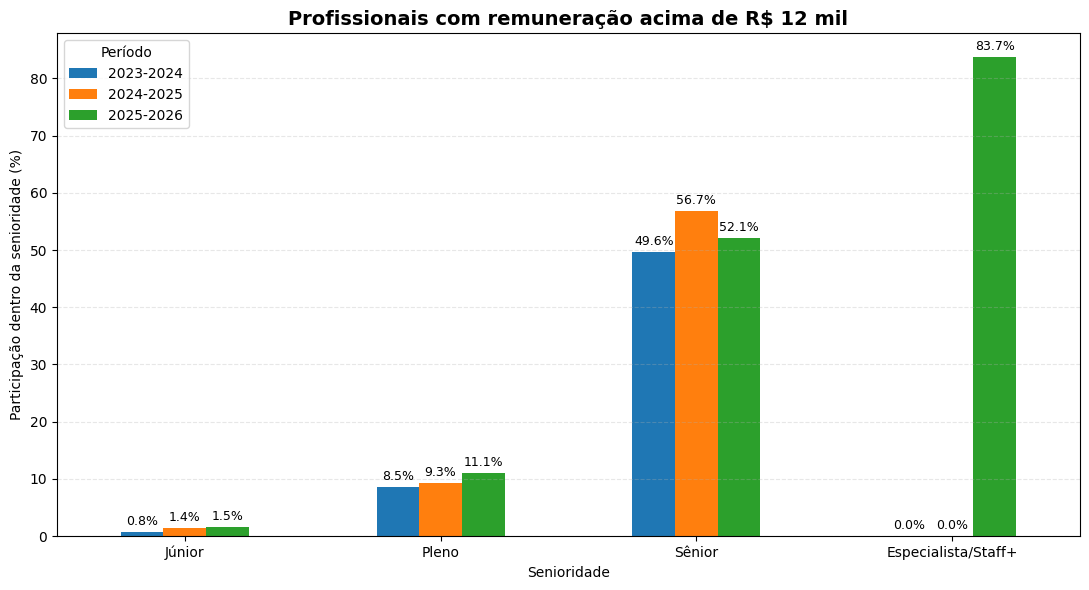

In [26]:
faixas_altas = [
    "R$ 12 mil a R$ 20 mil",
    "Acima de R$ 20 mil"
]

salarios_altos = (
    tabela_salario_senioridade[
        tabela_salario_senioridade["faixa_salarial"].isin(faixas_altas)
    ]
    .groupby(
        ["periodo", "senioridade"],
        observed=True
    )["percentual"]
    .sum()
    .reset_index()
)

pivot_salarios_altos = (
    salarios_altos
    .pivot(
        index="senioridade",
        columns="periodo",
        values="percentual"
    )
    .fillna(0)
)

ordem_senioridade = [
    "Júnior",
    "Pleno",
    "Sênior",
    "Especialista/Staff+"
]

pivot_salarios_altos = pivot_salarios_altos.reindex(
    ordem_senioridade
)

display(pivot_salarios_altos.round(2))

ax = pivot_salarios_altos.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title(
    "Profissionais com remuneração acima de R$ 12 mil",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Senioridade")
plt.ylabel("Participação dentro da senioridade (%)")
plt.xticks(rotation=0)
plt.legend(title="Período")
plt.grid(axis="y", linestyle="--", alpha=0.3)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=9
    )

plt.tight_layout()
plt.show()

#### Interpretação

A análise evidencia uma forte associação entre **senioridade profissional e presença nas faixas superiores de remuneração**.

Entre os profissionais **Júnior**, apenas **0,8% em 2023-2024, 1,4% em 2024-2025 e 1,5% em 2025-2026** apresentam remuneração superior a R$ 12 mil mensais.

Entre os profissionais **Pleno**, essa participação é maior e apresenta crescimento ao longo dos períodos analisados, passando de **8,5% para 9,3% e 11,1%**, respectivamente.

A diferença torna-se mais expressiva entre os profissionais **Sênior**: aproximadamente **49,6% em 2023-2024, 56,7% em 2024-2025 e 52,1% em 2025-2026** encontram-se nas faixas superiores a R$ 12 mil.

Na edição de 2025-2026, a categoria **Especialista/Staff+** apresenta a maior concentração nas faixas superiores de remuneração, atingindo **83,7%** dos profissionais dessa categoria.

Os resultados demonstram que os níveis mais avançados de carreira apresentam maior concentração nas faixas salariais superiores, indicando que a **senioridade está fortemente associada à valorização remuneratória** no mercado analisado.

> **Nota metodológica:** a categoria Especialista/Staff+ está disponível apenas em 2025-2026. Os resultados representam associações observadas entre senioridade e remuneração e não devem ser interpretados isoladamente como relação causal.

### 6.3.3 Valorização remuneratória por cargo

Além da senioridade, a valorização profissional pode variar de acordo com a função exercida.

Para identificar quais perfis funcionais apresentam maior presença nas faixas superiores de remuneração, será analisada a proporção de profissionais com rendimento mensal superior a **R$ 12 mil**, considerando os principais cargos presentes nas três edições da pesquisa.

As nomenclaturas equivalentes entre os diferentes questionários são harmonizadas para garantir comparabilidade temporal.

In [27]:
bases_cargo_salario = []

config_cargo_salario = {
    "2023-2024": (
        "p2_f_cargo_atual",
        "p2_h_faixa_salarial"
    ),
    "2024-2025": (
        "col_2_f_cargo_atual",
        "col_2_h_faixa_salarial"
    ),
    "2025-2026": (
        "2_f_cargo_atual",
        "2_h_faixa_salarial"
    )
}

mapa_cargos = {
    "Engenheiro de Dados/Arquiteto de Dados/Data Engineer/Data Architect":
        "Engenheiro de Dados/Data Engineer/Data Architect"
}

for periodo, (col_cargo, col_salario) in config_cargo_salario.items():

    temp = df_gold.loc[
        df_gold["periodo"] == periodo,
        [col_cargo, col_salario]
    ].copy()

    temp.columns = [
        "cargo",
        "faixa_original"
    ]

    # Harmonização dos cargos
    temp["cargo"] = temp["cargo"].replace(mapa_cargos)

    # Utiliza a mesma função criada anteriormente
    temp["faixa_salarial"] = (
        temp["faixa_original"]
        .apply(agrupar_faixa_salarial)
    )

    temp["periodo"] = periodo

    bases_cargo_salario.append(temp)

df_cargo_salario = pd.concat(
    bases_cargo_salario,
    ignore_index=True
)

df_cargo_salario = df_cargo_salario.dropna(
    subset=["cargo", "faixa_salarial"]
)

print("Registros válidos por período:")
display(
    df_cargo_salario["periodo"]
    .value_counts()
    .sort_index()
)

display(df_cargo_salario.head())

Registros válidos por período:


,count
periodo,
2023-2024,3856
2024-2025,3816
2025-2026,2500


,cargo,faixa_original,faixa_salarial,periodo
0,Analista de BI/BI Analyst,de R$ 6.001/mês a R$ 8.000/mês,R$ 4 mil a R$ 8 mil,2023-2024
1,Analista de BI/BI Analyst,de R$ 1.001/mês a R$ 2.000/mês,Até R$ 4 mil,2023-2024
2,Engenheiro de Dados/Data Engineer/Data Architect,de R$ 12.001/mês a R$ 16.000/mês,R$ 12 mil a R$ 20 mil,2023-2024
3,Analytics Engineer,de R$ 8.001/mês a R$ 12.000/mês,R$ 8 mil a R$ 12 mil,2023-2024
4,Engenheiro de Dados/Data Engineer/Data Architect,de R$ 6.001/mês a R$ 8.000/mês,R$ 4 mil a R$ 8 mil,2023-2024


In [28]:
# Identifica remunerações acima de R$ 12 mil
df_cargo_salario["acima_12k"] = (
    df_cargo_salario["faixa_salarial"]
    .isin([
        "R$ 12 mil a R$ 20 mil",
        "Acima de R$ 20 mil"
    ])
)

# Calcula quantidade de respondentes e percentual acima de R$ 12 mil
resumo_cargo_salario = (
    df_cargo_salario
    .groupby(
        ["periodo", "cargo"],
        observed=True
    )
    .agg(
        quantidade=("cargo", "size"),
        percentual_acima_12k=("acima_12k", "mean")
    )
    .reset_index()
)

resumo_cargo_salario["percentual_acima_12k"] *= 100

# Critério mínimo de representatividade:
# pelo menos 50 respondentes do cargo no período
resumo_cargo_salario_filtrado = (
    resumo_cargo_salario[
        resumo_cargo_salario["quantidade"] >= 50
    ]
    .sort_values(
        ["periodo", "percentual_acima_12k"],
        ascending=[True, False]
    )
)

display(
    resumo_cargo_salario_filtrado.round(2)
)

,periodo,cargo,quantidade,percentual_acima_12k
8,2023-2024,Data Product Manager/ Product Manager (PM/APM/DPM/GPM/PO),81,45.68
12,2023-2024,Engenheiro de Machine Learning/ML Engineer/AI Engineer,75,40.00
11,2023-2024,Engenheiro de Dados/Data Engineer/Data Architect,683,37.04
5,2023-2024,Analytics Engineer,139,35.25
6,2023-2024,Cientista de Dados/Data Scientist,687,31.88
9,2023-2024,Desenvolvedor/ Engenheiro de Software/ Analista de Sistemas,105,30.48
14,2023-2024,Outra Opção,262,13.74
1,2023-2024,Analista de Dados/Data Analyst,907,10.47
3,2023-2024,Analista de Negócios/Business Analyst,195,9.23
0,2023-2024,Analista de BI/BI Analyst,506,6.32


periodo,2023-2024,2024-2025,2025-2026
cargo,,,
Analista de BI/BI Analyst,6.32,7.58,13.02
Analista de Dados/Data Analyst,10.47,14.84,17.53
Cientista de Dados/Data Scientist,31.88,41.48,46.10
Engenheiro de Dados/Data Engineer/Data Architect,37.04,40.36,49.75
Analytics Engineer,35.25,35.96,51.85
Engenheiro de Machine Learning/ML Engineer/AI Engineer,40.00,53.40,64.15


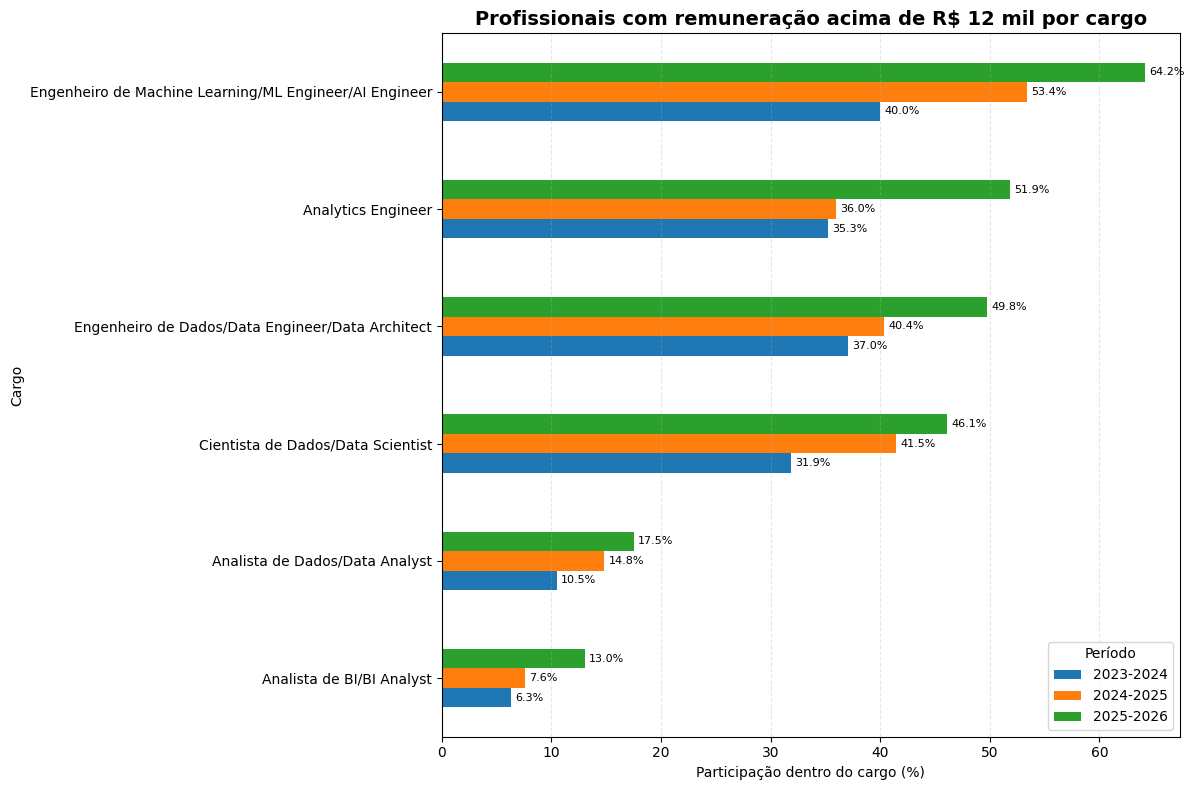

In [29]:
cargos_destaque = [
    "Engenheiro de Machine Learning/ML Engineer/AI Engineer",
    "Analytics Engineer",
    "Engenheiro de Dados/Data Engineer/Data Architect",
    "Cientista de Dados/Data Scientist",
    "Analista de Dados/Data Analyst",
    "Analista de BI/BI Analyst"
]

grafico_cargos = (
    resumo_cargo_salario_filtrado[
        resumo_cargo_salario_filtrado["cargo"].isin(cargos_destaque)
    ]
    .pivot(
        index="cargo",
        columns="periodo",
        values="percentual_acima_12k"
    )
    .fillna(0)
)

# Ordenação pela edição mais recente
grafico_cargos = grafico_cargos.sort_values(
    "2025-2026",
    ascending=True
)

display(grafico_cargos.round(2))

ax = grafico_cargos.plot(
    kind="barh",
    figsize=(12, 8)
)

plt.title(
    "Profissionais com remuneração acima de R$ 12 mil por cargo",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Participação dentro do cargo (%)")
plt.ylabel("Cargo")
plt.legend(title="Período")
plt.grid(axis="x", linestyle="--", alpha=0.3)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=8
    )

plt.tight_layout()
plt.show()

### Síntese da Questão 2 — Quais perfis profissionais são mais valorizados pelo mercado?

As análises de remuneração indicam que a valorização profissional no mercado de Dados está fortemente associada a dois fatores: **senioridade e especialização técnica**.

Em relação à senioridade, observa-se uma progressão clara da presença nas faixas superiores de remuneração. Enquanto apenas **1,5% dos profissionais Júnior** recebem acima de R$ 12 mil em 2025-2026, essa proporção alcança **11,1% entre profissionais Pleno, 52,1% entre profissionais Sênior e 83,7% entre Especialistas/Staff+**.

A análise por função reforça esse padrão de valorização. Em 2025-2026, destacam-se principalmente:

- **Engenharia de Machine Learning/IA:** 64,2% acima de R$ 12 mil;
- **Analytics Engineering:** 51,9%;
- **Engenharia de Dados:** 49,8%;
- **Ciência de Dados:** 46,1%;
- **Análise de Dados:** 17,5%;
- **Business Intelligence:** 13,0%.

Além dos níveis elevados observados na edição mais recente, funções como Machine Learning/IA, Engenharia de Dados e Ciência de Dados apresentam crescimento da participação nas faixas superiores de remuneração ao longo dos períodos analisados.

**Resposta à questão de negócio:** os dados indicam que os perfis mais valorizados financeiramente são aqueles que combinam **maior senioridade com especialização técnica**, especialmente em áreas relacionadas a Inteligência Artificial/Machine Learning, Engenharia de Dados, Analytics Engineering e Ciência de Dados.

Do ponto de vista empresarial, o resultado também sinaliza que competências técnicas especializadas representam um recurso profissional de maior valor econômico, aspecto relevante para estratégias de contratação, desenvolvimento e retenção de talentos.

> **Nota:** a remuneração é utilizada nesta análise como indicador de valorização profissional. Os resultados representam associações observadas entre os respondentes das pesquisas e não permitem estabelecer relações causais.

## 6.4 Diversidade de gênero nas carreiras de Dados

A terceira questão de negócio do Tech Challenge busca compreender o cenário de diversidade de gênero entre os profissionais do mercado brasileiro de Dados.

A análise considera a distribuição dos respondentes por gênero ao longo das três edições da pesquisa, buscando identificar mudanças na composição da amostra e possíveis diferenças de participação entre os grupos.

Antes da construção das visualizações, são identificadas e validadas as variáveis equivalentes de gênero em cada período, garantindo a comparabilidade das categorias utilizadas.

In [30]:
termos_genero = [
    "genero",
    "gênero",
    "sexo"
]

candidatas_genero = []

for coluna in df_gold.columns:

    possui_termo = any(
        termo.lower() in coluna.lower()
        for termo in termos_genero
    )

    if possui_termo:

        periodos = (
            df_gold.loc[
                df_gold[coluna].notna(),
                "periodo"
            ]
            .dropna()
            .astype(str)
            .unique()
        )

        candidatas_genero.append({
            "coluna": coluna,
            "preenchidos": int(
                df_gold[coluna].notna().sum()
            ),
            "periodos_com_dados": ", ".join(
                sorted(periodos)
            )
        })

df_genero = pd.DataFrame(candidatas_genero)

if not df_genero.empty:
    df_genero = df_genero.sort_values(
        "preenchidos",
        ascending=False
    )

display(df_genero)

,coluna,preenchidos,periodos_com_dados
4,p1_b_genero,5293,2023-2024
2,col_1_b_genero,5215,2024-2025
0,1_b_genero,3494,2025-2026
5,p1_e_3_experiencia_prejudicada_devido_a_minha_identidade_de_genero,2719,2023-2024
3,col_1_e_3_sim_devido_a_minha_identidade_de_genero,2640,2024-2025
1,1_e_3_sim_devido_a_minha_identidade_de_genero,1781,2025-2026


In [31]:
variaveis_genero = {
    "2023-2024": "p1_b_genero",
    "2024-2025": "col_1_b_genero",
    "2025-2026": "1_b_genero"
}

for periodo, coluna in variaveis_genero.items():

    print("\n" + "=" * 80)
    print(f"GÊNERO — {periodo}")
    print("=" * 80)

    resultado = (
        df_gold.loc[
            df_gold["periodo"] == periodo,
            coluna
        ]
        .value_counts(dropna=False)
    )

    display(resultado)


GÊNERO — 2023-2024


,count
p1_b_genero,
Masculino,3975
Feminino,1293
Prefiro não informar,16
Outro,9



GÊNERO — 2024-2025


,count
col_1_b_genero,
Masculino,3967
Feminino,1225
Prefiro não informar,15
Outro,8



GÊNERO — 2025-2026


,count
1_b_genero,
Masculino,2707
Feminino,767
Prefiro não informar,13
Outro,7


### 6.4.1 Evolução da distribuição dos profissionais por gênero

A distribuição por gênero permite avaliar a composição dos profissionais participantes das pesquisas e sua evolução ao longo dos três períodos analisados.

Como as categorias de resposta permanecem equivalentes entre as edições, é possível realizar uma comparação direta utilizando a participação percentual de cada gênero em seu respectivo período.

A utilização de proporções, em vez de valores absolutos, permite controlar as diferenças no número de respondentes entre as três edições da pesquisa.

,2023-2024,2024-2025,2025-2026
Masculino,75.10,76.07,77.48
Feminino,24.43,23.49,21.95
Prefiro não informar,0.30,0.29,0.37
Outro,0.17,0.15,0.20


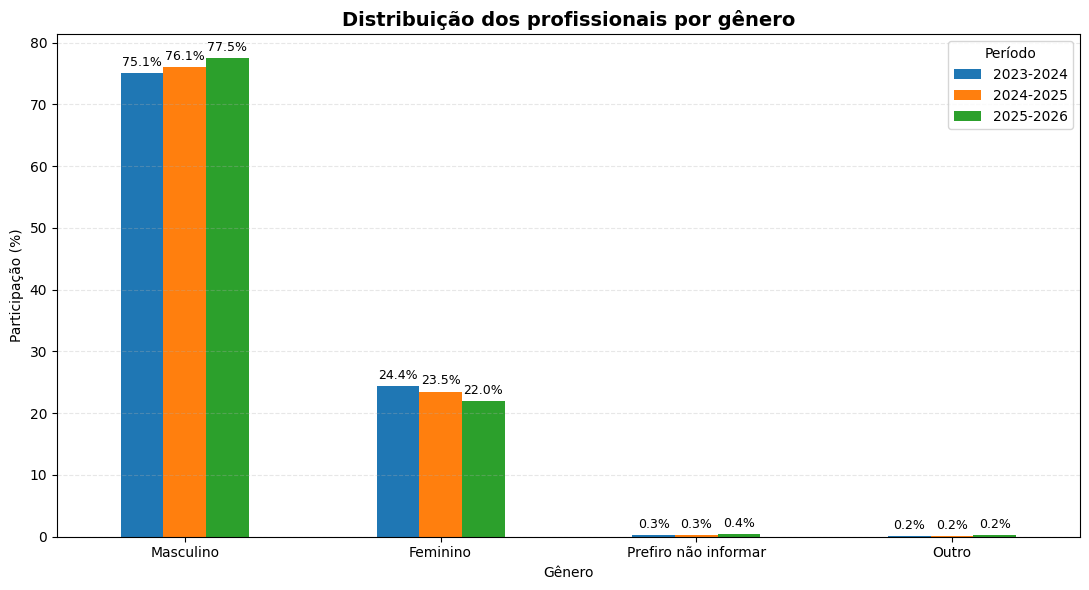

In [32]:
bases_genero = []

variaveis_genero = {
    "2023-2024": "p1_b_genero",
    "2024-2025": "col_1_b_genero",
    "2025-2026": "1_b_genero"
}

for periodo, coluna in variaveis_genero.items():

    temp = (
        df_gold.loc[
            df_gold["periodo"] == periodo,
            coluna
        ]
        .value_counts(normalize=True)
        .mul(100)
        .rename(periodo)
    )

    bases_genero.append(temp)

# Consolidação
distribuicao_genero = pd.concat(
    bases_genero,
    axis=1
).fillna(0)

ordem_genero = [
    "Masculino",
    "Feminino",
    "Prefiro não informar",
    "Outro"
]

distribuicao_genero = distribuicao_genero.reindex(
    ordem_genero
)

display(distribuicao_genero.round(2))

# Visualização
ax = distribuicao_genero.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title(
    "Distribuição dos profissionais por gênero",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Gênero")
plt.ylabel("Participação (%)")
plt.xticks(rotation=0)
plt.legend(title="Período")
plt.grid(axis="y", linestyle="--", alpha=0.3)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=9
    )

plt.tight_layout()
plt.show()

#### Interpretação

A análise evidencia uma composição predominantemente masculina entre os profissionais participantes das três edições da pesquisa.

A participação de profissionais do gênero **Masculino** apresentou crescimento gradual, passando de **75,1% em 2023-2024 para 76,1% em 2024-2025 e 77,5% em 2025-2026**.

Em sentido contrário, a participação do gênero **Feminino apresentou redução ao longo dos períodos analisados**, passando de **24,4% em 2023-2024 para 23,5% em 2024-2025 e 22,0% em 2025-2026**. Entre o primeiro e o último período, a redução foi de aproximadamente **2,5 pontos percentuais**.

As categorias **"Prefiro não informar"** e **"Outro"** permanecem abaixo de 1% dos respondentes em todas as edições.

Os resultados indicam, portanto, uma **expressiva desigualdade na representação de gênero entre os respondentes**, com aproximadamente três quartos da amostra composta por homens. Além disso, não se observa redução dessa diferença ao longo dos períodos analisados; pelo contrário, a participação relativa feminina apresenta uma pequena queda nas três edições.

> **Nota metodológica:** os resultados representam a composição dos respondentes das pesquisas e não devem ser interpretados isoladamente como uma estimativa da distribuição de gênero de todo o mercado brasileiro de Dados.

In [33]:
variaveis_experiencia_genero = {
    "2023-2024":
        "p1_e_3_experiencia_prejudicada_devido_a_minha_identidade_de_genero",

    "2024-2025":
        "col_1_e_3_sim_devido_a_minha_identidade_de_genero",

    "2025-2026":
        "1_e_3_sim_devido_a_minha_identidade_de_genero"
}

for periodo, coluna in variaveis_experiencia_genero.items():

    print("\n" + "=" * 80)
    print(f"EXPERIÊNCIA PROFISSIONAL E GÊNERO — {periodo}")
    print("=" * 80)

    resultado = (
        df_gold.loc[
            df_gold["periodo"] == periodo,
            coluna
        ]
        .value_counts(dropna=False)
    )

    display(resultado)


EXPERIÊNCIA PROFISSIONAL E GÊNERO — 2023-2024


,count
p1_e_3_experiencia_prejudicada_devido_a_minha_identidade_de_genero,
NaN,2574
0.0,1927
1.0,792



EXPERIÊNCIA PROFISSIONAL E GÊNERO — 2024-2025


,count
col_1_e_3_sim_devido_a_minha_identidade_de_genero,
NaN,2575
0.0,1796
1.0,844



EXPERIÊNCIA PROFISSIONAL E GÊNERO — 2025-2026


,count
1_e_3_sim_devido_a_minha_identidade_de_genero,
NaN,1713
0.0,1257
1.0,524


### 6.4.2 Experiência profissional e identidade de gênero

Além da representatividade, a análise de diversidade também considera a percepção dos profissionais sobre possíveis impactos da identidade de gênero em sua trajetória profissional.

As três edições da pesquisa apresentam uma variável relacionada à experiência profissional prejudicada devido à identidade de gênero. Como essa questão possui respostas ausentes decorrentes da estrutura do questionário, a análise considera apenas os registros com resposta válida.

A comparação é realizada por gênero e período, permitindo avaliar se existem diferenças na proporção de profissionais que relatam esse tipo de experiência.

In [34]:
bases_impacto_genero = []

config_genero_impacto = {
    "2023-2024": (
        "p1_b_genero",
        "p1_e_3_experiencia_prejudicada_devido_a_minha_identidade_de_genero"
    ),
    "2024-2025": (
        "col_1_b_genero",
        "col_1_e_3_sim_devido_a_minha_identidade_de_genero"
    ),
    "2025-2026": (
        "1_b_genero",
        "1_e_3_sim_devido_a_minha_identidade_de_genero"
    )
}

for periodo, (col_genero, col_impacto) in config_genero_impacto.items():

    temp = df_gold.loc[
        df_gold["periodo"] == periodo,
        [col_genero, col_impacto]
    ].copy()

    temp.columns = ["genero", "impacto_genero"]

    # Apenas respostas válidas da questão
    temp = temp[
        temp["impacto_genero"].isin([0, 1])
    ]

    temp["periodo"] = periodo

    bases_impacto_genero.append(temp)

df_impacto_genero = pd.concat(
    bases_impacto_genero,
    ignore_index=True
)

# Percentual de respostas 1 dentro de cada gênero/período
resumo_impacto_genero = (
    df_impacto_genero
    .groupby(
        ["periodo", "genero"],
        observed=True
    )
    .agg(
        quantidade=("impacto_genero", "size"),
        percentual_impacto=("impacto_genero", "mean")
    )
    .reset_index()
)

resumo_impacto_genero["percentual_impacto"] *= 100

display(
    resumo_impacto_genero.round(2)
)

,periodo,genero,quantidade,percentual_impacto
0,2023-2024,Feminino,1270,57.64
1,2023-2024,Masculino,1424,3.37
2,2023-2024,Outro,9,66.67
3,2023-2024,Prefiro não informar,16,37.50
4,2024-2025,Feminino,1225,63.59
5,2024-2025,Masculino,1392,4.02
6,2024-2025,Outro,8,25.00
7,2024-2025,Prefiro não informar,15,46.67
8,2025-2026,Feminino,767,61.93
9,2025-2026,Masculino,994,4.02


periodo,2023-2024,2024-2025,2025-2026
genero,,,
Feminino,57.64,63.59,61.93
Masculino,3.37,4.02,4.02


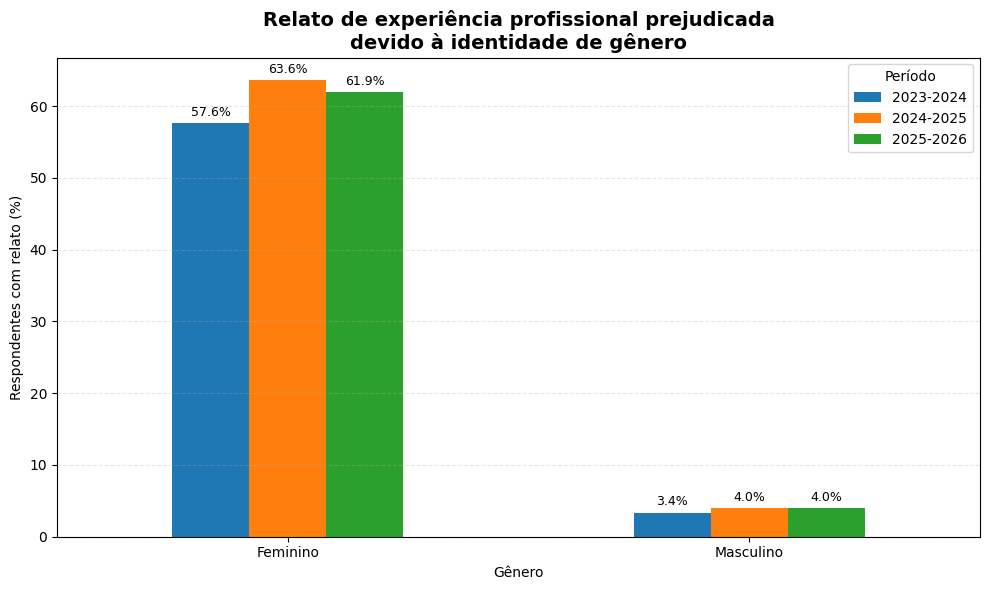

In [35]:
# Seleciona grupos com amostra adequada para comparação
grafico_impacto_genero = (
    resumo_impacto_genero[
        resumo_impacto_genero["genero"].isin(
            ["Feminino", "Masculino"]
        )
    ]
    .pivot(
        index="genero",
        columns="periodo",
        values="percentual_impacto"
    )
)

# Ordem de apresentação
grafico_impacto_genero = grafico_impacto_genero.reindex(
    ["Feminino", "Masculino"]
)

display(grafico_impacto_genero.round(2))

ax = grafico_impacto_genero.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Relato de experiência profissional prejudicada\n"
    "devido à identidade de gênero",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Gênero")
plt.ylabel("Respondentes com relato (%)")
plt.xticks(rotation=0)
plt.legend(title="Período")
plt.grid(axis="y", linestyle="--", alpha=0.3)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=9
    )

plt.tight_layout()
plt.show()

### Síntese da Questão 3 — Qual é o cenário de diversidade de gênero nas carreiras de Dados?

Os resultados das três pesquisas evidenciam um cenário de **forte desigualdade na representação de gênero** entre os respondentes do mercado de Dados.

A participação feminina apresentou redução gradual, passando de **24,4% em 2023-2024 para 23,5% em 2024-2025 e 22,0% em 2025-2026**, enquanto a participação masculina aumentou de **75,1% para 77,5%** no mesmo intervalo.

A análise da experiência profissional amplia esse diagnóstico. Entre as mulheres com resposta válida para a questão relacionada a prejuízo profissional devido à identidade de gênero, **57,6% em 2023-2024, 63,6% em 2024-2025 e 61,9% em 2025-2026** apresentam indicação positiva. Entre os homens, os percentuais permaneceram próximos de **3% a 4%**.

**Resposta à questão de negócio:** os dados analisados apontam simultaneamente para **menor representação feminina** e para uma diferença expressiva entre homens e mulheres nos relatos de experiências profissionais prejudicadas relacionadas à identidade de gênero.

Do ponto de vista empresarial, os resultados reforçam a relevância de estratégias voltadas à **diversidade, inclusão, desenvolvimento e retenção de profissionais**, acompanhadas por indicadores capazes de avaliar não apenas representatividade, mas também a experiência dos diferentes grupos no ambiente profissional.

> **Nota metodológica:** os resultados representam os respondentes das pesquisas. Na análise de experiência profissional, foram consideradas apenas respostas válidas, e não se estabelece relação causal a partir dos resultados observados.

## 6.5 Tecnologias com maior adoção entre os profissionais

A quarta questão de negócio do Tech Challenge busca identificar quais tecnologias apresentam maior adoção entre os profissionais do mercado brasileiro de Dados.

Para construir esse diagnóstico, são consideradas diferentes dimensões do ecossistema tecnológico, como linguagens de programação, bancos de dados, ferramentas de Business Intelligence, tecnologias de Cloud e outras ferramentas utilizadas pelos profissionais.

Como as três edições da pesquisa podem apresentar diferenças na estrutura e nomenclatura das perguntas, inicialmente é realizado o mapeamento das variáveis relacionadas às tecnologias, buscando identificar informações conceitualmente equivalentes e comparáveis ao longo dos períodos analisados.

In [36]:
termos_tecnologia = [
    "linguagem",
    "python",
    "sql",
    "banco",
    "database",
    "cloud",
    "nuvem",
    "bi_",
    "business_intelligence",
    "power_bi",
    "tableau",
    "ferramenta",
    "tecnologia"
]

candidatas_tecnologia = []

for coluna in df_gold.columns:

    possui_termo = any(
        termo.lower() in coluna.lower()
        for termo in termos_tecnologia
    )

    if possui_termo:

        periodos = (
            df_gold.loc[
                df_gold[coluna].notna(),
                "periodo"
            ]
            .dropna()
            .astype(str)
            .unique()
        )

        candidatas_tecnologia.append({
            "coluna": coluna,
            "preenchidos": int(
                df_gold[coluna].notna().sum()
            ),
            "periodos_com_dados": ", ".join(
                sorted(periodos)
            )
        })

df_tecnologias = pd.DataFrame(
    candidatas_tecnologia
)

if not df_tecnologias.empty:

    df_tecnologias = (
        df_tecnologias
        .sort_values(
            ["periodos_com_dados", "preenchidos"],
            ascending=[True, False]
        )
        .reset_index(drop=True)
    )

print(
    f"Variáveis encontradas: "
    f"{len(df_tecnologias)}"
)

display(df_tecnologias)

Variáveis encontradas: 212


,coluna,preenchidos,periodos_com_dados
0,p2_o_8_maturidade_da_empresa_em_termos_de_tecnologia_e_dados,4727,2023-2024
1,p4_b_1_dados_relacionais_estruturados_em_bancos_sql,3772,2023-2024
2,p4_b_2_dados_armazenados_em_bancos_nosql,3772,2023-2024
3,p4_c_1_dados_relacionais_estruturados_em_bancos_sql,3772,2023-2024
4,p4_c_2_dados_armazenados_em_bancos_nosql,3772,2023-2024
...,...,...,...
207,8_c_tecnologias_ds,489,2025-2026
208,8_d_7_realizando_construcoes_de_dashboards_em_ferramentas_de_bi_como_powerbi_tableau_looker_qlik_etc,489,2025-2026
209,8_d_8_utilizando_ferramentas_avancadas_de_estatistica_como_sas_spss_stata_etc_para_realizar_analises,489,2025-2026
210,6_f_tecnologia_data_warehouse,420,2025-2026


In [37]:
grupos_tecnologia = {
    "Linguagens": [
        "linguagem", "python", "sql", "r_"
    ],
    "Business Intelligence": [
        "business_intelligence", "power_bi",
        "tableau", "looker", "dashboard"
    ],
    "Bancos de Dados": [
        "banco", "database", "mysql",
        "postgres", "sql_server", "mongodb"
    ],
    "Cloud": [
        "cloud", "nuvem", "aws",
        "azure", "gcp"
    ]
}

for grupo, termos in grupos_tecnologia.items():

    print("\n" + "=" * 100)
    print(grupo.upper())
    print("=" * 100)

    encontradas = []

    for coluna in df_gold.columns:

        if any(
            termo.lower() in coluna.lower()
            for termo in termos
        ):

            preenchidos = int(
                df_gold[coluna].notna().sum()
            )

            if preenchidos == 0:
                continue

            periodos = (
                df_gold.loc[
                    df_gold[coluna].notna(),
                    "periodo"
                ]
                .dropna()
                .astype(str)
                .unique()
            )

            encontradas.append({
                "coluna": coluna,
                "preenchidos": preenchidos,
                "periodos": ", ".join(sorted(periodos))
            })

    resultado_grupo = pd.DataFrame(encontradas)

    if not resultado_grupo.empty:

        resultado_grupo = (
            resultado_grupo
            .sort_values(
                "preenchidos",
                ascending=False
            )
            .reset_index(drop=True)
        )

        print(
            f"Total encontrado: "
            f"{len(resultado_grupo)}"
        )

        display(
            resultado_grupo.head(40)
        )

    else:
        print("Nenhuma variável encontrada.")


LINGUAGENS
Total encontrado: 321


,coluna,preenchidos,periodos
0,p1_c_cor_raca_etnia,5293,2023-2024
1,col_1_c_cor_raca_etnia,5215,2024-2025
2,col_2_q_empresa_passou_por_layoff_em_2024,4861,2024-2025
3,col_2_r_modelo_de_trabalho_atual,4861,2024-2025
4,col_2_o_6_oportunidade_de_aprendizado_e_trabalhar_com_referencias,4861,2024-2025
5,col_2_n_planos_de_mudar_de_emprego_6m,4861,2024-2025
6,p2_r_atualmente_qual_a_sua_forma_de_trabalho,4753,2023-2024
7,p2_n_voce_pretende_mudar_de_emprego_nos_proximos_6_meses,4753,2023-2024
8,p2_j_quanto_tempo_de_experiencia_na_area_de_ti_engenharia_de_software_voce_teve_antes_de_comecar_a_trabalhar_na_area_de_dados,4753,2023-2024
9,p2_q_empresa_que_trabaha_passou_por_layoff_em_2023,4753,2023-2024



BUSINESS INTELLIGENCE
Total encontrado: 34


,coluna,preenchidos,periodos
0,p4_j_8_looker_studio_google_data_studio,3772,2023-2024
1,p4_j_7_looker,3772,2023-2024
2,p4_j_3_tableau,3772,2023-2024
3,p4_j_15_oracle_business_intelligence,3772,2023-2024
4,col_4_j_7_looker,3617,2024-2025
5,col_4_j_8_looker_studio_google_data_studio,3617,2024-2025
6,col_4_j_12_oracle_business_intelligence,3617,2024-2025
7,col_4_j_3_tableau,3617,2024-2025
8,4_g_3_tableau,2105,2025-2026
9,4_g_12_oracle_business_intelligence,2105,2025-2026



BANCOS DE DADOS
Total encontrado: 34


,coluna,preenchidos,periodos
0,p4_g_12_postgresql,3772,2023-2024
1,p4_c_2_dados_armazenados_em_bancos_nosql,3772,2023-2024
2,p4_g_8_mongodb,3772,2023-2024
3,p4_b_1_dados_relacionais_estruturados_em_bancos_sql,3772,2023-2024
4,p4_g_1_mysql,3772,2023-2024
5,p4_g_3_sql_server,3772,2023-2024
6,p4_c_1_dados_relacionais_estruturados_em_bancos_sql,3772,2023-2024
7,p4_b_2_dados_armazenados_em_bancos_nosql,3772,2023-2024
8,p4_g_quais_dos_bancos_de_dados_fontes_de_dados_listados_abaixo_voce_utiliza_no_trabalho,3770,2023-2024
9,col_4_b_2_dados_armazenados_em_bancos_nosql,3617,2024-2025



CLOUD
Total encontrado: 39


,coluna,preenchidos,periodos
0,p4_i_cloud_preferida,3771,2023-2024
1,p4_h_3_google_cloud_gcp,3613,2023-2024
2,p4_h_1_azure_microsoft,3613,2023-2024
3,p4_h_7_cloud_propria,3613,2023-2024
4,p4_h_dentre_as_opcoes_listadas_qual_sua_cloud_preferida,3613,2023-2024
5,p4_h_2_amazon_web_services_aws,3613,2023-2024
6,p4_h_4_oracle_cloud,3613,2023-2024
7,p4_h_6_servidores_on_premise_nao_utilizamos_cloud,3613,2023-2024
8,col_4_h_1_amazon_web_services_aws,3587,2024-2025
9,col_4_i_cloud_preferida,3587,2024-2025


In [38]:
# Mapeamento específico das variáveis de linguagens de programação

prefixos_linguagens = {
    "2023-2024": "p4_d_",
    "2024-2025": "col_4_d_",
    "2025-2026": "4_c_"
}

for periodo, prefixo in prefixos_linguagens.items():

    colunas = [
        coluna for coluna in df_gold.columns
        if coluna.startswith(prefixo)
    ]

    print("\n" + "=" * 100)
    print(f"LINGUAGENS — {periodo}")
    print("=" * 100)
    print(f"Total de variáveis encontradas: {len(colunas)}\n")

    for coluna in colunas:
        preenchidos = df_gold[coluna].notna().sum()

        if preenchidos > 0:
            print(
                f"{coluna} | "
                f"preenchidos: {preenchidos}"
            )


LINGUAGENS — 2023-2024
Total de variáveis encontradas: 16

p4_d_10_scala | preenchidos: 3772
p4_d_11_matlab | preenchidos: 3772
p4_d_12_rust | preenchidos: 3772
p4_d_13_php | preenchidos: 3772
p4_d_14_javascript | preenchidos: 3772
p4_d_15_nao_utilizo_nenhuma_linguagem | preenchidos: 3772
p4_d_1_sql | preenchidos: 3772
p4_d_2_r | preenchidos: 3772
p4_d_3_python | preenchidos: 3772
p4_d_4_c_c_c | preenchidos: 3772
p4_d_5_net | preenchidos: 3772
p4_d_6_java | preenchidos: 3772
p4_d_7_julia | preenchidos: 3772
p4_d_8_sas_stata | preenchidos: 3772
p4_d_9_visual_basic_vba | preenchidos: 3772
p4_d_quais_das_linguagens_listadas_abaixo_voce_utiliza_no_trabalho | preenchidos: 3772

LINGUAGENS — 2024-2025
Total de variáveis encontradas: 16

col_4_d_10_scala | preenchidos: 3587
col_4_d_11_matlab | preenchidos: 3587
col_4_d_12_rust | preenchidos: 3587
col_4_d_13_php | preenchidos: 3587
col_4_d_14_javascript | preenchidos: 3587
col_4_d_15_nao_utilizo_nenhuma_das_linguagens_listadas | preenchidos: 

In [39]:
validacao_linguagens = {
    "2023-2024": [
        "p4_d_1_sql",
        "p4_d_2_r",
        "p4_d_3_python"
    ],
    "2024-2025": [
        "col_4_d_1_sql",
        "col_4_d_2_r",
        "col_4_d_3_python"
    ],
    "2025-2026": [
        "4_c_1_sql",
        "4_c_2_r",
        "4_c_3_python"
    ]
}

for periodo, colunas in validacao_linguagens.items():

    print("\n" + "=" * 80)
    print(f"VALIDAÇÃO — {periodo}")
    print("=" * 80)

    for coluna in colunas:

        print(f"\n{coluna}")

        display(
            df_gold.loc[
                df_gold["periodo"] == periodo,
                coluna
            ].value_counts(dropna=False)
        )


VALIDAÇÃO — 2023-2024

p4_d_1_sql


,count
p4_d_1_sql,
1.0,3156
NaN,1521
0.0,616



p4_d_2_r


,count
p4_d_2_r,
0.0,3364
NaN,1521
1.0,408



p4_d_3_python


...

,count
4_c_1_sql,
1.0,1763
NaN,1399
0.0,332



4_c_2_r


,count
4_c_2_r,
0.0,1768
NaN,1399
1.0,327



4_c_3_python


,count
4_c_3_python,
1.0,1928
NaN,1399
0.0,167


### 6.5.1 Linguagens utilizadas pelos profissionais

A análise das linguagens considera tecnologias presentes de forma comparável nas três edições da pesquisa.

Como as variáveis são estruturadas como indicadores binários, a participação de cada linguagem é calculada considerando apenas os respondentes com resposta válida para o respectivo bloco do questionário, desconsiderando valores ausentes.

Para preservar a comparabilidade temporal, são consideradas nesta análise apenas linguagens presentes nas três edições pesquisadas.

In [40]:
linguagens_comparaveis = {
    "SQL": {
        "2023-2024": "p4_d_1_sql",
        "2024-2025": "col_4_d_1_sql",
        "2025-2026": "4_c_1_sql"
    },
    "R": {
        "2023-2024": "p4_d_2_r",
        "2024-2025": "col_4_d_2_r",
        "2025-2026": "4_c_2_r"
    },
    "Python": {
        "2023-2024": "p4_d_3_python",
        "2024-2025": "col_4_d_3_python",
        "2025-2026": "4_c_3_python"
    },
    "C/C++/C#": {
        "2023-2024": "p4_d_4_c_c_c",
        "2024-2025": "col_4_d_4_c_c_c",
        "2025-2026": "4_c_4_c_c_c"
    },
    "Julia": {
        "2023-2024": "p4_d_7_julia",
        "2024-2025": "col_4_d_7_julia",
        "2025-2026": "4_c_5_julia"
    },
    "VBA": {
        "2023-2024": "p4_d_9_visual_basic_vba",
        "2024-2025": "col_4_d_9_visual_basic_vba",
        "2025-2026": "4_c_6_visual_basic_vba"
    },
    "Scala": {
        "2023-2024": "p4_d_10_scala",
        "2024-2025": "col_4_d_10_scala",
        "2025-2026": "4_c_7_scala"
    },
    "Rust": {
        "2023-2024": "p4_d_12_rust",
        "2024-2025": "col_4_d_12_rust",
        "2025-2026": "4_c_9_rust"
    }
}

resultados_linguagens = []

for linguagem, periodos in linguagens_comparaveis.items():

    for periodo, coluna in periodos.items():

        valores = df_gold.loc[
            df_gold["periodo"] == periodo,
            coluna
        ]

        valores_validos = valores[
            valores.isin([0, 1])
        ]

        percentual = (
            valores_validos.mean() * 100
            if len(valores_validos) > 0
            else None
        )

        resultados_linguagens.append({
            "linguagem": linguagem,
            "periodo": periodo,
            "respostas_validas": len(valores_validos),
            "percentual": percentual
        })

df_adocao_linguagens = pd.DataFrame(
    resultados_linguagens
)

tabela_linguagens = (
    df_adocao_linguagens
    .pivot(
        index="linguagem",
        columns="periodo",
        values="percentual"
    )
    .sort_values(
        "2025-2026",
        ascending=False
    )
)

display(tabela_linguagens.round(2))

periodo,2023-2024,2024-2025,2025-2026
linguagem,,,
Python,74.89,81.80,92.03
SQL,83.67,87.68,84.15
R,10.82,9.81,15.61
Scala,3.47,3.51,3.34
C/C++/C#,1.86,1.28,2.34
Rust,0.19,0.33,1.67
Julia,0.21,0.17,0.86
VBA,7.56,5.99,0.05


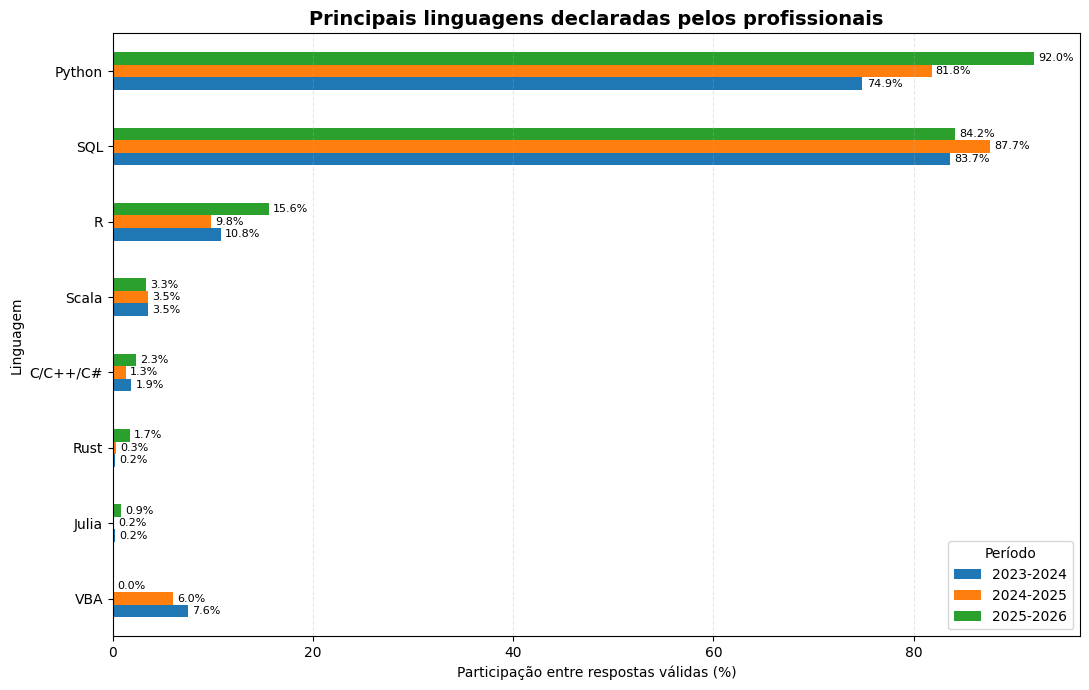

In [41]:
# Ordenação pelas linguagens mais representativas em 2025-2026
tabela_linguagens_grafico = (
    tabela_linguagens
    .sort_values("2025-2026", ascending=True)
)

ax = tabela_linguagens_grafico.plot(
    kind="barh",
    figsize=(11, 7)
)

plt.title(
    "Principais linguagens declaradas pelos profissionais",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Participação entre respostas válidas (%)")
plt.ylabel("Linguagem")
plt.legend(title="Período")
plt.grid(axis="x", linestyle="--", alpha=0.3)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=8
    )

plt.tight_layout()
plt.show()

#### Interpretação

A análise evidencia uma forte concentração em **Python e SQL**, que se destacam das demais linguagens consideradas nas três edições.

O **Python** apresenta crescimento expressivo, passando de **74,9% em 2023-2024 para 81,8% em 2024-2025 e 92,0% em 2025-2026**. O **SQL** também mantém presença elevada durante todo o período, registrando **83,7%, 87,7% e 84,2%**, respectivamente.

O **R** aparece em um segundo patamar de participação, com **10,8% em 2023-2024, 9,8% em 2024-2025 e 15,6% em 2025-2026**. Scala, C/C++/C#, Rust e Julia apresentam percentuais consideravelmente menores.

Os resultados reforçam a centralidade de **Python e SQL no ecossistema de Dados**, enquanto as demais linguagens apresentam utilização ou preferência mais específica entre os respondentes.

> **Nota metodológica:** foram consideradas apenas linguagens presentes nas três edições e respostas válidas de cada variável. A edição de 2025-2026 apresenta alteração na formulação do bloco de linguagens em relação às edições anteriores, aproximando-se de uma declaração de preferência. Por esse motivo, as diferenças temporais, especialmente na edição mais recente, devem ser interpretadas com cautela e não como variações perfeitamente equivalentes de adoção.

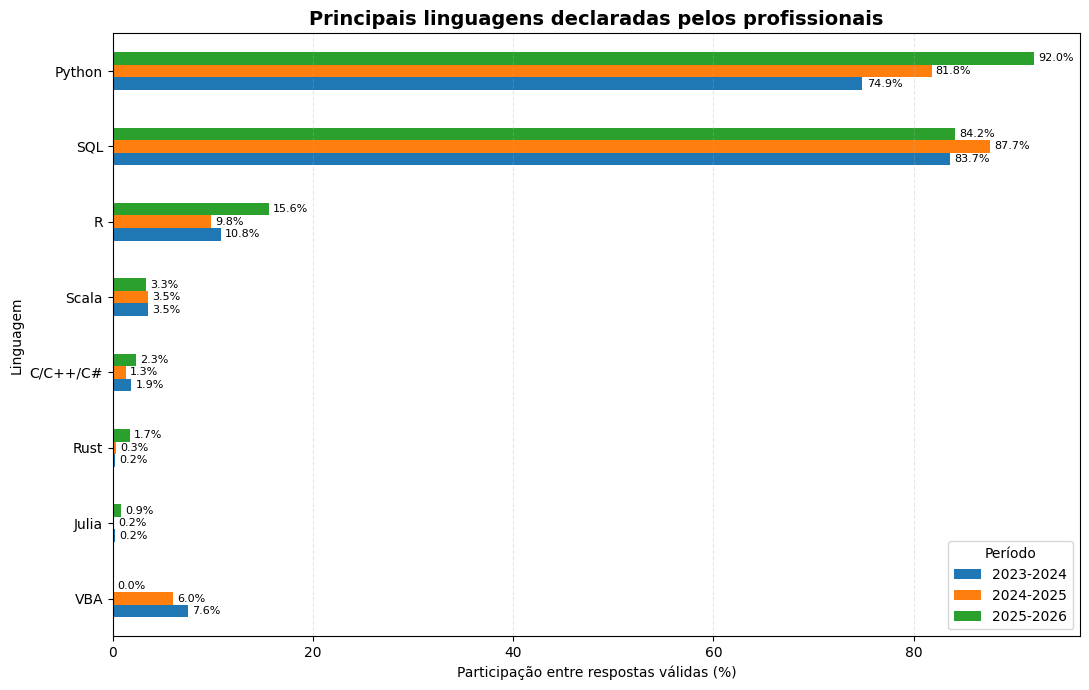

In [42]:
# Ordenação pelas linguagens mais representativas em 2025-2026
tabela_linguagens_grafico = (
    tabela_linguagens
    .sort_values("2025-2026", ascending=True)
)

ax = tabela_linguagens_grafico.plot(
    kind="barh",
    figsize=(11, 7)
)

plt.title(
    "Principais linguagens declaradas pelos profissionais",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Participação entre respostas válidas (%)")
plt.ylabel("Linguagem")
plt.legend(title="Período")
plt.grid(axis="x", linestyle="--", alpha=0.3)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=8
    )

plt.tight_layout()
plt.show()

In [43]:
prefixos_bancos = {
    "2023-2024": ["p4_b_", "p4_c_"],
    "2024-2025": ["col_4_b_", "col_4_c_"],
    "2025-2026": ["4_b_"]
}

termos_bancos = [
    "mysql",
    "sql_server",
    "postgres",
    "oracle",
    "mongodb",
    "dynamodb",
    "redis",
    "elasticsearch",
    "firebase",
    "mariadb",
    "cassandra",
    "sqlite",
    "db2",
    "hbase"
]

for periodo, prefixos in prefixos_bancos.items():

    print("\n" + "=" * 100)
    print(f"BANCOS DE DADOS — {periodo}")
    print("=" * 100)

    colunas = [
        coluna for coluna in df_gold.columns
        if any(coluna.startswith(p) for p in prefixos)
        and any(termo in coluna.lower() for termo in termos_bancos)
    ]

    print(f"Total de variáveis encontradas: {len(colunas)}\n")

    for coluna in colunas:

        preenchidos = int(
            df_gold[coluna].notna().sum()
        )

        if preenchidos > 0:
            print(f"{coluna} | preenchidos: {preenchidos}")


BANCOS DE DADOS — 2023-2024
Total de variáveis encontradas: 0


BANCOS DE DADOS — 2024-2025
Total de variáveis encontradas: 0


BANCOS DE DADOS — 2025-2026
Total de variáveis encontradas: 0



In [44]:
termos_busca_bancos = [
    "banco",
    "dados_relacionais",
    "dados_nao_relacionais",
    "nosql",
    "sql_server",
    "postgres",
    "mysql",
    "mongodb",
    "oracle",
    "database"
]

colunas_bancos = []

for coluna in df_gold.columns:

    if any(
        termo in coluna.lower()
        for termo in termos_busca_bancos
    ):

        preenchidos = int(
            df_gold[coluna].notna().sum()
        )

        if preenchidos > 0:

            periodos = (
                df_gold.loc[
                    df_gold[coluna].notna(),
                    "periodo"
                ]
                .dropna()
                .astype(str)
                .unique()
            )

            colunas_bancos.append({
                "coluna": coluna,
                "preenchidos": preenchidos,
                "periodos": ", ".join(
                    sorted(periodos)
                )
            })

resultado_bancos = pd.DataFrame(colunas_bancos)

if not resultado_bancos.empty:
    resultado_bancos = (
        resultado_bancos
        .sort_values(
            ["periodos", "preenchidos"],
            ascending=[True, False]
        )
        .reset_index(drop=True)
    )

print(
    f"Total de variáveis encontradas: "
    f"{len(resultado_bancos)}"
)

display(resultado_bancos)

Total de variáveis encontradas: 49


,coluna,preenchidos,periodos
0,p4_b_1_dados_relacionais_estruturados_em_bancos_sql,3772,2023-2024
1,p4_b_2_dados_armazenados_em_bancos_nosql,3772,2023-2024
2,p4_c_1_dados_relacionais_estruturados_em_bancos_sql,3772,2023-2024
3,p4_c_2_dados_armazenados_em_bancos_nosql,3772,2023-2024
4,p4_g_12_postgresql,3772,2023-2024
5,p4_g_1_mysql,3772,2023-2024
6,p4_g_2_oracle,3772,2023-2024
7,p4_g_3_sql_server,3772,2023-2024
8,p4_g_8_mongodb,3772,2023-2024
9,p4_j_15_oracle_business_intelligence,3772,2023-2024


In [45]:
validacao_bancos = {
    "2023-2024": [
        "p4_g_1_mysql",
        "p4_g_2_oracle",
        "p4_g_3_sql_server",
        "p4_g_8_mongodb",
        "p4_g_12_postgresql"
    ],
    "2024-2025": [
        "col_4_g_1_mysql",
        "col_4_g_2_oracle",
        "col_4_g_3_sql_server",
        "col_4_g_8_mongodb",
        "col_4_g_12_postgresql"
    ],
    "2025-2026": [
        "4_d_1_mysql",
        "4_d_2_oracle",
        "4_d_3_sql_server",
        "4_d_8_mongodb",
        "4_d_12_postgresql"
    ]
}

for periodo, colunas in validacao_bancos.items():

    print("\n" + "=" * 80)
    print(f"VALIDAÇÃO BANCOS — {periodo}")
    print("=" * 80)

    for coluna in colunas:

        valores = df_gold.loc[
            df_gold["periodo"] == periodo,
            coluna
        ]

        print(f"\n{coluna}")

        display(
            valores.value_counts(
                dropna=False
            )
        )


VALIDAÇÃO BANCOS — 2023-2024

p4_g_1_mysql


,count
p4_g_1_mysql,
0.0,2845
NaN,1521
1.0,927



p4_g_2_oracle


,count
p4_g_2_oracle,
0.0,3086
NaN,1521
1.0,686



p4_g_3_sql_server


...

,count
4_d_3_sql_server,
NaN,1399
0.0,1393
1.0,702



4_d_8_mongodb


,count
4_d_8_mongodb,
0.0,1785
NaN,1399
1.0,310



4_d_12_postgresql


,count
4_d_12_postgresql,
NaN,1399
0.0,1324
1.0,771


### 6.5.2 Bancos de Dados utilizados pelos profissionais

A análise de bancos de dados considera tecnologias presentes de forma equivalente nas três edições da pesquisa: **MySQL, Oracle, SQL Server, MongoDB e PostgreSQL**.

As variáveis são estruturadas como indicadores binários de utilização. Dessa forma, a participação de cada tecnologia é calculada considerando apenas as respostas válidas do respectivo bloco, desconsiderando valores ausentes.

Essa abordagem permite comparar a presença relativa das principais tecnologias de bancos de dados entre os períodos analisados.

In [46]:
bancos_comparaveis = {
    "MySQL": {
        "2023-2024": "p4_g_1_mysql",
        "2024-2025": "col_4_g_1_mysql",
        "2025-2026": "4_d_1_mysql"
    },
    "Oracle": {
        "2023-2024": "p4_g_2_oracle",
        "2024-2025": "col_4_g_2_oracle",
        "2025-2026": "4_d_2_oracle"
    },
    "SQL Server": {
        "2023-2024": "p4_g_3_sql_server",
        "2024-2025": "col_4_g_3_sql_server",
        "2025-2026": "4_d_3_sql_server"
    },
    "MongoDB": {
        "2023-2024": "p4_g_8_mongodb",
        "2024-2025": "col_4_g_8_mongodb",
        "2025-2026": "4_d_8_mongodb"
    },
    "PostgreSQL": {
        "2023-2024": "p4_g_12_postgresql",
        "2024-2025": "col_4_g_12_postgresql",
        "2025-2026": "4_d_12_postgresql"
    }
}

resultados_bancos = []

for banco, periodos in bancos_comparaveis.items():

    for periodo, coluna in periodos.items():

        valores = df_gold.loc[
            df_gold["periodo"] == periodo,
            coluna
        ]

        valores_validos = valores[
            valores.isin([0, 1])
        ]

        percentual = (
            valores_validos.mean() * 100
            if len(valores_validos) > 0
            else None
        )

        resultados_bancos.append({
            "banco": banco,
            "periodo": periodo,
            "respostas_validas": len(valores_validos),
            "percentual": percentual
        })

df_adocao_bancos = pd.DataFrame(
    resultados_bancos
)

tabela_bancos = (
    df_adocao_bancos
    .pivot(
        index="banco",
        columns="periodo",
        values="percentual"
    )
    .sort_values(
        "2025-2026",
        ascending=False
    )
)

display(tabela_bancos.round(2))

periodo,2023-2024,2024-2025,2025-2026
banco,,,
PostgreSQL,28.31,31.39,36.80
SQL Server,32.05,29.33,33.51
MySQL,24.58,23.19,28.54
Oracle,18.19,17.93,19.57
MongoDB,11.35,11.46,14.80


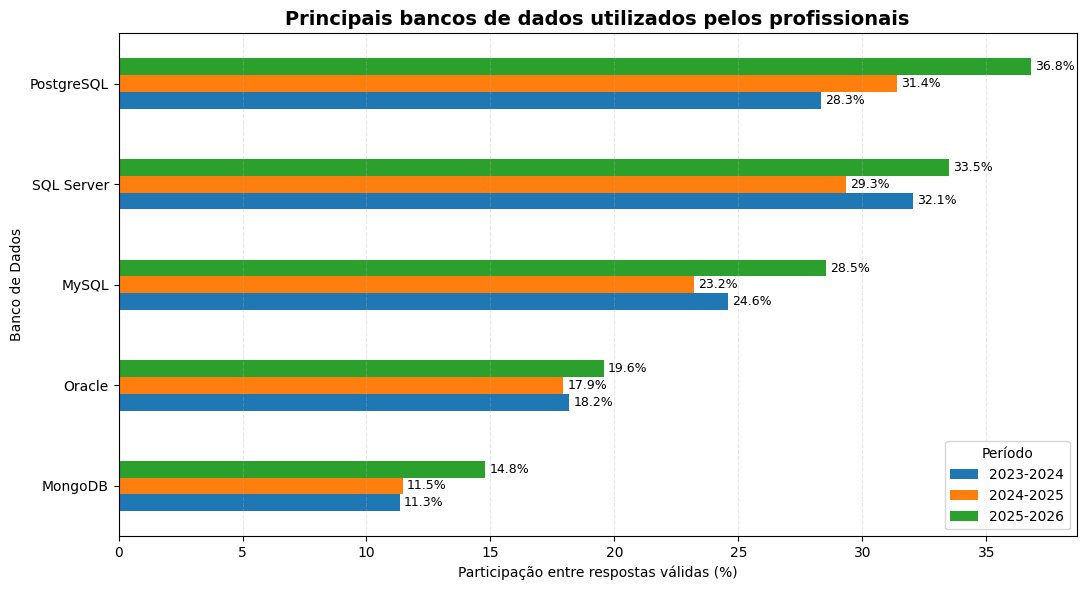

In [47]:
# Ordenação pelo período mais recente
tabela_bancos_grafico = (
    tabela_bancos
    .sort_values("2025-2026", ascending=True)
)

ax = tabela_bancos_grafico.plot(
    kind="barh",
    figsize=(11, 6)
)

plt.title(
    "Principais bancos de dados utilizados pelos profissionais",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Participação entre respostas válidas (%)")
plt.ylabel("Banco de Dados")
plt.legend(title="Período")
plt.grid(axis="x", linestyle="--", alpha=0.3)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=9
    )

plt.tight_layout()
plt.show()

#### Interpretação

A análise dos bancos de dados evidencia uma distribuição mais equilibrada entre diferentes tecnologias quando comparada à concentração observada nas linguagens de programação.

O **PostgreSQL apresenta crescimento contínuo ao longo das três edições**, passando de **28,3% em 2023-2024 para 31,4% em 2024-2025 e 36,8% em 2025-2026**, tornando-se a tecnologia com maior participação entre os bancos analisados na edição mais recente.

O **SQL Server** permanece entre as principais tecnologias utilizadas, com **32,1%, 29,3% e 33,5%**, respectivamente. O **MySQL** também apresenta participação relevante, passando de **24,6% para 23,2% e posteriormente 28,5%**.

Oracle e MongoDB apresentam percentuais inferiores aos três primeiros colocados, embora ambos registrem crescimento na edição de 2025-2026.

Os resultados indicam, portanto, um ecossistema de bancos de dados relativamente diversificado, com destaque para a **expansão do PostgreSQL** e a permanência do **SQL Server e MySQL** entre as tecnologias mais presentes nas três pesquisas.

### 6.5.3 Ferramentas de Business Intelligence

A análise de ferramentas de Business Intelligence busca identificar quais soluções apresentam maior presença entre os profissionais de Dados nas diferentes edições da pesquisa.

Nesta etapa, são consideradas ferramentas como **Power BI, Tableau, Looker, Qlik, Metabase, Looker Studio e outras soluções de BI**, desde que apresentem variáveis comparáveis entre os períodos analisados.

Como os questionários podem apresentar diferenças de nomenclatura e estrutura entre as edições, inicialmente é realizado o mapeamento das variáveis relacionadas às ferramentas de BI. Em seguida, serão consideradas apenas as tecnologias com correspondência válida entre as três pesquisas.

A participação de cada ferramenta será calculada a partir das respostas válidas do respectivo bloco, permitindo comparar sua presença relativa entre os profissionais ao longo do tempo.

In [48]:
termos_bi = [
    "power_bi",
    "tableau",
    "looker",
    "qlik",
    "metabase",
    "business_intelligence",
    "data_studio",
    "superset"
]

colunas_bi = []

for coluna in df_gold.columns:

    if any(
        termo in coluna.lower()
        for termo in termos_bi
    ):

        preenchidos = int(
            df_gold[coluna].notna().sum()
        )

        if preenchidos > 0:

            periodos = (
                df_gold.loc[
                    df_gold[coluna].notna(),
                    "periodo"
                ]
                .dropna()
                .astype(str)
                .unique()
            )

            colunas_bi.append({
                "coluna": coluna,
                "preenchidos": preenchidos,
                "periodos": ", ".join(
                    sorted(periodos)
                )
            })

resultado_bi = pd.DataFrame(colunas_bi)

if not resultado_bi.empty:

    resultado_bi = (
        resultado_bi
        .sort_values(
            ["periodos", "preenchidos"],
            ascending=[True, False]
        )
        .reset_index(drop=True)
    )

print(
    f"Total de variáveis encontradas: "
    f"{len(resultado_bi)}"
)

display(resultado_bi)

Total de variáveis encontradas: 45


,coluna,preenchidos,periodos
0,p4_j_15_oracle_business_intelligence,3772,2023-2024
1,p4_j_2_qlik_view_qlik_sense,3772,2023-2024
2,p4_j_3_tableau,3772,2023-2024
3,p4_j_4_metabase,3772,2023-2024
4,p4_j_5_superset,3772,2023-2024
5,p4_j_7_looker,3772,2023-2024
6,p4_j_8_looker_studio_google_data_studio,3772,2023-2024
7,p7_a_2_realizo_construcoes_de_dashboards_em_ferramentas_de_bi_como_powerbi_tableau_looker_qlik_etc,1795,2023-2024
8,p7_b_18_qlik_sense,1795,2023-2024
9,p7_d_2_realizando_construcoes_de_dashboards_em_ferramentas_de_bi_como_powerbi_tableau_looker_qlik_etc,1795,2023-2024


In [49]:
blocos_bi = {
    "2023-2024": "p4_j_",
    "2024-2025": "col_4_j_",
    "2025-2026": "4_g_"
}

for periodo, prefixo in blocos_bi.items():

    print("\n" + "=" * 100)
    print(f"FERRAMENTAS DE BI — {periodo}")
    print("=" * 100)

    colunas = [
        coluna for coluna in df_gold.columns
        if coluna.startswith(prefixo)
    ]

    print(f"Total de variáveis encontradas: {len(colunas)}\n")

    for coluna in colunas:

        preenchidos = int(
            df_gold[coluna].notna().sum()
        )

        if preenchidos > 0:
            print(
                f"{coluna} | preenchidos: {preenchidos}"
            )


FERRAMENTAS DE BI — 2023-2024
Total de variáveis encontradas: 24

p4_j_10_mode | preenchidos: 3772
p4_j_11_alteryx | preenchidos: 3772
p4_j_12_microstrategy | preenchidos: 3772
p4_j_13_ibm_analytics_cognos | preenchidos: 3772
p4_j_14_sap_business_objects_sap_analytics | preenchidos: 3772
p4_j_15_oracle_business_intelligence | preenchidos: 3772
p4_j_16_salesforce_einstein_analytics | preenchidos: 3772
p4_j_17_birst | preenchidos: 3772
p4_j_18_sas_visual_analytics | preenchidos: 3772
p4_j_19_grafana | preenchidos: 3772
p4_j_1_microsoft_powerbi | preenchidos: 3772
p4_j_20_tibco_spotfire | preenchidos: 3772
p4_j_21_pentaho | preenchidos: 3772
p4_j_22_fazemos_todas_as_analises_utilizando_apenas_excel_ou_planilhas_do_google | preenchidos: 3772
p4_j_23_nao_utilizo_nenhuma_ferramenta_de_bi_no_trabalho | preenchidos: 3772
p4_j_2_qlik_view_qlik_sense | preenchidos: 3772
p4_j_3_tableau | preenchidos: 3772
p4_j_4_metabase | preenchidos: 3772
p4_j_5_superset | preenchidos: 3772
p4_j_6_redash | pre

In [50]:
bi_comparaveis = {
    "Power BI": {
        "2023-2024": "p4_j_1_microsoft_powerbi",
        "2024-2025": "col_4_j_1_microsoft_powerbi",
        "2025-2026": "4_g_1_microsoft_powerbi"
    },
    "Qlik": {
        "2023-2024": "p4_j_2_qlik_view_qlik_sense",
        "2024-2025": "col_4_j_2_qlik_view_qlik_sense",
        "2025-2026": "4_g_2_qlik_view_qlik_sense"
    },
    "Tableau": {
        "2023-2024": "p4_j_3_tableau",
        "2024-2025": "col_4_j_3_tableau",
        "2025-2026": "4_g_3_tableau"
    },
    "Metabase": {
        "2023-2024": "p4_j_4_metabase",
        "2024-2025": "col_4_j_4_metabase",
        "2025-2026": "4_g_4_metabase"
    },
    "Superset": {
        "2023-2024": "p4_j_5_superset",
        "2024-2025": "col_4_j_5_superset",
        "2025-2026": "4_g_5_superset"
    },
    "Looker": {
        "2023-2024": "p4_j_7_looker",
        "2024-2025": "col_4_j_7_looker",
        "2025-2026": "4_g_7_looker"
    },
    "Looker Studio": {
        "2023-2024": "p4_j_8_looker_studio_google_data_studio",
        "2024-2025": "col_4_j_8_looker_studio_google_data_studio",
        "2025-2026": "4_g_8_looker_studio_google_data_studio"
    },
    "Amazon QuickSight": {
        "2023-2024": "p4_j_9_amazon_quicksight",
        "2024-2025": "col_4_j_9_amazon_quicksight",
        "2025-2026": "4_g_9_amazon_quicksight"
    },
    "Grafana": {
        "2023-2024": "p4_j_19_grafana",
        "2024-2025": "col_4_j_15_grafana",
        "2025-2026": "4_g_15_grafana"
    }
}

for ferramenta, periodos in bi_comparaveis.items():

    print(f"\n{ferramenta}")

    for periodo, coluna in periodos.items():

        valores = df_gold.loc[
            df_gold["periodo"] == periodo,
            coluna
        ]

        validos = valores[valores.isin([0, 1])]

        print(
            f"{periodo}: "
            f"válidos={len(validos):,} | "
            f"1={int((validos == 1).sum()):,} | "
            f"0={int((validos == 0).sum()):,}"
        )


Power BI
2023-2024: válidos=3,772 | 1=2,154 | 0=1,618
2024-2025: válidos=3,617 | 1=1,996 | 0=1,621
2025-2026: válidos=2,105 | 1=1,242 | 0=863

Qlik
2023-2024: válidos=3,772 | 1=194 | 0=3,578
2024-2025: válidos=3,617 | 1=178 | 0=3,439
2025-2026: válidos=2,105 | 1=91 | 0=2,014

Tableau
2023-2024: válidos=3,772 | 1=713 | 0=3,059
2024-2025: válidos=3,617 | 1=687 | 0=2,930
2025-2026: válidos=2,105 | 1=287 | 0=1,818

Metabase
2023-2024: válidos=3,772 | 1=324 | 0=3,448
2024-2025: válidos=3,617 | 1=318 | 0=3,299
2025-2026: válidos=2,105 | 1=177 | 0=1,928

Superset
2023-2024: válidos=3,772 | 1=85 | 0=3,687
2024-2025: válidos=3,617 | 1=97 | 0=3,520
2025-2026: válidos=2,105 | 1=67 | 0=2,038

Looker
2023-2024: válidos=3,772 | 1=898 | 0=2,874
2024-2025: válidos=3,617 | 1=831 | 0=2,786
2025-2026: válidos=2,105 | 1=475 | 0=1,630

Looker Studio
2023-2024: válidos=3,772 | 1=653 | 0=3,119
2024-2025: válidos=3,617 | 1=603 | 0=3,014
2025-2026: válidos=2,105 | 1=328 | 0=1,777

Amazon QuickSight
2023-2024:

periodo,2023-2024,2024-2025,2025-2026
ferramenta,,,
Power BI,57.10,55.18,59.00
Looker,23.81,22.97,22.57
Looker Studio,17.31,16.67,15.58
Tableau,18.90,18.99,13.63
Grafana,7.32,8.02,8.69
Metabase,8.59,8.79,8.41
Amazon QuickSight,3.66,4.62,6.79
Qlik,5.14,4.92,4.32
Superset,2.25,2.68,3.18


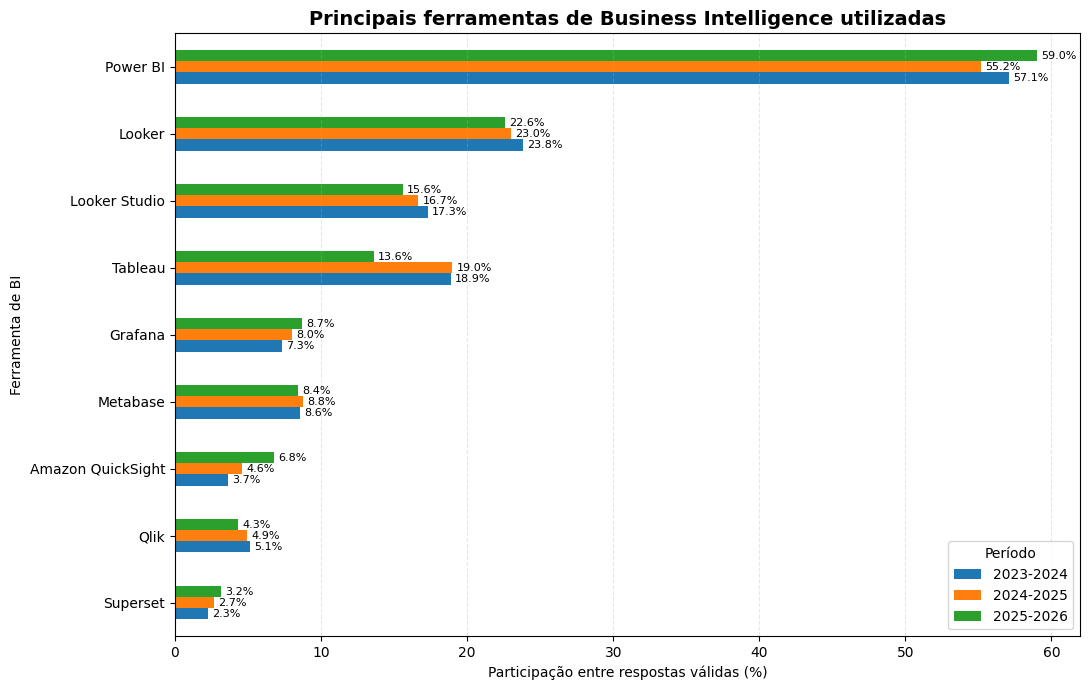

In [51]:
resultados_bi = []

for ferramenta, periodos in bi_comparaveis.items():

    for periodo, coluna in periodos.items():

        valores = df_gold.loc[
            df_gold["periodo"] == periodo,
            coluna
        ]

        valores_validos = valores[
            valores.isin([0, 1])
        ]

        percentual = (
            valores_validos.mean() * 100
            if len(valores_validos) > 0
            else None
        )

        resultados_bi.append({
            "ferramenta": ferramenta,
            "periodo": periodo,
            "respostas_validas": len(valores_validos),
            "percentual": percentual
        })

df_adocao_bi = pd.DataFrame(resultados_bi)

tabela_bi = (
    df_adocao_bi
    .pivot(
        index="ferramenta",
        columns="periodo",
        values="percentual"
    )
    .sort_values(
        "2025-2026",
        ascending=False
    )
)

display(tabela_bi.round(2))

# Gráfico
tabela_bi_grafico = tabela_bi.sort_values(
    "2025-2026",
    ascending=True
)

ax = tabela_bi_grafico.plot(
    kind="barh",
    figsize=(11, 7)
)

plt.title(
    "Principais ferramentas de Business Intelligence utilizadas",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Participação entre respostas válidas (%)")
plt.ylabel("Ferramenta de BI")
plt.legend(title="Período")
plt.grid(axis="x", linestyle="--", alpha=0.3)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=8
    )

plt.tight_layout()
plt.show()

### 6.5.4 Plataformas de Cloud

A adoção de plataformas de Cloud representa outra dimensão relevante para compreender o ecossistema tecnológico utilizado pelos profissionais de Dados.

Nesta análise, busca-se identificar a presença das principais plataformas de computação em nuvem entre os respondentes das três edições da pesquisa, considerando soluções como **Amazon Web Services (AWS), Microsoft Azure, Google Cloud Platform (GCP)** e outras plataformas disponíveis nos questionários.

Como nas análises tecnológicas anteriores, inicialmente são identificadas as variáveis equivalentes entre os três períodos. Posteriormente, a participação de cada plataforma será calculada considerando apenas as respostas válidas do respectivo bloco.

A comparação permite avaliar quais provedores apresentam maior presença entre os profissionais e identificar possíveis mudanças no cenário de adoção de Cloud ao longo dos períodos analisados.

In [52]:
blocos_cloud = {
    "2023-2024": "p4_h_",
    "2024-2025": "col_4_h_",
    "2025-2026": "4_e_"
}

for periodo, prefixo in blocos_cloud.items():

    print("\n" + "=" * 100)
    print(f"PLATAFORMAS DE CLOUD — {periodo}")
    print("=" * 100)

    colunas = [
        coluna for coluna in df_gold.columns
        if coluna.startswith(prefixo)
    ]

    print(
        f"Total de variáveis encontradas: "
        f"{len(colunas)}\n"
    )

    for coluna in colunas:

        preenchidos = int(
            df_gold[coluna].notna().sum()
        )

        if preenchidos > 0:

            print(
                f"{coluna} | "
                f"preenchidos: {preenchidos}"
            )


PLATAFORMAS DE CLOUD — 2023-2024
Total de variáveis encontradas: 8

p4_h_1_azure_microsoft | preenchidos: 3613
p4_h_2_amazon_web_services_aws | preenchidos: 3613
p4_h_3_google_cloud_gcp | preenchidos: 3613
p4_h_4_oracle_cloud | preenchidos: 3613
p4_h_5_ibm | preenchidos: 3613
p4_h_6_servidores_on_premise_nao_utilizamos_cloud | preenchidos: 3613
p4_h_7_cloud_propria | preenchidos: 3613
p4_h_dentre_as_opcoes_listadas_qual_sua_cloud_preferida | preenchidos: 3613

PLATAFORMAS DE CLOUD — 2024-2025
Total de variáveis encontradas: 8

col_4_h_1_amazon_web_services_aws | preenchidos: 3587
col_4_h_2_google_cloud_gcp | preenchidos: 3587
col_4_h_3_azure_microsoft | preenchidos: 3587
col_4_h_4_oracle_cloud | preenchidos: 3587
col_4_h_5_ibm | preenchidos: 3587
col_4_h_6_servidores_on_premise_nao_utilizamos_cloud | preenchidos: 3587
col_4_h_7_cloud_propria | preenchidos: 3587
col_4_h_cloud_dia_a_dia | preenchidos: 3587

PLATAFORMAS DE CLOUD — 2025-2026
Total de variáveis encontradas: 8

4_e_1_amazon

In [53]:
cloud_comparaveis = {
    "AWS": {
        "2023-2024": "p4_h_2_amazon_web_services_aws",
        "2024-2025": "col_4_h_1_amazon_web_services_aws",
        "2025-2026": "4_e_1_amazon_web_services_aws"
    },
    "Google Cloud (GCP)": {
        "2023-2024": "p4_h_3_google_cloud_gcp",
        "2024-2025": "col_4_h_2_google_cloud_gcp",
        "2025-2026": "4_e_2_google_cloud_gcp"
    },
    "Microsoft Azure": {
        "2023-2024": "p4_h_1_azure_microsoft",
        "2024-2025": "col_4_h_3_azure_microsoft",
        "2025-2026": "4_e_3_azure_microsoft"
    },
    "Oracle Cloud": {
        "2023-2024": "p4_h_4_oracle_cloud",
        "2024-2025": "col_4_h_4_oracle_cloud",
        "2025-2026": "4_e_4_oracle_cloud"
    },
    "IBM Cloud": {
        "2023-2024": "p4_h_5_ibm",
        "2024-2025": "col_4_h_5_ibm",
        "2025-2026": "4_e_5_ibm"
    }
}

for plataforma, periodos in cloud_comparaveis.items():

    print(f"\n{plataforma}")

    for periodo, coluna in periodos.items():

        valores = df_gold.loc[
            df_gold["periodo"] == periodo,
            coluna
        ]

        validos = valores[
            valores.isin([0, 1])
        ]

        print(
            f"{periodo}: "
            f"válidos={len(validos):,} | "
            f"1={int((validos == 1).sum()):,} | "
            f"0={int((validos == 0).sum()):,}"
        )


AWS
2023-2024: válidos=3,613 | 1=1,106 | 0=2,507
2024-2025: válidos=3,587 | 1=1,583 | 0=2,004
2025-2026: válidos=2,095 | 1=1,011 | 0=1,084

Google Cloud (GCP)
2023-2024: válidos=3,613 | 1=1,141 | 0=2,472
2024-2025: válidos=3,587 | 1=1,049 | 0=2,538
2025-2026: válidos=2,095 | 1=647 | 0=1,448

Microsoft Azure
2023-2024: válidos=3,613 | 1=1,529 | 0=2,084
2024-2025: válidos=3,587 | 1=1,108 | 0=2,479
2025-2026: válidos=2,095 | 1=730 | 0=1,365

Oracle Cloud
2023-2024: válidos=3,613 | 1=154 | 0=3,459
2024-2025: válidos=3,587 | 1=143 | 0=3,444
2025-2026: válidos=2,095 | 1=94 | 0=2,001

IBM Cloud
2023-2024: válidos=3,613 | 1=47 | 0=3,566
2024-2025: válidos=3,587 | 1=59 | 0=3,528
2025-2026: válidos=2,095 | 1=25 | 0=2,070


periodo,2023-2024,2024-2025,2025-2026
plataforma,,,
AWS,30.61,44.13,48.26
Microsoft Azure,42.32,30.89,34.84
Google Cloud (GCP),31.58,29.24,30.88
Oracle Cloud,4.26,3.99,4.49
IBM Cloud,1.30,1.64,1.19


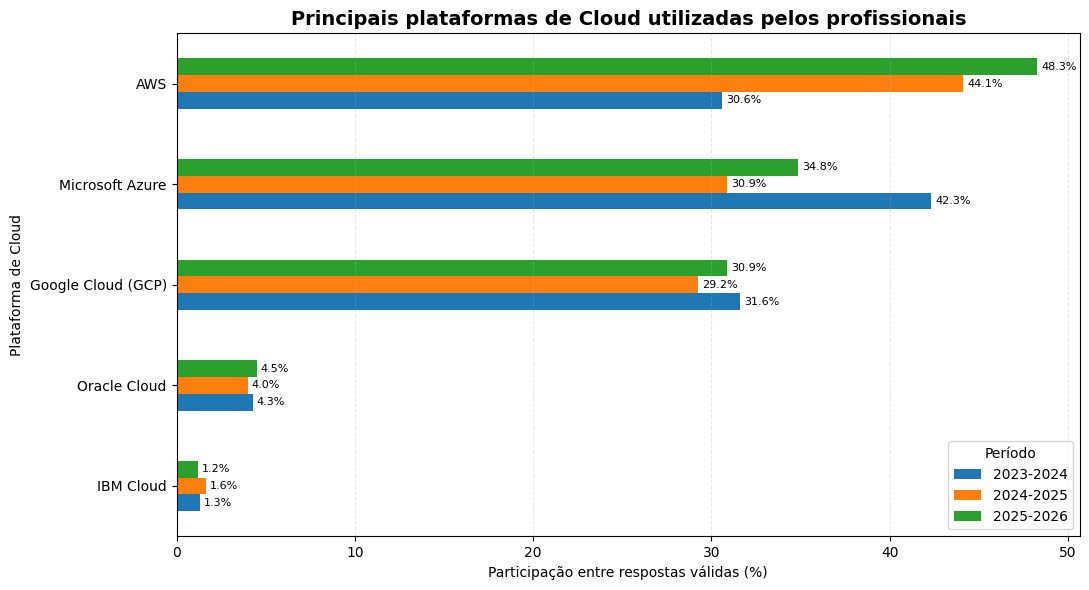

In [54]:
resultados_cloud = []

for plataforma, periodos in cloud_comparaveis.items():

    for periodo, coluna in periodos.items():

        valores = df_gold.loc[
            df_gold["periodo"] == periodo,
            coluna
        ]

        valores_validos = valores[
            valores.isin([0, 1])
        ]

        percentual = (
            valores_validos.mean() * 100
            if len(valores_validos) > 0
            else None
        )

        resultados_cloud.append({
            "plataforma": plataforma,
            "periodo": periodo,
            "respostas_validas": len(valores_validos),
            "percentual": percentual
        })

df_adocao_cloud = pd.DataFrame(resultados_cloud)

tabela_cloud = (
    df_adocao_cloud
    .pivot(
        index="plataforma",
        columns="periodo",
        values="percentual"
    )
    .sort_values(
        "2025-2026",
        ascending=False
    )
)

display(tabela_cloud.round(2))

# Gráfico
tabela_cloud_grafico = tabela_cloud.sort_values(
    "2025-2026",
    ascending=True
)

ax = tabela_cloud_grafico.plot(
    kind="barh",
    figsize=(11, 6)
)

plt.title(
    "Principais plataformas de Cloud utilizadas pelos profissionais",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Participação entre respostas válidas (%)")
plt.ylabel("Plataforma de Cloud")
plt.legend(title="Período")
plt.grid(axis="x", linestyle="--", alpha=0.3)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=8
    )

plt.tight_layout()
plt.show()

### Síntese da Questão 4 — Quais tecnologias apresentam maior adoção entre os profissionais?

A análise conjunta das diferentes dimensões tecnológicas evidencia um ecossistema de Dados concentrado em algumas tecnologias predominantes, embora existam diferenças relevantes entre linguagens, bancos de dados, ferramentas de Business Intelligence e plataformas de Cloud.

Em relação às **linguagens**, Python e SQL apresentam amplo destaque entre os profissionais. Python passa de 74,9% em 2023-2024 para 92,0% em 2025-2026, enquanto SQL permanece com participação elevada nas três edições, chegando a 84,2% no período mais recente. Devido a alterações na formulação da pergunta na edição 2025-2026, essa evolução deve ser interpretada com cautela, embora a relevância das duas tecnologias seja evidente.

Nos **bancos de dados**, PostgreSQL apresenta crescimento contínuo, passando de 28,3% para 36,8%, tornando-se a tecnologia com maior participação no período mais recente. SQL Server permanece relevante, com 33,5% em 2025-2026, seguido pelo MySQL, com 28,5%.

No segmento de **Business Intelligence**, observa-se forte predominância do Microsoft Power BI, presente em 59,0% das respostas válidas em 2025-2026. A ferramenta apresenta ampla vantagem em relação às demais soluções analisadas, enquanto Looker aparece no segundo patamar, com 22,6%.

Nas plataformas de **Cloud**, destaca-se a mudança de liderança ao longo do período analisado. O Microsoft Azure liderava em 2023-2024, com 42,3%, porém a AWS apresenta forte crescimento, passando de 30,6% para 48,3% e assumindo a liderança nas duas edições mais recentes. O Google Cloud mantém participação relativamente estável, próxima de 30%.

De forma consolidada, os resultados indicam que o ecossistema tecnológico dos profissionais de Dados analisados apresenta forte presença de **Python e SQL para programação e manipulação de dados, PostgreSQL e SQL Server no armazenamento, Power BI na camada analítica e de visualização e AWS, Azure e Google Cloud na infraestrutura em nuvem**.

Do ponto de vista empresarial, esse cenário sugere que organizações interessadas em estruturar ou expandir equipes de Dados podem priorizar competências nessas tecnologias, sem desconsiderar ferramentas alternativas relevantes para necessidades específicas de arquitetura, análise e negócio.

## 6.6 Adoção e impacto da Inteligência Artificial

A Inteligência Artificial vem assumindo papel crescente no ecossistema de Dados, tanto pela incorporação de novas ferramentas ao trabalho dos profissionais quanto pelas transformações provocadas nas atividades, competências e processos das organizações.

Nesta seção, busca-se avaliar o **nível de adoção de Inteligência Artificial entre os profissionais analisados e os impactos associados ao seu uso**, considerando as informações disponíveis nas três edições da pesquisa.

A análise será dividida em duas perspectivas complementares: inicialmente, serão investigados indicadores relacionados à **adoção e utilização de Inteligência Artificial** e, posteriormente, variáveis capazes de representar seus **impactos sobre o trabalho e as atividades profissionais**.

Como os questionários podem apresentar diferenças entre as edições, as variáveis serão previamente mapeadas e avaliadas quanto à sua comparabilidade antes da construção dos indicadores.

### 6.6.1 Adoção de Inteligência Artificial

Inicialmente, são investigadas as variáveis relacionadas ao uso e à adoção de Inteligência Artificial, buscando identificar indicadores comparáveis entre os períodos analisados.

In [55]:
termos_ia = [
    "inteligencia_artificial",
    "inteligência_artificial",
    "artificial_intelligence",
    "generative_ai",
    "genai",
    "chatgpt",
    "llm",
    "large_language",
    "machine_learning",
    "ia_generativa"
]

colunas_ia = []

for coluna in df_gold.columns:

    if any(
        termo in coluna.lower()
        for termo in termos_ia
    ):

        preenchidos = int(
            df_gold[coluna].notna().sum()
        )

        if preenchidos > 0:

            periodos = (
                df_gold.loc[
                    df_gold[coluna].notna(),
                    "periodo"
                ]
                .dropna()
                .astype(str)
                .unique()
            )

            colunas_ia.append({
                "coluna": coluna,
                "preenchidos": preenchidos,
                "periodos": ", ".join(
                    sorted(periodos)
                )
            })

resultado_ia = pd.DataFrame(colunas_ia)

if not resultado_ia.empty:

    resultado_ia = (
        resultado_ia
        .sort_values(
            ["periodos", "preenchidos"],
            ascending=[True, False]
        )
        .reset_index(drop=True)
    )

print(
    f"Total de variáveis encontradas: "
    f"{len(resultado_ia)}"
)

display(resultado_ia)

Total de variáveis encontradas: 84


,coluna,preenchidos,periodos
0,p4_l_4_ai_generativa_e_llms_para_melhorar_produtos_externos_para_os_clientes_finais,3772,2023-2024
1,p4_l_5_ai_generativa_e_llms_para_melhorar_produtos_internos_para_os_colaboradores,3772,2023-2024
2,p4_l_6_ia_generativa_e_llms_como_principal_frente_do_negocio,3772,2023-2024
3,p4_l_7_ia_generativa_e_llms_nao_e_prioridade,3772,2023-2024
4,p4_l_8_nao_sei_opinar_sobre_o_uso_de_ia_generativa_e_llms_na_empresa,3772,2023-2024
5,p4_l_qual_o_tipo_de_uso_de_ai_generativa_e_llms_na_empresa,3772,2023-2024
6,p4_m_utiliza_chatgpt_ou_llms_no_trabalho,3772,2023-2024
7,p3_c_7_sou_gestor_da_equipe_responsavel_por_iniciativas_e_projetos_envolvendo_inteligencia_artificial_e_machine_learning,874,2023-2024
8,p3_d_9_i_desenvolver_e_manter_modelos_machine_learning_em_producao,874,2023-2024
9,p3_f_4_ai_generativa_e_llms_para_melhorar_produtos_externos,862,2023-2024


In [56]:
variaveis_adocao_ia = {
    "2023-2024": "p4_m_utiliza_chatgpt_ou_llms_no_trabalho",
    "2024-2025": "col_4_m_usa_chatgpt_ou_copilot_no_trabalho",
    "2025-2026": "4_j_usa_chatgpt_ou_copilot_no_trabalho"
}

for periodo, coluna in variaveis_adocao_ia.items():

    valores = df_gold.loc[
        df_gold["periodo"] == periodo,
        coluna
    ].dropna()

    print("\n" + "=" * 80)
    print(periodo)
    print("=" * 80)

    print(f"Respostas válidas: {len(valores):,}")
    print("\nValores encontrados:")

    print(
        valores
        .value_counts(dropna=False)
        .to_string()
    )


2023-2024
Respostas válidas: 3,772

Valores encontrados:
p4_m_utiliza_chatgpt_ou_llms_no_trabalho
Utilizo apenas soluções gratuitas (como por exemplo o ChatGPT), para me ajudar a ser mais produtivo no dia a dia.                                                                                                                                                                         2219
Não utilizo nenhum tipo de solução de IA Generativa para melhorar a produtividade no dia a dia.                                                                                                                                                                                            718
Utilizo soluções no estilo "Copilot" (exemplo: Github Copilot, Amazon CodeWhisperer ou ChatGPT Plus) para ter mais produtividade no dia a dia.                                                                                                                                             187
Utilizo soluções pagas de AI Generativa 

In [57]:
resultados_adocao_ia = []

for periodo, coluna in variaveis_adocao_ia.items():

    valores = (
        df_gold.loc[
            df_gold["periodo"] == periodo,
            coluna
        ]
        .dropna()
        .astype(str)
    )

    # Identifica declaração de não utilização
    nao_utiliza = valores.str.contains(
        "Não utilizo nenhum tipo de solução de IA Generativa",
        case=False,
        na=False
    )

    # Identifica alguma declaração explícita de utilização
    utiliza = valores.str.contains(
        r"Utilizo apenas|Utilizo soluções",
        case=False,
        regex=True,
        na=False
    )

    # Se houver resposta contraditória contendo "não utilizo"
    # e também alguma forma explícita de uso, classificamos como adoção.
    adotou_ia = (~nao_utiliza) | utiliza

    total = len(valores)
    total_adotou = int(adotou_ia.sum())
    total_nao_adotou = total - total_adotou

    percentual_adocao = (
        total_adotou / total * 100
    )

    resultados_adocao_ia.append({
        "periodo": periodo,
        "respostas_validas": total,
        "adotou_ia": total_adotou,
        "nao_adotou_ia": total_nao_adotou,
        "percentual_adocao": percentual_adocao
    })

df_adocao_ia = pd.DataFrame(
    resultados_adocao_ia
)

display(
    df_adocao_ia.round(2)
)

,periodo,respostas_validas,adotou_ia,nao_adotou_ia,percentual_adocao
0,2023-2024,3772,3054,718,80.97
1,2024-2025,3617,3394,223,93.83
2,2025-2026,2105,2066,39,98.15


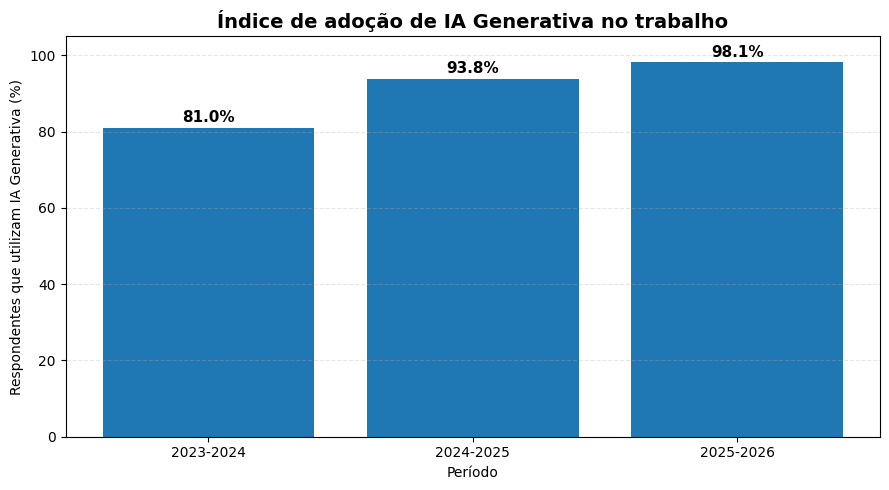

In [58]:
plt.figure(figsize=(9, 5))

barras = plt.bar(
    df_adocao_ia["periodo"],
    df_adocao_ia["percentual_adocao"]
)

plt.title(
    "Índice de adoção de IA Generativa no trabalho",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Período")
plt.ylabel("Respondentes que utilizam IA Generativa (%)")

plt.ylim(0, 105)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

for barra, valor in zip(
    barras,
    df_adocao_ia["percentual_adocao"]
):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        valor + 1.5,
        f"{valor:.1f}%",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

### 6.6.2 Impactos da Inteligência Artificial

Além do crescimento da adoção individual de ferramentas de Inteligência Artificial Generativa, é importante compreender de que forma essas tecnologias estão sendo incorporadas às organizações e quais impactos podem ser observados no ambiente empresarial.

Nesta etapa, são analisadas as formas de utilização de IA Generativa e LLMs nas empresas, considerando aplicações relacionadas a **produtos externos destinados aos clientes, produtos internos voltados aos colaboradores e utilização da IA como frente principal do negócio**.

Também são consideradas respostas que indicam que a IA Generativa ainda não representa uma prioridade, permitindo avaliar o grau de incorporação dessas tecnologias às estratégias e operações das organizações.

A análise utiliza apenas respostas válidas e variáveis conceitualmente equivalentes entre as edições da pesquisa.

In [59]:
impactos_ia = {
    "Produtos externos / clientes": {
        "2023-2024": "p4_l_4_ai_generativa_e_llms_para_melhorar_produtos_externos_para_os_clientes_finais",
        "2024-2025": "col_4_l_4_ai_generativa_e_llms_para_melhorar_produtos_externos_para_os_clientes_finais",
        "2025-2026": "4_i_4_ai_generativa_e_llms_para_melhorar_produtos_externos_para_os_clientes_finais"
    },

    "Produtos internos / colaboradores": {
        "2023-2024": "p4_l_5_ai_generativa_e_llms_para_melhorar_produtos_internos_para_os_colaboradores",
        "2024-2025": "col_4_l_5_ai_generativa_e_llms_para_melhorar_produtos_internos_para_os_colaboradores",
        "2025-2026": "4_i_5_ai_generativa_e_llms_para_melhorar_produtos_internos_para_os_colaboradores"
    },

    "IA como principal frente do negócio": {
        "2023-2024": "p4_l_6_ia_generativa_e_llms_como_principal_frente_do_negocio",
        "2024-2025": "col_4_l_6_ia_generativa_e_llms_como_principal_frente_do_negocio",
        "2025-2026": "4_i_6_ia_generativa_e_llms_como_principal_frente_do_negocio"
    },

    "IA não é prioridade": {
        "2023-2024": "p4_l_7_ia_generativa_e_llms_nao_e_prioridade",
        "2024-2025": "col_4_l_7_ia_generativa_e_llms_nao_e_prioridade",
        "2025-2026": "4_i_7_ia_generativa_e_llms_nao_e_prioridade"
    }
}

for indicador, periodos in impactos_ia.items():

    print(f"\n{indicador}")

    for periodo, coluna in periodos.items():

        valores = df_gold.loc[
            df_gold["periodo"] == periodo,
            coluna
        ]

        validos = valores[
            valores.isin([0, 1])
        ]

        print(
            f"{periodo}: "
            f"válidos={len(validos):,} | "
            f"1={int((validos == 1).sum()):,} | "
            f"0={int((validos == 0).sum()):,}"
        )


Produtos externos / clientes
2023-2024: válidos=3,772 | 1=799 | 0=2,973
2024-2025: válidos=3,617 | 1=1,016 | 0=2,601
2025-2026: válidos=2,105 | 1=635 | 0=1,470

Produtos internos / colaboradores
2023-2024: válidos=3,772 | 1=599 | 0=3,173
2024-2025: válidos=3,617 | 1=973 | 0=2,644
2025-2026: válidos=2,105 | 1=662 | 0=1,443

IA como principal frente do negócio
2023-2024: válidos=3,772 | 1=146 | 0=3,626
2024-2025: válidos=3,617 | 1=248 | 0=3,369
2025-2026: válidos=2,105 | 1=204 | 0=1,901

IA não é prioridade
2023-2024: válidos=3,772 | 1=785 | 0=2,987
2024-2025: válidos=3,617 | 1=412 | 0=3,205
2025-2026: válidos=2,105 | 1=139 | 0=1,966


periodo,2023-2024,2024-2025,2025-2026
indicador,,,
Produtos internos / colaboradores,15.88,26.90,31.45
Produtos externos / clientes,21.18,28.09,30.17
IA como principal frente do negócio,3.87,6.86,9.69
IA não é prioridade,20.81,11.39,6.60


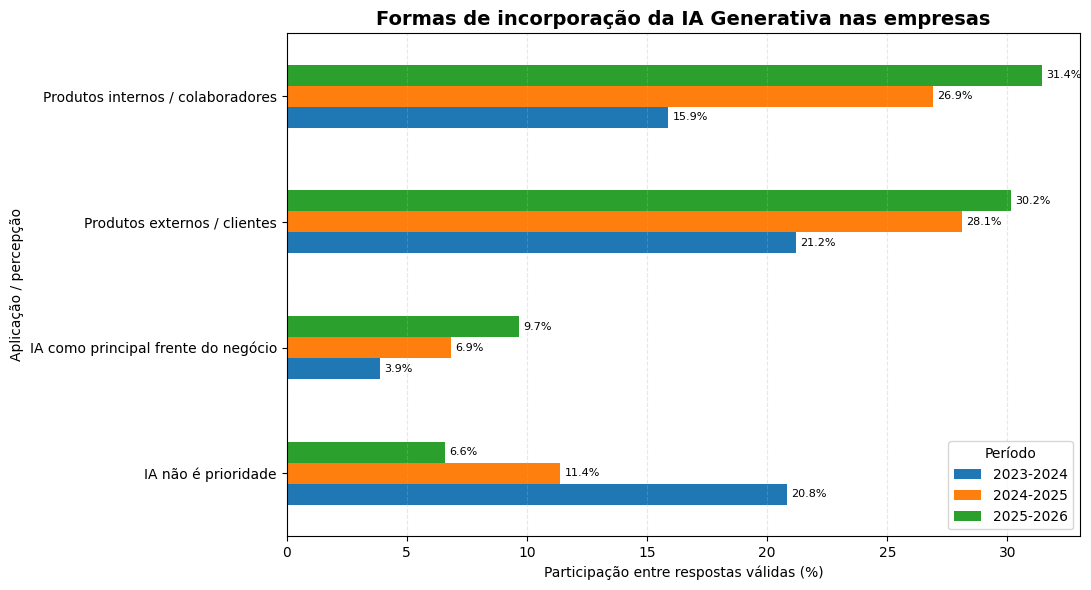

In [60]:
resultados_impacto_ia = []

for indicador, periodos in impactos_ia.items():

    for periodo, coluna in periodos.items():

        valores = df_gold.loc[
            df_gold["periodo"] == periodo,
            coluna
        ]

        valores_validos = valores[
            valores.isin([0, 1])
        ]

        percentual = (
            valores_validos.mean() * 100
            if len(valores_validos) > 0
            else None
        )

        resultados_impacto_ia.append({
            "indicador": indicador,
            "periodo": periodo,
            "respostas_validas": len(valores_validos),
            "percentual": percentual
        })

df_impacto_ia = pd.DataFrame(
    resultados_impacto_ia
)

tabela_impacto_ia = (
    df_impacto_ia
    .pivot(
        index="indicador",
        columns="periodo",
        values="percentual"
    )
    .sort_values(
        "2025-2026",
        ascending=False
    )
)

display(
    tabela_impacto_ia.round(2)
)

# Gráfico
tabela_impacto_grafico = (
    tabela_impacto_ia
    .sort_values(
        "2025-2026",
        ascending=True
    )
)

ax = tabela_impacto_grafico.plot(
    kind="barh",
    figsize=(11, 6)
)

plt.title(
    "Formas de incorporação da IA Generativa nas empresas",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "Participação entre respostas válidas (%)"
)

plt.ylabel("Aplicação / percepção")

plt.legend(title="Período")

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=8
    )

plt.tight_layout()
plt.show()

### 6.6.3 Desafios para adoção de Inteligência Artificial

Apesar do crescimento expressivo da adoção e da incorporação de Inteligência Artificial Generativa às atividades empresariais, sua utilização também pode enfrentar desafios relacionados à capacidade das organizações de transformar a tecnologia em resultados concretos.

Nesta etapa, são investigadas barreiras associadas à adoção de IA Generativa, com destaque para aspectos relacionados à **comprovação do retorno sobre o investimento (ROI)** e à **preparação dos dados organizacionais para utilização dessas tecnologias**.

A análise desses fatores complementa os indicadores anteriores, permitindo avaliar não apenas a expansão da IA, mas também alguns dos desafios enfrentados pelas organizações durante seu processo de implementação.

In [61]:
desafios_ia = {
    "ROI não comprovado": {
        "2023-2024": "p3_g_5_retorno_sobre_investimento_roi_nao_comprovado_de_ia_generativa",
        "2024-2025": "col_3_g_5_retorno_sobre_investimento_roi_nao_comprovado_de_ia_generativa",
        "2025-2026": "3_h_5_retorno_sobre_investimento_roi_nao_comprovado_de_ia_generativa"
    },

    "Dados não preparados para IA": {
        "2023-2024": "p3_g_6_dados_da_empresa_nao_estao_prontos_para_uso_de_ia_generativa",
        "2024-2025": "col_3_g_6_dados_da_empresa_nao_estao_prontos_para_uso_de_ia_generativa",
        "2025-2026": "3_h_6_dados_da_empresa_nao_estao_prontos_para_uso_de_ia_generativa"
    }
}

for desafio, periodos in desafios_ia.items():

    print(f"\n{desafio}")

    for periodo, coluna in periodos.items():

        valores = df_gold.loc[
            df_gold["periodo"] == periodo,
            coluna
        ]

        validos = valores[
            valores.isin([0, 1])
        ]

        print(
            f"{periodo}: "
            f"válidos={len(validos):,} | "
            f"1={int((validos == 1).sum()):,} | "
            f"0={int((validos == 0).sum()):,}"
        )


ROI não comprovado
2023-2024: válidos=823 | 1=126 | 0=697
2024-2025: válidos=974 | 1=249 | 0=725
2025-2026: válidos=587 | 1=167 | 0=420

Dados não preparados para IA
2023-2024: válidos=823 | 1=252 | 0=571
2024-2025: válidos=974 | 1=289 | 0=685
2025-2026: válidos=587 | 1=216 | 0=371


periodo,2023-2024,2024-2025,2025-2026
desafio,,,
Dados não preparados para IA,30.62,29.67,36.80
ROI não comprovado,15.31,25.56,28.45


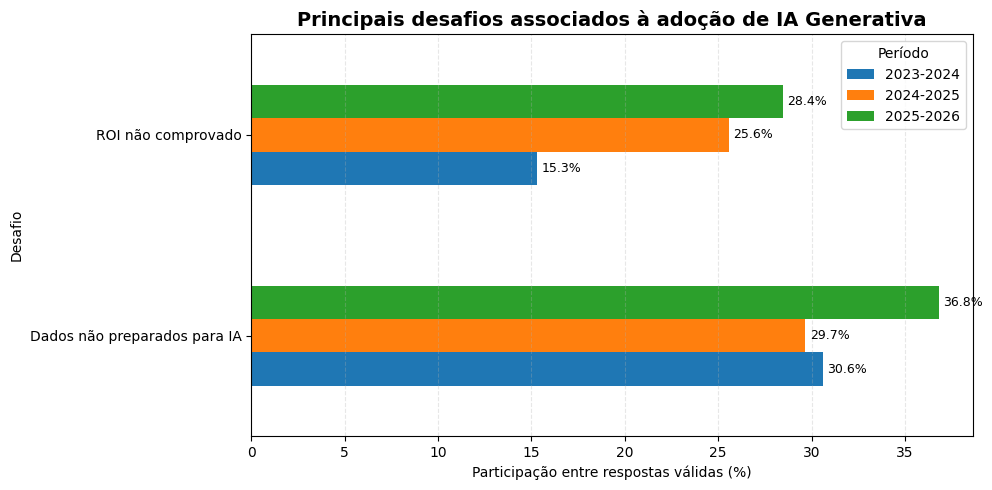

In [62]:
resultados_desafios_ia = []

for desafio, periodos in desafios_ia.items():

    for periodo, coluna in periodos.items():

        valores = df_gold.loc[
            df_gold["periodo"] == periodo,
            coluna
        ]

        valores_validos = valores[
            valores.isin([0, 1])
        ]

        percentual = (
            valores_validos.mean() * 100
            if len(valores_validos) > 0
            else None
        )

        resultados_desafios_ia.append({
            "desafio": desafio,
            "periodo": periodo,
            "respostas_validas": len(valores_validos),
            "percentual": percentual
        })

df_desafios_ia = pd.DataFrame(
    resultados_desafios_ia
)

tabela_desafios_ia = (
    df_desafios_ia
    .pivot(
        index="desafio",
        columns="periodo",
        values="percentual"
    )
)

display(
    tabela_desafios_ia.round(2)
)

# Gráfico
ax = tabela_desafios_ia.plot(
    kind="barh",
    figsize=(10, 5)
)

plt.title(
    "Principais desafios associados à adoção de IA Generativa",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "Participação entre respostas válidas (%)"
)

plt.ylabel("Desafio")

plt.legend(title="Período")

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=9
    )

plt.tight_layout()
plt.show()

### Síntese da Questão 5 — Qual é o índice de adoção de Inteligência Artificial e seu impacto?

Os resultados evidenciam uma **rápida expansão da adoção de Inteligência Artificial Generativa** entre os profissionais analisados. O percentual de respondentes que declarou utilizar alguma solução de IA Generativa no trabalho passa de **81,0% em 2023-2024 para 93,8% em 2024-2025**, alcançando **98,1% em 2025-2026**.

Esse avanço também é acompanhado por uma maior incorporação da tecnologia às organizações. A utilização de IA Generativa e LLMs em **produtos internos e soluções destinadas aos colaboradores** cresce de 15,9% para 31,4%, enquanto sua aplicação em **produtos externos destinados aos clientes** aumenta de 21,2% para 30,2%.

Também cresce a parcela que identifica a **IA como uma das principais frentes do negócio**, passando de 3,9% para 9,7%. Em sentido oposto, a proporção que afirma que **IA Generativa não representa uma prioridade** apresenta forte redução, de 20,8% em 2023-2024 para apenas 6,6% em 2025-2026.

Entretanto, a expansão da adoção não elimina desafios relacionados à implementação. Entre os respondentes do bloco específico sobre barreiras, **36,8% apontam em 2025-2026 que os dados da empresa ainda não estão preparados para utilização de IA Generativa**, enquanto **28,4% indicam que o retorno sobre o investimento (ROI) ainda não foi comprovado**.

Dessa forma, os dados sugerem que a Inteligência Artificial Generativa passou rapidamente de uma tecnologia emergente para uma ferramenta amplamente incorporada ao cotidiano dos profissionais de Dados e, progressivamente, às operações e produtos das organizações.

Ao mesmo tempo, o cenário evidencia uma diferença entre **adoção tecnológica e maturidade organizacional**: utilizar ferramentas de IA tornou-se comum, mas transformar essa utilização em iniciativas sustentáveis, apoiadas por dados preparados e retorno financeiro mensurável, permanece como um desafio relevante para as empresas.

Do ponto de vista estratégico, os resultados reforçam a importância de investimentos não apenas em ferramentas de Inteligência Artificial, mas também em **governança e qualidade de dados, infraestrutura, capacitação profissional e definição de métricas capazes de mensurar o retorno das iniciativas de IA**.

> **Nota metodológica:** os indicadores de adoção e aplicação consideram as respostas válidas dos respectivos blocos das pesquisas. Os indicadores relacionados às barreiras de implementação pertencem a um subconjunto específico de respondentes e, portanto, não representam a totalidade da amostra de cada edição.

## 6.7 Diferenças entre regiões, senioridades e modelos de trabalho

Além da análise geral do mercado brasileiro de Dados, é importante avaliar se determinadas características profissionais apresentam diferenças relevantes de acordo com o contexto dos respondentes.

Nesta seção, são investigadas possíveis diferenças relacionadas à **localização geográfica, nível de senioridade e modelo de trabalho**, buscando identificar padrões capazes de revelar desigualdades, concentrações ou características específicas do mercado.

A análise considera indicadores comparáveis entre os grupos e períodos disponíveis, priorizando diferenças com maior relevância para a compreensão da estrutura do mercado e para a tomada de decisão empresarial.

### 6.7.1 Diferenças regionais

A distribuição geográfica dos profissionais pode revelar diferenças importantes na estrutura do mercado brasileiro de Dados, especialmente em relação à concentração de oportunidades, características profissionais e remuneração.

Nesta etapa, são investigadas as informações geográficas disponíveis nas três edições da pesquisa, buscando identificar variáveis comparáveis que permitam analisar possíveis diferenças entre regiões do país.

Inicialmente, é realizado o mapeamento das variáveis relacionadas à localização dos respondentes. Posteriormente, essas informações serão utilizadas em conjunto com indicadores profissionais relevantes, priorizando comparações que apresentem consistência metodológica entre os períodos analisados.

In [63]:
termos_regiao = [
    "regiao",
    "região",
    "estado",
    "uf",
    "localizacao",
    "localização",
    "reside",
    "residencia",
    "mora"
]

colunas_regiao = []

for coluna in df_gold.columns:

    if any(
        termo in coluna.lower()
        for termo in termos_regiao
    ):

        preenchidos = int(
            df_gold[coluna].notna().sum()
        )

        if preenchidos > 0:

            periodos = (
                df_gold.loc[
                    df_gold[coluna].notna(),
                    "periodo"
                ]
                .dropna()
                .astype(str)
                .unique()
            )

            colunas_regiao.append({
                "coluna": coluna,
                "preenchidos": preenchidos,
                "periodos": ", ".join(
                    sorted(periodos)
                )
            })

resultado_regiao = pd.DataFrame(
    colunas_regiao
)

if not resultado_regiao.empty:

    resultado_regiao = (
        resultado_regiao
        .sort_values(
            ["periodos", "preenchidos"],
            ascending=[True, False]
        )
        .reset_index(drop=True)
    )

print(
    f"Total de variáveis encontradas: "
    f"{len(resultado_regiao)}"
)

display(resultado_regiao)

Total de variáveis encontradas: 21


,coluna,preenchidos,periodos
0,p1_i_estado_onde_mora,5172,2023-2024
1,p1_j_mudou_de_estado,5172,2023-2024
2,p1_i_1_uf_onde_mora,5169,2023-2024
3,p1_i_2_regiao_onde_mora,5169,2023-2024
4,p1_k_regiao_de_origem,1064,2023-2024
5,col_1_i_estado_onde_mora,5076,2024-2025
6,col_1_j_vive_no_estado_de_formacao,5076,2024-2025
7,col_1_i_1_uf_onde_mora,5073,2024-2025
8,col_1_i_2_regiao_onde_mora,5073,2024-2025
9,col_1_k_estado_de_origem,977,2024-2025


In [64]:
variaveis_regiao = {
    "2023-2024": "p1_i_2_regiao_onde_mora",
    "2024-2025": "col_1_i_2_regiao_onde_mora",
    "2025-2026": "1_i_2_regiao_onde_mora"
}

for periodo, coluna in variaveis_regiao.items():

    valores = (
        df_gold.loc[
            df_gold["periodo"] == periodo,
            coluna
        ]
        .dropna()
        .astype(str)
    )

    print("\n" + "=" * 80)
    print(f"REGIÕES — {periodo}")
    print("=" * 80)

    print(f"Respostas válidas: {len(valores):,}\n")

    print(
        valores
        .value_counts()
        .to_string()
    )


REGIÕES — 2023-2024
Respostas válidas: 5,169

p1_i_2_regiao_onde_mora
Sudeste         3173
Sul              961
Nordeste         608
Centro-oeste     344
Norte             83

REGIÕES — 2024-2025
Respostas válidas: 5,073

col_1_i_2_regiao_onde_mora
Sudeste         3131
Sul             1030
Nordeste         516
Centro-oeste     332
Norte             64

REGIÕES — 2025-2026
Respostas válidas: 3,369

1_i_2_regiao_onde_mora
Sudeste         2170
Sul              540
Nordeste         380
Centro-oeste     231
Norte             48


#### Diferenças de remuneração entre regiões

Para avaliar se existem diferenças economicamente relevantes entre as regiões brasileiras, a distribuição geográfica dos respondentes é analisada em conjunto com o indicador de remuneração utilizado anteriormente.

Como referência, considera-se a proporção de profissionais com **remuneração mensal acima de R$ 12 mil** em cada região, permitindo comparar a presença relativa de profissionais nas faixas salariais mais elevadas.

A utilização de proporções, em vez de valores absolutos, reduz o efeito das diferenças no número de respondentes entre as regiões e entre as edições da pesquisa.

In [65]:
objetos_salario = [
    nome for nome in globals().keys()
    if any(
        termo in nome.lower()
        for termo in [
            "salario",
            "remuneracao",
            "remuneração"
        ]
    )
]

print("Objetos relacionados a salário/remuneração:\n")

for nome in sorted(objetos_salario):
    print(nome)

Objetos relacionados a salário/remuneração:

bases_cargo_salario
bases_salario
candidatas_remuneracao
col_salario
config_cargo_salario
df_cargo_salario
df_remuneracao
df_salario_senioridade
pivot_salarios_altos
resumo_cargo_salario
resumo_cargo_salario_filtrado
salarios_altos
tabela_salario_senioridade
termos_remuneracao
variaveis_salario


In [66]:
print("Shape:", df_remuneracao.shape)

print("\nColunas:")
print(df_remuneracao.columns.tolist())

print("\nAmostra:")
display(df_remuneracao.head())

Shape: (9, 3)

Colunas:
['coluna', 'preenchidos', 'periodos_com_dados']

Amostra:


,coluna,preenchidos,periodos_com_dados
3,col_2_h_faixa_salarial,4861,2024-2025
5,col_2_o_1_remuneracao_salario,4861,2024-2025
6,p2_h_faixa_salarial,4753,2023-2024
8,p2_o_1_remuneracao_salario,4727,2023-2024
0,2_h_faixa_salarial,3227,2025-2026


In [67]:
print("Tipo de bases_salario:")
print(type(bases_salario))

print("\nConteúdo:")
print(bases_salario)

Tipo de bases_salario:
<class 'list'>

Conteúdo:
[      senioridade                    faixa_original         faixa_salarial  \
0           Pleno    de R$ 6.001/mês a R$ 8.000/mês    R$ 4 mil a R$ 8 mil   
1          Júnior    de R$ 1.001/mês a R$ 2.000/mês           Até R$ 4 mil   
2          Sênior  de R$ 12.001/mês a R$ 16.000/mês  R$ 12 mil a R$ 20 mil   
3          Sênior   de R$ 8.001/mês a R$ 12.000/mês   R$ 8 mil a R$ 12 mil   
4           Pleno    de R$ 6.001/mês a R$ 8.000/mês    R$ 4 mil a R$ 8 mil   
...           ...                               ...                    ...   
11906        None  de R$ 12.001/mês a R$ 16.000/mês  R$ 12 mil a R$ 20 mil   
11907      Sênior   de R$ 8.001/mês a R$ 12.000/mês   R$ 8 mil a R$ 12 mil   
11908        None  de R$ 16.001/mês a R$ 20.000/mês  R$ 12 mil a R$ 20 mil   
11909       Pleno    de R$ 6.001/mês a R$ 8.000/mês    R$ 4 mil a R$ 8 mil   
11910       Pleno   de R$ 8.001/mês a R$ 12.000/mês   R$ 8 mil a R$ 12 mil   

         peri

In [68]:
print("\nTipo de salarios_altos:")
print(type(salarios_altos))

print("\nConteúdo/amostra:")

if hasattr(salarios_altos, "head"):
    display(salarios_altos.head())
else:
    print(salarios_altos)


Tipo de salarios_altos:
<class 'pandas.core.frame.DataFrame'>

Conteúdo/amostra:


,periodo,senioridade,percentual
0,2023-2024,Júnior,0.765550
1,2023-2024,Pleno,8.548851
2,2023-2024,Sênior,49.612403
3,2024-2025,Júnior,1.382488
4,2024-2025,Pleno,9.302326


In [71]:
# Mapeamento das colunas de região
variaveis_regiao = {
    "2023-2024": "p1_i_2_regiao_onde_mora",
    "2024-2025": "col_1_i_2_regiao_onde_mora",
    "2025-2026": "1_i_2_regiao_onde_mora"
}

bases_regiao_salario = []

for base in bases_salario:

    temp = base.copy()

    # Identifica o período da base
    periodo = temp["periodo"].dropna().iloc[0]

    # Coluna regional correspondente ao período
    coluna_regiao = variaveis_regiao[periodo]

    # Recupera a região utilizando o índice original da Gold
    temp["regiao"] = df_gold.loc[
        temp.index,
        coluna_regiao
    ]

    # Mesmo critério utilizado anteriormente:
    # remuneração acima de R$ 12 mil
    temp["acima_12k"] = temp["faixa_salarial"].isin([
        "R$ 12 mil a R$ 20 mil",
        "Acima de R$ 20 mil"
    ])

    # Apenas salário e região válidos
    temp = temp[
        temp["faixa_salarial"].notna()
        & temp["regiao"].notna()
    ]

    bases_regiao_salario.append(temp)

# Consolidação
df_regiao_salario = pd.concat(
    bases_regiao_salario,
    ignore_index=True
)

# Resumo por período e região
resumo_regiao_salario = (
    df_regiao_salario
    .groupby(["periodo", "regiao"])
    .agg(
        profissionais=("acima_12k", "size"),
        acima_12k=("acima_12k", "sum")
    )
    .reset_index()
)

# Percentual
resumo_regiao_salario["percentual_acima_12k"] = (
    resumo_regiao_salario["acima_12k"]
    / resumo_regiao_salario["profissionais"]
    * 100
)

display(
    resumo_regiao_salario
    .sort_values(
        ["periodo", "percentual_acima_12k"],
        ascending=[True, False]
    )
    .round(2)
)

,periodo,regiao,profissionais,acima_12k,percentual_acima_12k
3,2023-2024,Sudeste,2889,965,33.40
0,2023-2024,Centro-oeste,304,95,31.25
4,2023-2024,Sul,886,225,25.40
1,2023-2024,Nordeste,501,100,19.96
2,2023-2024,Norte,69,8,11.59
8,2024-2025,Sudeste,2939,1210,41.17
5,2024-2025,Centro-oeste,300,94,31.33
9,2024-2025,Sul,988,303,30.67
6,2024-2025,Nordeste,447,123,27.52
7,2024-2025,Norte,57,13,22.81


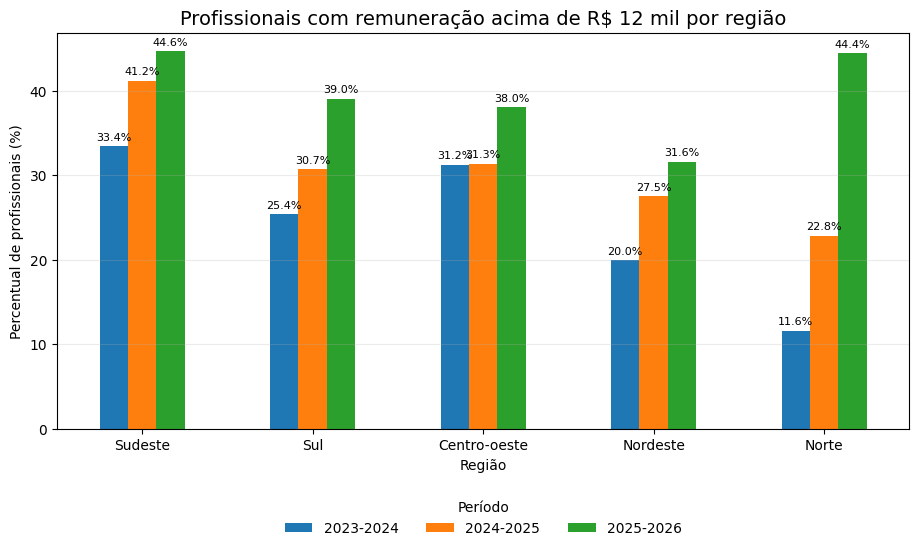

In [73]:
import matplotlib.pyplot as plt

ordem_regioes = [
    "Sudeste",
    "Sul",
    "Centro-oeste",
    "Nordeste",
    "Norte"
]

grafico_regiao = (
    resumo_regiao_salario
    .pivot(
        index="regiao",
        columns="periodo",
        values="percentual_acima_12k"
    )
    .reindex(ordem_regioes)
)

ax = grafico_regiao.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title(
    "Profissionais com remuneração acima de R$ 12 mil por região",
    fontsize=14
)

plt.xlabel("Região")
plt.ylabel("Percentual de profissionais (%)")

plt.xticks(rotation=0)

# Legenda abaixo do gráfico
plt.legend(
    title="Período",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=3,
    frameon=False
)

plt.grid(
    axis="y",
    alpha=0.25
)

# Rótulos dos valores
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=8
    )

# Espaço extra para a legenda inferior
plt.subplots_adjust(bottom=0.22)

plt.show()

#### Interpretação

A análise evidencia diferenças regionais na proporção de profissionais com remuneração mensal acima de R$ 12 mil.

O **Sudeste** apresenta percentuais elevados e crescimento ao longo das três edições, passando de **33,4% em 2023-2024 para 44,6% em 2025-2026**. O **Sul** também apresenta avanço relevante, de **25,4% para 39,0%**, enquanto o **Centro-Oeste** passa de **31,3% para 38,0%**.

O **Nordeste**, embora permaneça abaixo das regiões anteriores, também apresenta crescimento consistente, passando de **20,0% para 31,6%** dos profissionais com remuneração acima de R$ 12 mil.

No **Norte**, observa-se forte aumento percentual no último período. Entretanto, esse resultado deve ser interpretado com cautela devido ao menor número de respostas válidas da região, especialmente em 2025-2026, quando a análise salarial considera apenas **36 profissionais**.

De maneira geral, os resultados indicam a existência de **diferenças regionais de remuneração**, mas também mostram crescimento da participação de profissionais nas faixas salariais mais elevadas em todas as regiões analisadas.

### 6.7.2 Diferenças por senioridade

Além das diferenças regionais, o nível de senioridade pode influenciar a forma como novas tecnologias são incorporadas à rotina dos profissionais de Dados.

Como a relação entre senioridade e remuneração já foi analisada anteriormente, esta etapa utiliza uma dimensão complementar: a **adoção de Inteligência Artificial Generativa no trabalho**.

O objetivo é verificar se a utilização dessas tecnologias apresenta diferenças relevantes entre profissionais Júnior, Pleno, Sênior e, quando disponível, Especialista/Staff+, permitindo avaliar se a expansão da IA ocorre de maneira semelhante entre os diferentes níveis profissionais.

In [74]:
objetos_senioridade = [
    nome for nome in globals().keys()
    if "senioridade" in nome.lower()
]

print("Objetos relacionados à senioridade:\n")

for nome in sorted(objetos_senioridade):
    print(nome)

Objetos relacionados à senioridade:

df_salario_senioridade
df_senioridade
ordem_senioridade
senioridade_2023
senioridade_2024
senioridade_2025
tabela_salario_senioridade


In [76]:
for nome in [
    "senioridade_2023",
    "senioridade_2024",
    "senioridade_2025"
]:
    obj = globals()[nome]

    print("\n" + "=" * 70)
    print(nome)
    print("=" * 70)

    print("Tipo:", type(obj))

    if hasattr(obj, "shape"):
        print("Shape:", obj.shape)

    if hasattr(obj, "columns"):
        print("Colunas:", obj.columns.tolist())
        display(obj.head())

    else:
        print(obj.head() if hasattr(obj, "head") else obj)


senioridade_2023
Tipo: <class 'pandas.core.series.Series'>
Shape: (3,)
p2_g_nivel
Sênior    36.790251
Pleno     36.090226
Júnior    27.119523
Name: proportion, dtype: float64

senioridade_2024
Tipo: <class 'pandas.core.series.Series'>
Shape: (3,)
col_2_g_nivel
Sênior    41.194969
Pleno     36.058700
Júnior    22.746331
Name: proportion, dtype: float64

senioridade_2025
Tipo: <class 'pandas.core.series.Series'>
Shape: (4,)
2_g_nivel
Sênior                 34.32
Pleno                  31.00
Júnior                 20.72
Especialista/Staff+    13.96
Name: proportion, dtype: float64


In [77]:
config_senioridade_ia = {
    "2023-2024": {
        "senioridade": "p2_g_nivel",
        "ia": "p4_m_utiliza_chatgpt_ou_llms_no_trabalho"
    },
    "2024-2025": {
        "senioridade": "col_2_g_nivel",
        "ia": "col_4_m_usa_chatgpt_ou_copilot_no_trabalho"
    },
    "2025-2026": {
        "senioridade": "2_g_nivel",
        "ia": "4_j_usa_chatgpt_ou_copilot_no_trabalho"
    }
}

for periodo, config in config_senioridade_ia.items():

    temp = df_gold.loc[
        df_gold["periodo"] == periodo,
        [config["senioridade"], config["ia"]]
    ].copy()

    temp = temp.dropna(subset=[config["senioridade"], config["ia"]])

    print("\n" + "=" * 80)
    print(f"{periodo}")
    print("=" * 80)

    print("Registros com senioridade + IA válidos:", len(temp))

    print("\nSenioridade:")
    print(
        temp[config["senioridade"]]
        .value_counts()
        .to_string()
    )

    print("\nExemplos de respostas sobre IA:")
    print(
        temp[config["ia"]]
        .value_counts()
        .head(10)
        .to_string()
    )


2023-2024
Registros com senioridade + IA válidos: 3772

Senioridade:
p2_g_nivel
Sênior    1393
Pleno     1359
Júnior    1020

Exemplos de respostas sobre IA:
p4_m_utiliza_chatgpt_ou_llms_no_trabalho
Utilizo apenas soluções gratuitas (como por exemplo o ChatGPT), para me ajudar a ser mais produtivo no dia a dia.                                                                                                                                                                         2219
Não utilizo nenhum tipo de solução de IA Generativa para melhorar a produtividade no dia a dia.                                                                                                                                                                                            718
Utilizo soluções no estilo "Copilot" (exemplo: Github Copilot, Amazon CodeWhisperer ou ChatGPT Plus) para ter mais produtividade no dia a dia.                                                                                    

In [78]:
resultados_senioridade_ia = []

for periodo, config in config_senioridade_ia.items():

    temp = df_gold.loc[
        df_gold["periodo"] == periodo,
        [config["senioridade"], config["ia"]]
    ].copy()

    temp = temp.dropna(
        subset=[config["senioridade"], config["ia"]]
    )

    temp.columns = ["senioridade", "resposta_ia"]

    # Identifica explicitamente a resposta de não utilização
    temp["nao_utiliza_ia"] = (
        temp["resposta_ia"]
        .astype(str)
        .str.strip()
        .str.lower()
        .str.startswith(
            "não utilizo nenhum tipo de solução de ia generativa"
        )
    )

    # Se não declarou exclusivamente "não utilizo",
    # considera-se adoção de IA
    temp["adota_ia"] = ~temp["nao_utiliza_ia"]

    resumo = (
        temp
        .groupby("senioridade")
        .agg(
            profissionais=("adota_ia", "size"),
            adotam_ia=("adota_ia", "sum")
        )
        .reset_index()
    )

    resumo["percentual_adocao_ia"] = (
        resumo["adotam_ia"]
        / resumo["profissionais"]
        * 100
    )

    resumo["periodo"] = periodo

    resultados_senioridade_ia.append(resumo)

resumo_senioridade_ia = pd.concat(
    resultados_senioridade_ia,
    ignore_index=True
)

display(
    resumo_senioridade_ia[
        [
            "periodo",
            "senioridade",
            "profissionais",
            "adotam_ia",
            "percentual_adocao_ia"
        ]
    ]
    .sort_values(
        ["periodo", "percentual_adocao_ia"],
        ascending=[True, False]
    )
    .round(2)
)

,periodo,senioridade,profissionais,adotam_ia,percentual_adocao_ia
1,2023-2024,Pleno,1359,1109,81.60
0,2023-2024,Júnior,1020,819,80.29
2,2023-2024,Sênior,1393,1108,79.54
3,2024-2025,Júnior,775,730,94.19
5,2024-2025,Sênior,1523,1425,93.57
4,2024-2025,Pleno,1319,1229,93.18
6,2025-2026,Especialista/Staff+,306,301,98.37
9,2025-2026,Sênior,744,731,98.25
8,2025-2026,Pleno,665,652,98.05
7,2025-2026,Júnior,390,379,97.18


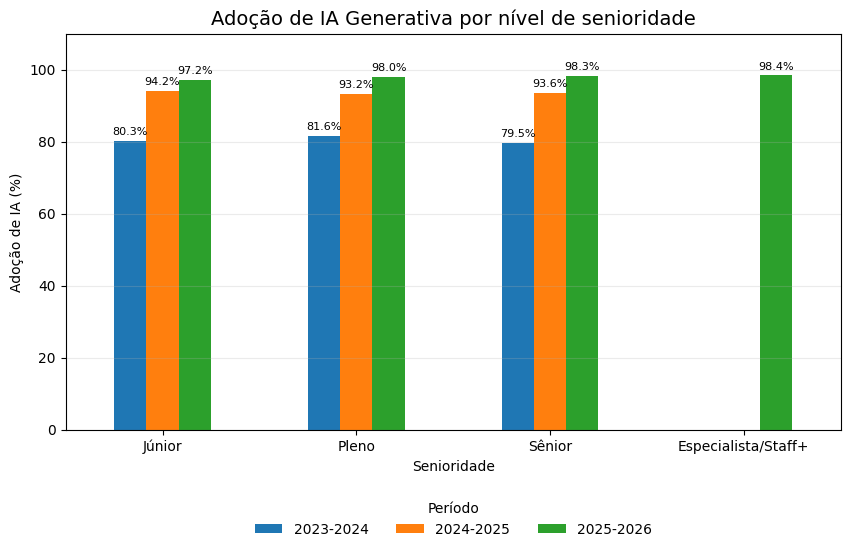

In [80]:
import matplotlib.pyplot as plt

# Ordem das senioridades no gráfico
ordem_senioridade = [
    "Júnior",
    "Pleno",
    "Sênior",
    "Especialista/Staff+"
]

# Organização dos dados para visualização
grafico_senioridade_ia = (
    resumo_senioridade_ia
    .pivot(
        index="senioridade",
        columns="periodo",
        values="percentual_adocao_ia"
    )
    .reindex(ordem_senioridade)
)

# Criação do gráfico
ax = grafico_senioridade_ia.plot(
    kind="bar",
    figsize=(10, 6)
)

# Título e eixos
plt.title(
    "Adoção de IA Generativa por nível de senioridade",
    fontsize=14
)

plt.xlabel("Senioridade")
plt.ylabel("Adoção de IA (%)")

plt.xticks(rotation=0)

# Legenda abaixo do gráfico
plt.legend(
    title="Período",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=3,
    frameon=False
)

# Grade horizontal
plt.grid(
    axis="y",
    alpha=0.25
)

# Rótulos percentuais
# Valores inexistentes/zero não recebem rótulo
for container in ax.containers:

    labels = []

    for bar in container:

        valor = bar.get_height()

        if valor > 0:
            labels.append(f"{valor:.1f}%")
        else:
            labels.append("")

    ax.bar_label(
        container,
        labels=labels,
        padding=3,
        fontsize=8
    )

# Espaço vertical para os rótulos
plt.ylim(0, 110)

# Espaço inferior para a legenda
plt.subplots_adjust(bottom=0.22)

plt.show()

#### Interpretação

A adoção de Inteligência Artificial Generativa apresenta níveis elevados entre todas as senioridades analisadas, com redução das diferenças entre os grupos ao longo das três edições da pesquisa.

Em 2023-2024, os percentuais variavam entre **79,5% para profissionais Sênior, 80,3% para Júnior e 81,6% para Pleno**, indicando que a utilização de IA já apresentava elevada disseminação independentemente do nível profissional.

Em 2024-2025, a adoção supera **93% em todas as senioridades**, enquanto em 2025-2026 os percentuais se aproximam da universalização: **97,2% entre Júnior, 98,0% entre Pleno, 98,3% entre Sênior e 98,4% entre Especialista/Staff+**.

Os resultados indicam que, embora existam pequenas diferenças entre os níveis de senioridade, a **adoção de IA Generativa não se encontra concentrada nos profissionais mais experientes**. Pelo contrário, a tecnologia apresenta ampla utilização ao longo dos diferentes estágios da carreira.

Esse cenário sugere que competências relacionadas à utilização de Inteligência Artificial estão se tornando cada vez mais transversais no mercado de Dados, deixando de representar uma característica restrita a determinados níveis profissionais.

### 6.7.3 Diferenças por modelo de trabalho

O modelo de trabalho também representa uma dimensão relevante para compreender as características do mercado de Dados, especialmente após a expansão das modalidades remota e híbrida.

Nesta etapa, são investigadas as modalidades de trabalho declaradas pelos profissionais nas diferentes edições da pesquisa, buscando identificar mudanças na distribuição entre trabalho presencial, híbrido e remoto e possíveis diferenças relevantes entre esses modelos.

Inicialmente, são identificadas e validadas as variáveis equivalentes relacionadas ao modelo de trabalho nas três pesquisas, garantindo a comparabilidade entre os períodos analisados.

In [81]:
termos_modelo_trabalho = [
    "modelo_trabalho",
    "modelo_de_trabalho",
    "modalidade",
    "remoto",
    "presencial",
    "hibrido",
    "híbrido",
    "home_office",
    "trabalho_remoto"
]

colunas_modelo_trabalho = []

for coluna in df_gold.columns:

    if any(
        termo in coluna.lower()
        for termo in termos_modelo_trabalho
    ):

        preenchidos = int(
            df_gold[coluna].notna().sum()
        )

        if preenchidos > 0:

            periodos = (
                df_gold.loc[
                    df_gold[coluna].notna(),
                    "periodo"
                ]
                .dropna()
                .astype(str)
                .unique()
            )

            colunas_modelo_trabalho.append({
                "coluna": coluna,
                "preenchidos": preenchidos,
                "periodos": ", ".join(sorted(periodos))
            })

resultado_modelo_trabalho = pd.DataFrame(
    colunas_modelo_trabalho
)

if not resultado_modelo_trabalho.empty:

    resultado_modelo_trabalho = (
        resultado_modelo_trabalho
        .sort_values(
            ["periodos", "preenchidos"],
            ascending=[True, False]
        )
        .reset_index(drop=True)
    )

print(
    f"Total de variáveis encontradas: "
    f"{len(resultado_modelo_trabalho)}"
)

display(resultado_modelo_trabalho)

Total de variáveis encontradas: 15


,coluna,preenchidos,periodos
0,p2_t_caso_sua_empresa_decida_pelo_modelo_100_presencial_qual_sera_sua_atitude,4753,2023-2024
1,p2_o_4_flexibilidade_de_trabalho_remoto,4727,2023-2024
2,p3_d_4_d_gestao_de_equipes_no_ambiente_remoto,874,2023-2024
3,col_2_o_4_flexibilidade_de_trabalho_remoto,4861,2024-2025
4,col_2_r_modelo_de_trabalho_atual,4861,2024-2025
5,col_2_s_modelo_de_trabalho_ideal,4861,2024-2025
6,col_2_t_atitude_em_caso_de_retorno_presencial,4861,2024-2025
7,col_2_l_4_flexibilidade_de_trabalho_remoto,1527,2024-2025
8,col_3_d_4_gestao_de_equipes_no_ambiente_remoto,1045,2024-2025
9,2_o_4_flexibilidade_de_trabalho_remoto,3227,2025-2026


In [83]:
# Localiza automaticamente as variáveis de modelo de trabalho atual

colunas_modelo_atual = [
    coluna for coluna in df_gold.columns
    if "modelo_de_trabalho_atual" in coluna.lower()
]

print("Variáveis encontradas:\n")

for coluna in colunas_modelo_atual:

    periodos = (
        df_gold.loc[
            df_gold[coluna].notna(),
            "periodo"
        ]
        .dropna()
        .unique()
    )

    print(
        f"{coluna} | "
        f"preenchidos: {df_gold[coluna].notna().sum()} | "
        f"períodos: {periodos}"
    )

Variáveis encontradas:

2_q_modelo_de_trabalho_atual | preenchidos: 3227 | períodos: ['2025-2026']
col_2_r_modelo_de_trabalho_atual | preenchidos: 4861 | períodos: ['2024-2025']


In [84]:
variaveis_modelo_atual = {
    "2024-2025": "col_2_r_modelo_de_trabalho_atual",
    "2025-2026": "2_q_modelo_de_trabalho_atual"
}

for periodo, coluna in variaveis_modelo_atual.items():

    valores = (
        df_gold.loc[
            df_gold["periodo"] == periodo,
            coluna
        ]
        .dropna()
        .astype(str)
    )

    print("\n" + "=" * 80)
    print(f"MODELO DE TRABALHO — {periodo}")
    print("=" * 80)

    print(f"Respostas válidas: {len(valores):,}\n")

    print(
        valores
        .value_counts()
        .to_string()
    )


MODELO DE TRABALHO — 2024-2025
Respostas válidas: 4,861

col_2_r_modelo_de_trabalho_atual
Modelo 100% remoto                                                                                                2221
Modelo híbrido flexível (o funcionário tem liberdade para escolher quando estar no escritório presencialmente)     998
Modelo híbrido com dias fixos de trabalho presencial                                                               850
Modelo 100% presencial                                                                                             792

MODELO DE TRABALHO — 2025-2026
Respostas válidas: 3,227

2_q_modelo_de_trabalho_atual
Modelo 100% remoto                                                                                                1281
Modelo 100% presencial                                                                                             670
Modelo híbrido com dias fixos de trabalho presencial                                                        

In [85]:
resultados_modelo_trabalho = []

variaveis_modelo_atual = {
    "2024-2025": "col_2_r_modelo_de_trabalho_atual",
    "2025-2026": "2_q_modelo_de_trabalho_atual"
}

# Nomes simplificados para visualização
mapa_modelos = {
    "Modelo 100% remoto": "100% Remoto",
    "Modelo 100% presencial": "100% Presencial",
    "Modelo híbrido com dias fixos de trabalho presencial": "Híbrido - dias fixos",
    "Modelo híbrido flexível (o funcionário tem liberdade para escolher quando estar no escritório presencialmente)": "Híbrido - flexível"
}

for periodo, coluna in variaveis_modelo_atual.items():

    temp = (
        df_gold.loc[
            df_gold["periodo"] == periodo,
            coluna
        ]
        .dropna()
        .astype(str)
        .map(mapa_modelos)
    )

    resumo = (
        temp
        .value_counts()
        .rename_axis("modelo_trabalho")
        .reset_index(name="profissionais")
    )

    resumo["percentual"] = (
        resumo["profissionais"]
        / resumo["profissionais"].sum()
        * 100
    )

    resumo["periodo"] = periodo

    resultados_modelo_trabalho.append(resumo)

resumo_modelo_trabalho = pd.concat(
    resultados_modelo_trabalho,
    ignore_index=True
)

display(
    resumo_modelo_trabalho[
        [
            "periodo",
            "modelo_trabalho",
            "profissionais",
            "percentual"
        ]
    ]
    .sort_values(
        ["periodo", "percentual"],
        ascending=[True, False]
    )
    .round(2)
)

,periodo,modelo_trabalho,profissionais,percentual
0,2024-2025,100% Remoto,2221,45.69
1,2024-2025,Híbrido - flexível,998,20.53
2,2024-2025,Híbrido - dias fixos,850,17.49
3,2024-2025,100% Presencial,792,16.29
4,2025-2026,100% Remoto,1281,39.70
5,2025-2026,100% Presencial,670,20.76
6,2025-2026,Híbrido - dias fixos,645,19.99
7,2025-2026,Híbrido - flexível,631,19.55


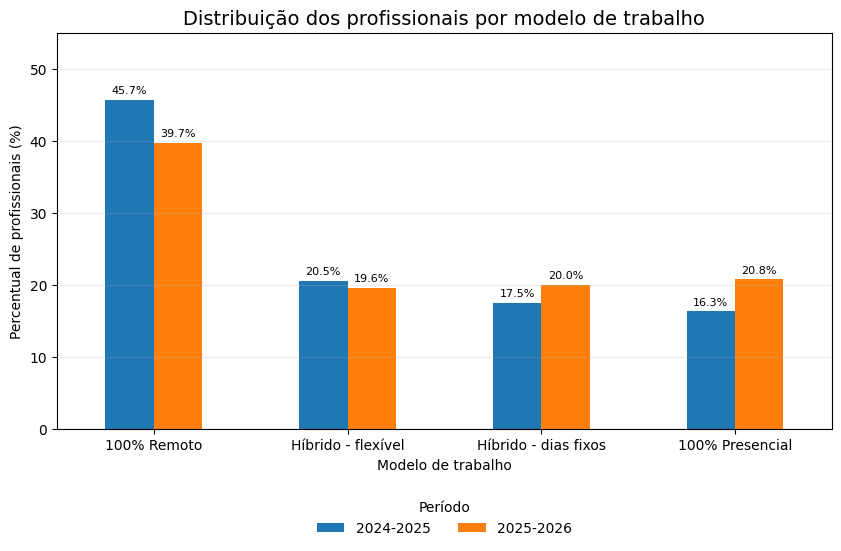

In [86]:
import matplotlib.pyplot as plt

ordem_modelos = [
    "100% Remoto",
    "Híbrido - flexível",
    "Híbrido - dias fixos",
    "100% Presencial"
]

grafico_modelo_trabalho = (
    resumo_modelo_trabalho
    .pivot(
        index="modelo_trabalho",
        columns="periodo",
        values="percentual"
    )
    .reindex(ordem_modelos)
)

ax = grafico_modelo_trabalho.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Distribuição dos profissionais por modelo de trabalho",
    fontsize=14
)

plt.xlabel("Modelo de trabalho")
plt.ylabel("Percentual de profissionais (%)")

plt.xticks(rotation=0)

# Legenda abaixo
plt.legend(
    title="Período",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
    frameon=False
)

plt.grid(
    axis="y",
    alpha=0.25
)

# Rótulos percentuais
for container in ax.containers:

    labels = []

    for bar in container:

        valor = bar.get_height()

        if valor > 0:
            labels.append(f"{valor:.1f}%")
        else:
            labels.append("")

    ax.bar_label(
        container,
        labels=labels,
        padding=3,
        fontsize=8
    )

plt.ylim(0, 55)

plt.subplots_adjust(bottom=0.22)

plt.show()

### Síntese da Questão 6 — Existem diferenças relevantes entre regiões, senioridades ou modelos de trabalho?

As análises realizadas indicam que **existem diferenças relevantes no mercado brasileiro de Dados**, embora sua intensidade varie de acordo com a dimensão analisada.

**Diferenças regionais:** a proporção de profissionais com remuneração acima de R$ 12 mil apresenta diferenças entre as regiões. O Sudeste passou de **33,4% em 2023-2024 para 44,6% em 2025-2026**, enquanto o Sul avançou de **25,4% para 39,0%**, o Centro-Oeste de **31,3% para 38,0%** e o Nordeste de **20,0% para 31,6%**. O Norte também apresenta crescimento, porém seus resultados devem ser interpretados com cautela devido ao menor número de respostas válidas, especialmente no período mais recente.

**Diferenças por senioridade:** ao contrário da remuneração, que apresenta forte diferenciação entre níveis profissionais conforme observado anteriormente, a adoção de IA Generativa mostra diferenças cada vez menores entre as senioridades. Em 2025-2026, a utilização alcança **97,2% entre Júnior, 98,0% entre Pleno, 98,3% entre Sênior e 98,4% entre Especialista/Staff+**, indicando que a IA se tornou uma tecnologia transversal aos diferentes níveis de carreira.

**Diferenças por modelo de trabalho:** entre 2024-2025 e 2025-2026, o modelo 100% remoto permanece como a modalidade individual mais frequente, mas sua participação diminui de **45,7% para 39,7%**. Paralelamente, o trabalho 100% presencial cresce de **16,3% para 20,8%**, enquanto as modalidades híbridas, consideradas conjuntamente, representam aproximadamente **39,5% dos respondentes em 2025-2026**.

De maneira geral, os resultados mostram um mercado caracterizado por **diferenças regionais de remuneração, forte influência da senioridade sobre a valorização profissional e ampla disseminação da Inteligência Artificial entre todos os níveis de experiência**. Ao mesmo tempo, observa-se uma reorganização dos modelos de trabalho, com redução relativa do trabalho totalmente remoto e maior participação de modalidades híbridas e presenciais.

Do ponto de vista empresarial, esses resultados reforçam a importância de considerar **localização, senioridade, políticas de trabalho e competências em Inteligência Artificial** de forma integrada nas estratégias de atração, desenvolvimento e retenção de profissionais de Dados.

**Nota metodológica:** as análises utilizam proporções calculadas sobre respostas válidas em cada indicador. Para modelo de trabalho, foram consideradas apenas as edições 2024-2025 e 2025-2026, devido à ausência de uma variável diretamente equivalente na edição 2023-2024. Os resultados representam os respondentes das pesquisas e não devem ser interpretados como estimativas causais ou como representação integral de todo o mercado brasileiro.

## 6.8 Oportunidades e desafios para empresas que desejam investir em Dados e Inteligência Artificial

As análises realizadas ao longo das diferentes edições da pesquisa permitem identificar não apenas características do mercado brasileiro de Dados, mas também oportunidades e desafios relevantes para organizações que desejam ampliar seus investimentos em Dados e Inteligência Artificial.

Nesta etapa, os principais resultados obtidos anteriormente são consolidados sob uma perspectiva empresarial, transformando os indicadores analisados em implicações estratégicas relacionadas a talentos, tecnologias, Inteligência Artificial, infraestrutura e modelos de trabalho.

### 6.8.1 Oportunidades identificadas

Os resultados apontam diferentes oportunidades para organizações que desejam ampliar sua maturidade analítica e acelerar iniciativas baseadas em Dados e Inteligência Artificial.

**Expansão acelerada da Inteligência Artificial**

A adoção de IA Generativa entre os profissionais analisados passou de aproximadamente **81,0% em 2023-2024 para 98,1% em 2025-2026**, indicando forte disseminação dessas tecnologias no ambiente profissional.

Além disso, a utilização empresarial da IA apresenta crescimento tanto em produtos internos quanto em soluções direcionadas aos clientes. Esse cenário cria oportunidades para aplicação da tecnologia em **automação, produtividade, desenvolvimento de produtos, suporte à decisão e melhoria de processos internos**.

**Disponibilidade de um ecossistema tecnológico consolidado**

Tecnologias como **Python, SQL, Power BI, PostgreSQL e plataformas de Cloud** apresentam elevada presença entre os profissionais analisados. A consolidação desse ecossistema reduz barreiras para empresas que desejam estruturar ou expandir suas capacidades analíticas.

A evolução da utilização de plataformas como AWS também evidencia a crescente importância da infraestrutura em nuvem para projetos modernos de Dados e Inteligência Artificial.

**IA como competência transversal**

Em 2025-2026, a adoção de IA supera **97% em todas as senioridades analisadas**, indicando que essas ferramentas não estão restritas aos profissionais mais experientes.

Esse cenário cria oportunidade para programas corporativos de capacitação em IA que alcancem diferentes níveis profissionais, incorporando a tecnologia de maneira transversal às equipes.

**Ampliação das possibilidades de atração de talentos**

Apesar da redução relativa do trabalho totalmente remoto entre 2024-2025 e 2025-2026, os modelos remoto e híbrido continuam representando parcela expressiva dos profissionais analisados.

Políticas flexíveis de trabalho podem, portanto, ampliar as possibilidades de contratação e retenção de profissionais especializados em Dados.

### 6.8.2 Principais desafios

Apesar das oportunidades identificadas, os resultados também evidenciam desafios importantes para organizações que pretendem ampliar seus investimentos em Dados e Inteligência Artificial.

**Preparação e qualidade dos dados**

Entre os respondentes do grupo analisado sobre barreiras à IA, **36,8% em 2025-2026 indicaram que os dados da empresa ainda não estavam preparados para utilização de IA Generativa**.

Esse resultado evidencia que a adoção de ferramentas de IA precisa ser acompanhada por investimentos em **qualidade, integração, governança, arquitetura e disponibilidade dos dados**.

**Comprovação de retorno sobre investimento**

No mesmo grupo, **28,4% apontaram o retorno sobre investimento (ROI) ainda não comprovado** como desafio relacionado à IA Generativa.

Empresas que desejam ampliar esses investimentos precisam estabelecer casos de uso claros, métricas de produtividade, indicadores financeiros e mecanismos capazes de acompanhar os resultados gerados pelas iniciativas de IA.

**Competição por profissionais especializados**

Os resultados de remuneração mostram maior valorização de profissionais com senioridade elevada e especialização técnica, principalmente em áreas como **Machine Learning/IA, Engenharia de Dados, Analytics Engineering e Ciência de Dados**.

Esse cenário pode elevar a competição por talentos e exige estratégias de desenvolvimento interno, capacitação e retenção de profissionais.

**Diferenças regionais e políticas de trabalho**

As diferenças observadas na remuneração entre regiões e as mudanças nos modelos de trabalho indicam que estratégias de contratação não devem considerar apenas competências técnicas.

Localização, flexibilidade, modalidade de trabalho e características do mercado regional também podem influenciar a capacidade das organizações de atrair e reter profissionais.

### 6.8.3 Recomendações estratégicas

A partir dos resultados obtidos, empresas que desejam ampliar seus investimentos em Dados e Inteligência Artificial podem priorizar cinco frentes estratégicas:

1. **Fortalecer a fundação de dados**, investindo em qualidade, integração, governança e arquiteturas escaláveis antes de ampliar aplicações avançadas de IA.

2. **Priorizar casos de uso de IA com impacto mensurável**, estabelecendo indicadores de produtividade, eficiência, receita ou redução de custos capazes de demonstrar retorno sobre investimento.

3. **Desenvolver competências internas**, combinando capacitação em Inteligência Artificial com tecnologias amplamente utilizadas pelo mercado, como Python, SQL, ferramentas de BI e plataformas de Cloud.

4. **Estruturar estratégias de atração e retenção para perfis especializados**, considerando a maior valorização observada em profissionais experientes e em funções técnicas relacionadas a IA, Engenharia e Ciência de Dados.

5. **Adotar políticas de trabalho compatíveis com o mercado de Dados**, avaliando modelos presenciais, híbridos e remotos de acordo com as necessidades organizacionais e com a capacidade de atração de talentos.

Em síntese, os resultados indicam que a principal oportunidade para as empresas está na **ampla disseminação das tecnologias de Dados e Inteligência Artificial entre os profissionais**, enquanto o principal desafio consiste em transformar essa adoção tecnológica em **capacidade organizacional estruturada, governada e capaz de gerar resultados mensuráveis para o negócio**.

## 6.9 Conclusão da Análise e DataViz

A análise integrada das três edições da pesquisa permitiu construir uma visão ampla sobre a evolução do mercado brasileiro de Dados, considerando aspectos relacionados à estrutura profissional, valorização dos perfis, diversidade, tecnologias, Inteligência Artificial, localização e modelos de trabalho.

Os resultados evidenciam um mercado em processo de **amadurecimento e especialização**. A senioridade permanece como um importante fator de diferenciação profissional e salarial, enquanto funções com maior especialização técnica — especialmente relacionadas a **Machine Learning e Inteligência Artificial, Engenharia de Dados, Analytics Engineering e Ciência de Dados** — apresentam maior presença nas faixas superiores de remuneração.

Do ponto de vista tecnológico, observa-se a consolidação de um ecossistema formado por ferramentas amplamente utilizadas no mercado, com destaque para **Python e SQL**, além da forte presença de **Power BI**, bancos de dados relacionais e plataformas de Cloud. Esse cenário reforça a importância da integração entre competências analíticas, engenharia, visualização e infraestrutura para a construção de ambientes modernos de Dados.

A **Inteligência Artificial Generativa** representa uma das transformações mais relevantes identificadas no período analisado. Sua adoção entre os profissionais cresceu de aproximadamente **81% para 98%**, tornando-se praticamente transversal entre os diferentes níveis de senioridade. Paralelamente, cresce sua incorporação em produtos e processos empresariais. Entretanto, desafios relacionados à **preparação dos dados e comprovação de retorno sobre investimento** demonstram que elevada adoção tecnológica não significa, necessariamente, elevada maturidade organizacional.

As análises também revelam desafios estruturais importantes. A participação feminina permanece significativamente inferior à masculina entre os respondentes e os indicadores relacionados à experiência profissional mostram diferenças relevantes associadas ao gênero. Também foram observadas diferenças regionais de remuneração e mudanças na organização do trabalho, com redução relativa do modelo totalmente remoto e maior participação de modalidades presenciais e híbridas nos períodos comparáveis.

Em conjunto, os resultados indicam que o mercado brasileiro de Dados apresenta **forte adoção tecnológica, crescente incorporação da Inteligência Artificial e valorização de competências especializadas**, mas ainda enfrenta desafios relacionados a diversidade, desenvolvimento de talentos, governança de dados e transformação dos investimentos tecnológicos em resultados mensuráveis para o negócio.

Sob a perspectiva empresarial, investir em Dados e Inteligência Artificial exige mais do que a adoção de novas ferramentas. Os resultados deste estudo reforçam a necessidade de combinar **tecnologia, pessoas, qualidade dos dados, governança e estratégia de negócio**, criando uma estrutura capaz de transformar dados em decisões e Inteligência Artificial em geração efetiva de valor.